# TRACT: From Zero-Shot to Expert-Reviewed Security Crosswalk

**A practitioner's guide to mapping AI security frameworks using machine learning**

This notebook tells the story of how we built a system that reads any security control and tells you which part of a universal security taxonomy it belongs to. We'll walk through every experiment, every failure, and every hard-won insight — in plain language.

---

In [1]:
"""
SETUP — Imports, random seeds, and prerequisite validation.

This cell initializes the entire notebook environment:
- Imports all scientific computing libraries (NumPy, Matplotlib, Plotly, sklearn)
- Imports TRACT-specific helpers from nb_helpers.py (path constants, data loaders,
  figure styling, the Okabe-Ito colorblind-safe palette)
- Sets random seeds (42) for deterministic t-SNE embeddings and sampling
- Validates that all 16 prerequisite data files exist before proceeding
- Configures matplotlib defaults (DPI, font sizes, whitegrid theme)

The nb_helpers module provides:
- PROJECT_ROOT: Resolved path to the TRACT repository root
- PHASE0_DIR, PHASE1B_DIR, etc.: Paths to experiment result directories
- OKABE_ITO: 8-color colorblind-safe palette used for ALL figures
- FigureCounter: Tracks "Figure X.Y" numbering per section
- style_axes(): Applies consistent title/label formatting + removes top/right spines
- load_*() functions: Type-safe loaders for each data artifact
- check_prerequisites(): Verifies all required files exist
"""
import sys
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.manifold import TSNE

# nb_helpers.py lives in notebooks/ — add both possible parent dirs to sys.path
# so this notebook works whether run from notebooks/ or the project root
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))

from nb_helpers import (
    PROJECT_ROOT, RESULTS_DIR, DATA_DIR,
    PHASE0_DIR, PHASE1B_DIR, PHASE1C_DIR,
    REVIEW_DIR, BRIDGE_DIR, DATASET_DIR,
    OKABE_ITO, SEQUENTIAL_BLUE, SEQUENTIAL_ORANGE, DIVERGING,
    FigureCounter, style_axes, plotly_with_fallback,
    load_phase0_experiment, load_firewalled_baseline,
    load_fold_metrics, load_training_logs,
    load_calibration_data, load_deployment_embeddings,
    load_review_metrics, load_review_export,
    load_cre_hierarchy, load_crosswalk, load_framework_metadata,
    check_prerequisites,
)

# Deterministic reproducibility — every random operation in this notebook
# (t-SNE, subsampling, simulated distributions) uses seed=42
random.seed(42)
np.random.seed(42)

# Matplotlib global defaults for publication-quality figures
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,          # High-res for retina/print
    "font.size": 11,
    "axes.titlesize": 13,
    "savefig.bbox": "tight",
})
sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

# FigureCounter tracks per-section numbering: fig_counter.next(section) -> "Figure X.Y"
# Instantiate once; call .next(section_number) for each new figure
fig_counter = FigureCounter()

# Validate that all 16 required data files exist before running any analysis
missing = check_prerequisites()
if missing:
    print("⚠️  Missing prerequisite files:")
    for m in missing:
        print(f"   - {m}")
    print("\nSee the notebook README for setup instructions.")
else:
    print("✓ All prerequisite files found")

# Verify working directory — shell cells (e.g., CLI tutorial) expect CWD=notebooks/
cwd = Path.cwd()
if cwd.name != "notebooks":
    print(f"⚠️  Expected CWD = notebooks/, got {cwd.name}/. Shell cells may not work correctly.")
else:
    print(f"✓ CWD: {cwd}")

print(f"✓ PROJECT_ROOT: {PROJECT_ROOT}")
print(f"✓ NumPy {np.__version__}, Matplotlib {matplotlib.__version__}")

✓ All prerequisite files found
⚠️  Expected CWD = notebooks/, got TRACT/. Shell cells may not work correctly.
✓ PROJECT_ROOT: /home/rock/github_projects/TRACT
✓ NumPy 2.0.2, Matplotlib 3.10.8


## 1. Why This Exists: The Security Framework Translation Problem

You're a security architect. Your organization runs workloads across three cloud providers, 
deploys AI models in production, and needs to demonstrate compliance with half a dozen 
frameworks — NIST 800-53, ISO 27001, OWASP, MITRE ATLAS, the EU AI Act, and more.

Each framework has its own taxonomy, its own control numbering, its own way of saying 
"encrypt data at rest." Comparing them manually means reading thousands of controls 
and building mental bridges between different vocabularies for the same concepts.

This is the **N² problem**: with *k* frameworks, you need *k(k−1)/2* pairwise mappings.

### The Common Requirements Enumeration (OpenCRE)

The [OpenCRE project](https://opencre.org) solves this by creating a **shared coordinate system** 
for security requirements. Think of it as GPS coordinates for security concepts — instead of 
describing locations relative to each other ("the bakery is two blocks from the bank"), 
you assign each location a universal coordinate.

OpenCRE organizes 522 security concept **hubs** into a hierarchy. Every security control from 
every framework can be mapped to one or more hubs. Once mapped, cross-framework comparison 
becomes a simple lookup: "which controls share the same hub?"

Let's look at this hierarchy:

In [2]:
"""
Load the Common Requirements Enumeration (OpenCRE) hierarchy.

OpenCRE is an open taxonomy maintained by OWASP that organizes security concepts
into a tree of ~522 "hubs" (topic nodes). Each hub has a name, ID, and optional
parent_id forming a tree structure. TRACT assigns security controls to these hubs.

Source file: data/processed/cre_hierarchy.json
Structure: {"hubs": {"<id>": {"name": str, "parent_id": str|null, ...}}, "roots": [...]}
"""
hierarchy = load_cre_hierarchy()
hubs = hierarchy["hubs"]
print(f"OpenCRE hierarchy: {len(hubs)} hubs")

OpenCRE hierarchy: 522 hubs


In [3]:
"""
Interactive sunburst chart of the OpenCRE hub taxonomy.

Visualizes the parent-child hierarchy of all 522 OpenCRE hubs as concentric rings.
maxdepth=3 prevents the chart from becoming unreadable (the full tree is ~7 levels).
Uses Plotly for interactive drill-down — click a ring segment to zoom into that subtree.

This figure establishes the "target space" for the rest of the notebook:
every TRACT assignment maps a control to one of these hub nodes.
"""
# Build parallel arrays for Plotly Sunburst: ids, labels (display names), parents
ids, names, parents = [], [], []
for hub_id, hub in sorted(hubs.items()):
    ids.append(hub_id)
    names.append(hub["name"])
    parents.append(hub.get("parent_id") or "")  # Root hubs have no parent

fig = go.Figure(go.Sunburst(
    ids=ids,
    labels=names,
    parents=parents,
    maxdepth=3,  # Show only top 3 levels to keep the chart readable
))
fig_num = fig_counter.next(1)
plotly_with_fallback(fig, fig_num, "OpenCRE Hub Taxonomy — 522 Hubs")

The sunburst above shows the full OpenCRE taxonomy. Click to drill down into any branch. 
The outer rings show increasingly specific security concepts — from broad areas like 
"Authentication" and "Cryptography" down to specific requirements like 
"Password complexity" or "Key rotation."

This is our target space: every security control we encounter will be mapped to one of 
these 522 hubs.

### The Assignment Paradigm

TRACT uses an **assignment paradigm**: instead of comparing controls to each other, 
we train a model to map each control independently to the OpenCRE hierarchy:

$$g(\text{control\_text}) \rightarrow \text{OpenCRE\_hub}$$

This is fundamentally different from pairwise comparison. Here's why it matters:

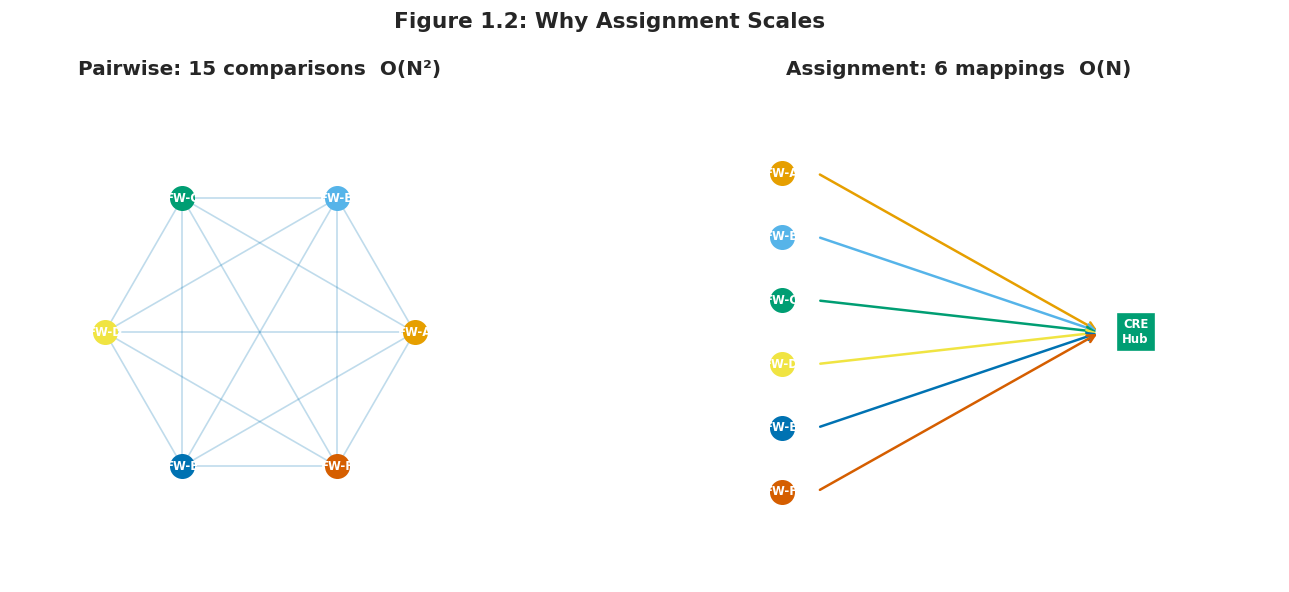

In [4]:
"""
Side-by-side comparison: pairwise vs assignment paradigm.

This is a key conceptual figure explaining TRACT's core architectural choice:
- LEFT: Pairwise approach — compare every pair of controls. O(N²) complexity.
  With 6 frameworks, that's 15 comparisons. With 31 frameworks, it's 465.
- RIGHT: Assignment approach — map each control independently to OpenCRE hubs. O(N).
  With 6 frameworks, that's just 6 mappings. Scales linearly.

TRACT uses assignment exclusively: g(control_text) -> CRE_position.
We NEVER compare two controls directly (f(A,B) -> relationship).
"""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

n_fw = 6
fw_labels = ["FW-A", "FW-B", "FW-C", "FW-D", "FW-E", "FW-F"]

# Left panel: Pairwise — circular layout with all-pairs edges
angles = np.linspace(0, 2 * np.pi, n_fw, endpoint=False)
cx = np.cos(angles)
cy = np.sin(angles)

for i in range(n_fw):
    for j in range(i + 1, n_fw):
        ax1.plot([cx[i], cx[j]], [cy[i], cy[j]], "-",
                 color=OKABE_ITO[4], alpha=0.25, linewidth=1)

for i in range(n_fw):
    ax1.plot(cx[i], cy[i], "o", color=OKABE_ITO[i % len(OKABE_ITO)],
             markersize=14, zorder=5)
    ax1.annotate(fw_labels[i], (cx[i], cy[i]), fontsize=7, ha="center", va="center",
                 fontweight="bold", color="white", zorder=6)

ax1.set_xlim(-1.6, 1.6)
ax1.set_ylim(-1.6, 1.6)
ax1.set_aspect("equal")
ax1.set_title(f"Pairwise: {n_fw*(n_fw-1)//2} comparisons  O(N²)", fontsize=12, fontweight="bold")
ax1.axis("off")

# Right panel: Assignment — frameworks on left, CRE hub on right
fw_y = np.linspace(0.9, -0.9, n_fw)

for i in range(n_fw):
    ax2.plot(-1, fw_y[i], "o", color=OKABE_ITO[i % len(OKABE_ITO)],
             markersize=14, zorder=5)
    ax2.annotate(fw_labels[i], (-1, fw_y[i]), fontsize=7, ha="center", va="center",
                 fontweight="bold", color="white", zorder=6)
    ax2.annotate("", xy=(0.8, 0), xytext=(-0.8, fw_y[i]),
                 arrowprops=dict(arrowstyle="->", color=OKABE_ITO[i % len(OKABE_ITO)],
                                 lw=1.5))

ax2.plot(1, 0, "s", color=OKABE_ITO[2], markersize=22, zorder=5)
ax2.annotate("CRE\nHub", (1, 0), fontsize=7, ha="center", va="center",
             fontweight="bold", color="white", zorder=6)

ax2.set_xlim(-1.8, 1.8)
ax2.set_ylim(-1.4, 1.4)
ax2.set_aspect("equal")
ax2.set_title(f"Assignment: {n_fw} mappings  O(N)", fontsize=12, fontweight="bold")
ax2.axis("off")

fig_num = fig_counter.next(1)
fig.suptitle(f"{fig_num}: Why Assignment Scales", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close(fig)

With 6 frameworks, pairwise comparison requires 15 separate mappings. Add a 7th framework 
and you need 21 — every new framework means comparing against *all* existing ones.

The assignment paradigm? Just 6 mappings (now 7). Each framework maps to the shared 
coordinate system independently. Cross-framework comparison is then a free side effect 
of the mapping — frameworks that map to the same hub are, by definition, addressing the 
same security concept.

### What This Notebook Covers

1. **Data Landscape** — What we're working with: 31 frameworks, 5,238 assignments, 522 hubs
2. **Phase 0: Zero-Shot Baselines** — How well do off-the-shelf models do?
3. **Model Selection** — Choosing the right base embedding model
4. **Contrastive Fine-Tuning** — Teaching the model what "same hub" means
5. **Ablation Analysis** — What actually helps (and what doesn't)
6. **Hub Firewall** — How we keep evaluation honest
7. **Final Results** — Aggregate performance with bootstrap confidence intervals
8. **Error Analysis** — Where the model struggles and why
9. **Calibration** — Can we trust the confidence scores?
10. **Human Review** — Expert validation of 5,238 assignments
11. **CLI Tutorial** — Using TRACT in practice
12. **Retrospective** — What we built, what we learned, what's next

> **Plain English:** We built a system that reads any security control and tells you 
> which part of a universal security taxonomy it belongs to. This lets you instantly 
> compare any two frameworks — without reading thousands of controls manually.

## 2. Data Landscape: What We're Working With

Before we can train anything, we need to understand our data. TRACT's crosswalk dataset 
contains assignments from 31 security frameworks to 522 OpenCRE hubs — but the distribution 
is far from uniform.

In [5]:
"""
Load the crosswalk dataset and framework metadata.

The crosswalk is the final TRACT output: 5,238 control-to-hub assignments
across 31 security frameworks. Each row maps one control to one OpenCRE hub.

Source files:
- build/dataset/crosswalk_v1.0.jsonl — one JSON object per line, each with
  fields: control_id, framework_name, hub_id, confidence, decision, etc.
- build/dataset/framework_metadata.json — list of framework objects with
  framework_name, total_controls, coverage_type ("ground_truth" or "predicted")
"""
crosswalk = load_crosswalk()
fw_metadata = load_framework_metadata()
hierarchy = load_cre_hierarchy()
hubs = hierarchy["hubs"]

print(f"Crosswalk: {len(crosswalk)} assignments")
print(f"Frameworks: {len(fw_metadata)}")
print(f"Hubs: {len(hubs)}")

Crosswalk: 5238 assignments
Frameworks: 31
Hubs: 522


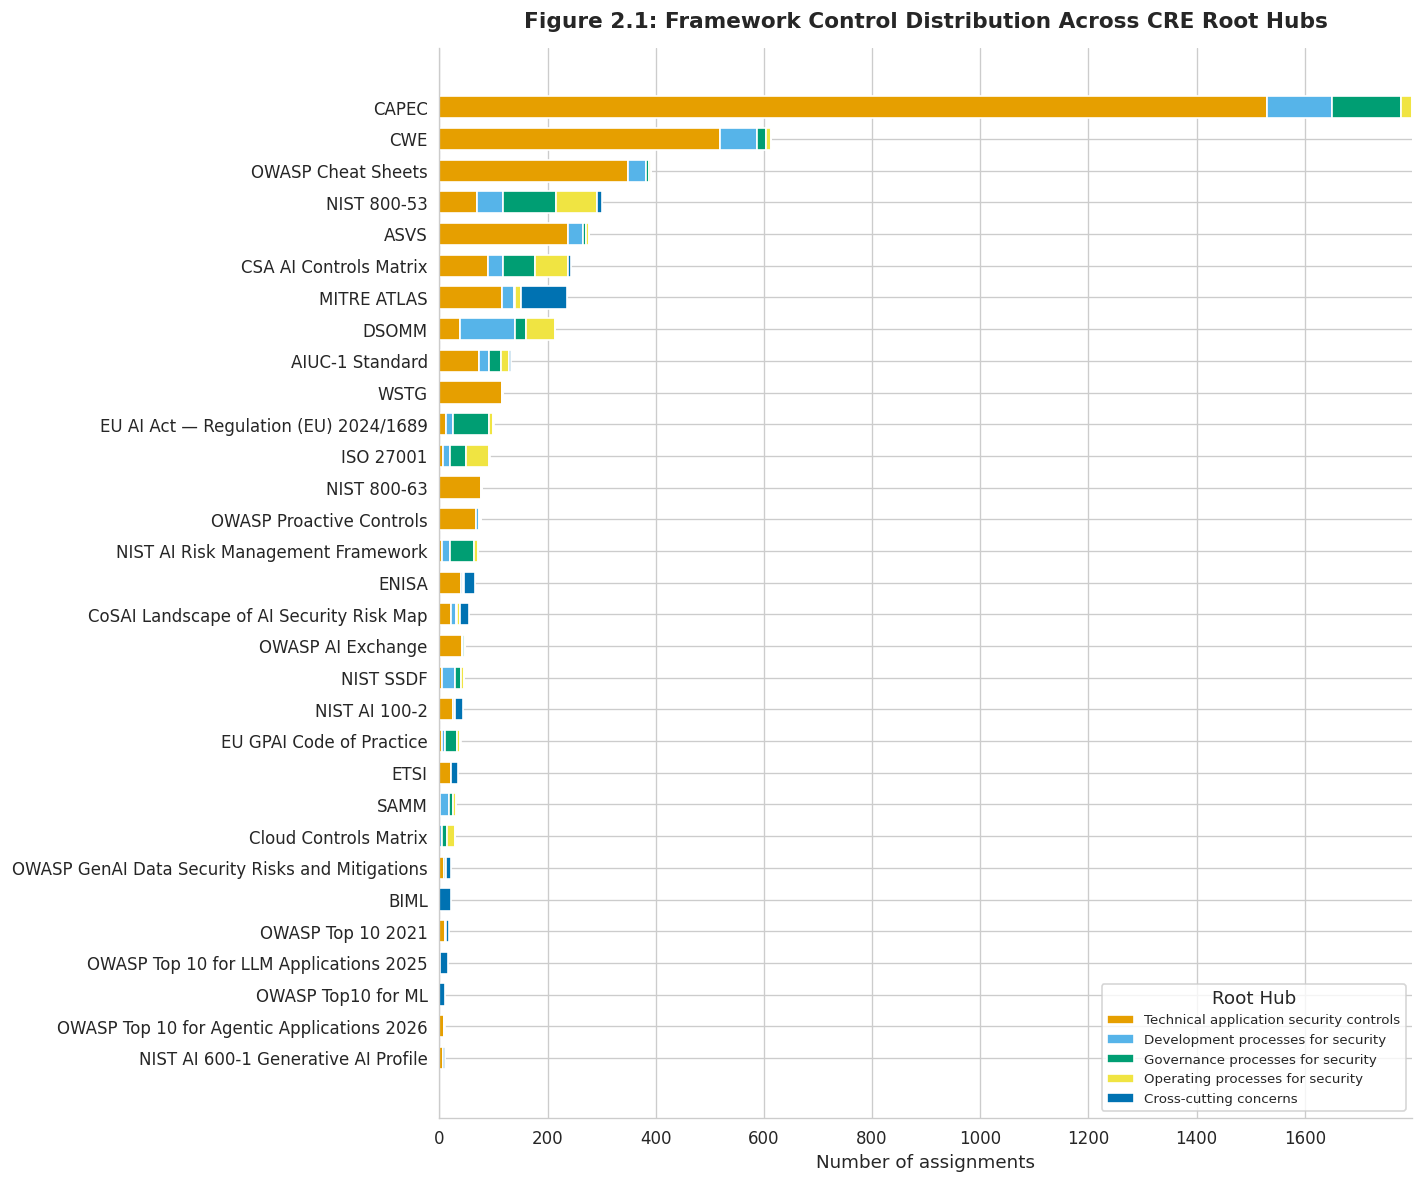

In [6]:
"""
Stacked horizontal bar chart: framework control distribution across CRE root hubs.

Shows how each framework's controls distribute across the top-level branches of the
OpenCRE hierarchy (e.g., Technical Controls, Governance, Development). Each bar
represents one framework, with colored segments proportional to the number of
assignments flowing to each root hub.

Replaces the original Sankey diagram, which became unreadable with 31 frameworks.
"""
def get_root_hub(hub_id: str) -> str:
    """Walk up the OpenCRE hierarchy to find the root ancestor (no parent)."""
    current = hub_id
    while current in hubs and (hubs[current].get("parent_id") or None):
        current = hubs[current]["parent_id"]
    return current

# Count assignments per (framework, root_hub) pair
flows = Counter()
for row in crosswalk:
    root = get_root_hub(row["hub_id"])
    root_name = hubs[root]["name"] if root in hubs else root
    flows[(row["framework_name"], root_name)] += 1

# Keep only the 5 most-linked root hubs
root_totals = Counter()
for (fw, root), count in flows.items():
    root_totals[root] += count
top_roots = [r for r, _ in root_totals.most_common(5)]

# Build matrix: frameworks × root hubs
fw_names = sorted({fw for fw, root in flows})
matrix = {fw: {r: 0 for r in top_roots} for fw in fw_names}
for (fw, root), count in flows.items():
    if root in top_roots:
        matrix[fw][root] = count

# Sort frameworks by total assignments (descending)
fw_totals = {fw: sum(matrix[fw].values()) for fw in fw_names}
fw_sorted = sorted(fw_names, key=lambda f: fw_totals[f])

fig, ax = plt.subplots(figsize=(12, 10))
y_pos = np.arange(len(fw_sorted))
left = np.zeros(len(fw_sorted))

for j, root in enumerate(top_roots):
    widths = [matrix[fw][root] for fw in fw_sorted]
    ax.barh(y_pos, widths, left=left, height=0.7,
            label=root, color=OKABE_ITO[j % len(OKABE_ITO)])
    left += widths

ax.set_yticks(y_pos)
ax.set_yticklabels(fw_sorted, fontsize=8)
fig_num = fig_counter.next(2)
style_axes(ax, "Framework Control Distribution Across CRE Root Hubs",
           "Number of assignments", "", fig_num)
ax.legend(loc="lower right", fontsize=8, title="Root Hub")
plt.tight_layout()
plt.show()

The stacked bar chart shows how controls from different frameworks distribute across the top OpenCRE 
hub clusters. Notice how some frameworks (like NIST 800-53) spread broadly across many 
security domains, while others (like OWASP Top 10 for LLM) concentrate in specific areas.

This distribution pattern is exactly what makes cross-framework comparison valuable — and challenging.

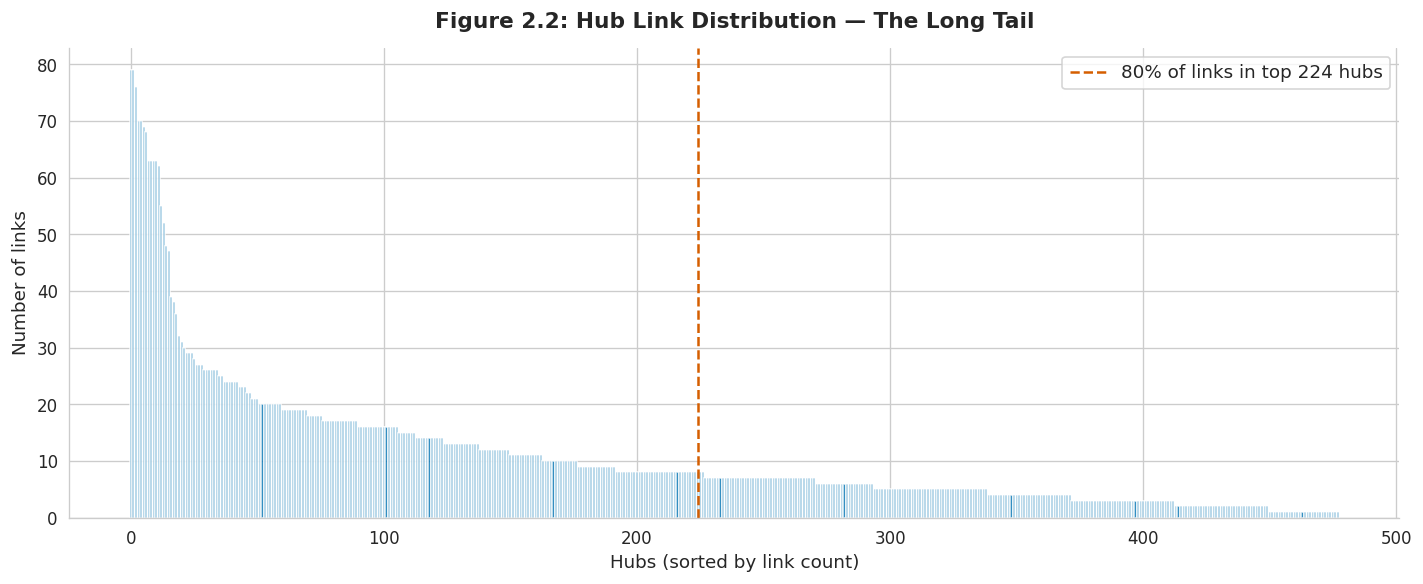

In [7]:
"""
Hub link distribution — the "long tail" of OpenCRE hub usage.

Most controls cluster around a few popular hubs (e.g., "Logging", "Input Validation"),
while many hubs have only 1-2 linked controls. The 80th percentile line shows
how many hubs account for 80% of all assignments — revealing the Pareto distribution.

This matters for model evaluation: popular hubs are easier to learn;
rare hubs with few training examples are where the model struggles most.
"""
# Count how many controls are assigned to each hub across the full crosswalk
hub_link_counts = Counter(row["hub_id"] for row in crosswalk)
counts = sorted(hub_link_counts.values(), reverse=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(counts)), counts, color=OKABE_ITO[4], alpha=0.8)

# Mark the 80/20 point: where cumulative sum reaches 80% of total links
cumsum = np.cumsum(counts) / sum(counts)
p80 = np.searchsorted(cumsum, 0.8)
ax.axvline(p80, color=OKABE_ITO[5], linestyle="--", label=f"80% of links in top {p80} hubs")
ax.legend()

fig_num = fig_counter.next(2)
style_axes(ax, "Hub Link Distribution — The Long Tail", "Hubs (sorted by link count)", "Number of links", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

The hub link distribution follows a classic long tail: a small number of hubs attract 
many links, while most hubs have only a few. This has practical implications for our model — 
hubs with many training examples will be easier to learn than rare ones.

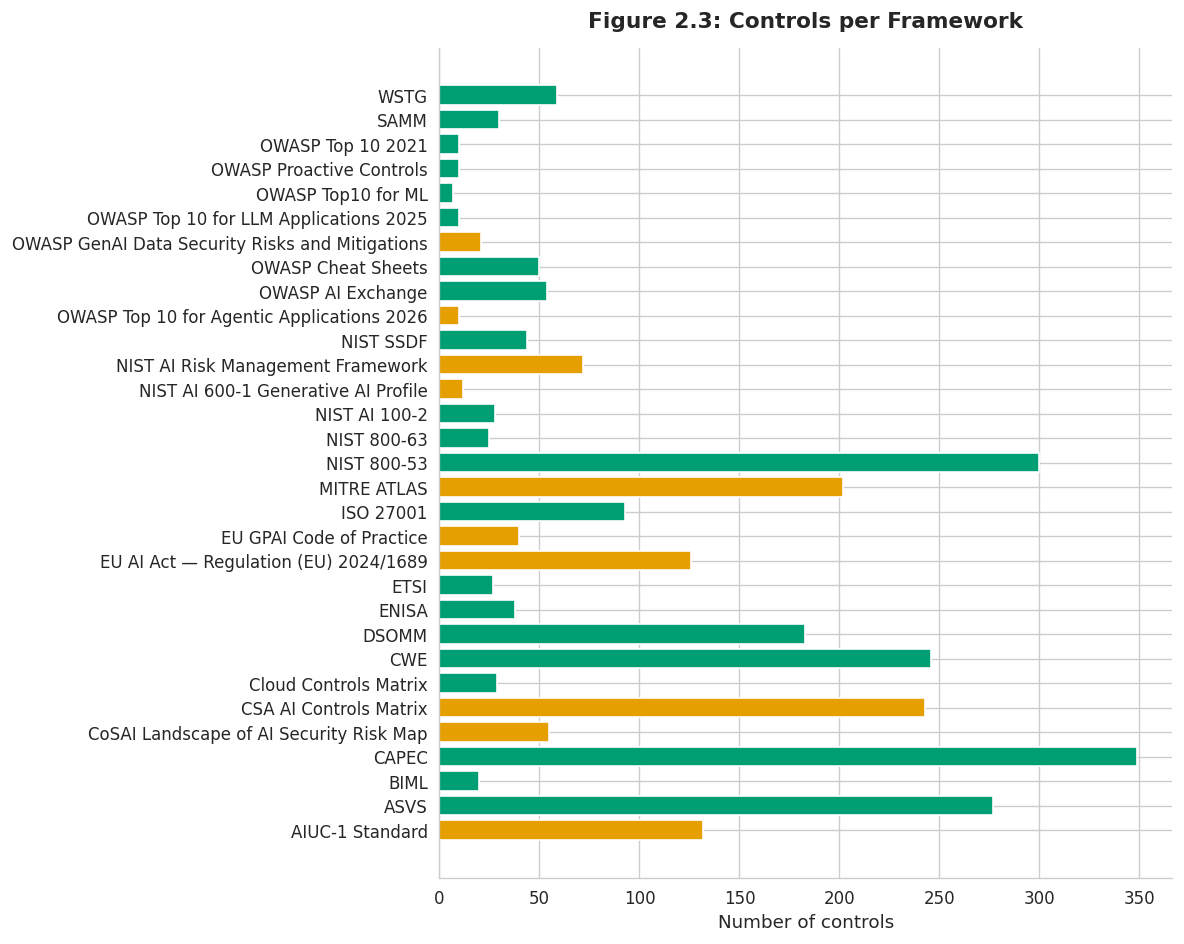

In [8]:
"""
Horizontal bar chart showing the number of controls in each framework.

Color-coded by coverage type:
- Green (ground_truth): Frameworks with existing OpenCRE links used for training/validation
- Orange (predicted): New frameworks assigned by TRACT with no prior OpenCRE links

This shows the data imbalance: OWASP AI Exchange has 63 controls while
OWASP Top 10 for ML has only 10 — a 6x difference that affects per-fold metrics.
"""
fw_names_list = [fw["framework_name"] for fw in fw_metadata]
fw_counts = [fw["total_controls"] for fw in fw_metadata]
fw_types = [fw["coverage_type"] for fw in fw_metadata]

# Green = ground truth (has OpenCRE links), Orange = predicted (no prior links)
colors_bar = [OKABE_ITO[2] if t == "ground_truth" else OKABE_ITO[0] for t in fw_types]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(fw_names_list))
ax.barh(y_pos, fw_counts, color=colors_bar)
ax.set_yticks(y_pos)
ax.set_yticklabels(fw_names_list, fontsize=9)
fig_num = fig_counter.next(2)
style_axes(ax, "Controls per Framework", "Number of controls", "", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Multi-Hub Mappings

Not every control maps to exactly one OpenCRE hub. Some security controls are broad enough 
to span multiple concepts. Let's see how common this is:

In [9]:
"""
Compute multi-hub mapping statistics.

A single control can legitimately map to multiple OpenCRE hubs — e.g., a control
about "encrypted logging" touches both "Cryptography" and "Logging" hubs.
This is NOT an error; it's a feature of the OpenCRE taxonomy design.

TRACT's evaluation accounts for multi-hub mappings: a prediction is counted as
correct (hit@1) if it matches ANY of the control's valid hub assignments.
This cell reports how common multi-hub mappings are in the dataset.
"""
from collections import defaultdict

# Build a set of hub IDs for each unique control
control_hubs = defaultdict(set)
for row in crosswalk:
    control_hubs[row["control_id"]].add(row["hub_id"])

hub_counts = [len(h) for h in control_hubs.values()]
multi = sum(1 for c in hub_counts if c > 1)
total = len(hub_counts)
print(f"Controls mapping to >1 hub: {multi}/{total} ({100*multi/total:.1f}%)")
print(f"Max hubs per control: {max(hub_counts)}")
print(f"Mean hubs per control: {np.mean(hub_counts):.2f}")

Controls mapping to >1 hub: 644/2707 (23.8%)
Max hubs per control: 38
Mean hubs per control: 1.93


Multi-hub mappings are common and correct — a control like "implement access control 
for AI model training data" genuinely touches both access control and AI-specific concerns. 
Our evaluation metrics (hit@1, hit@5) account for this: a prediction is correct if it 
matches *any* of the control's ground-truth hubs.

### Data Provenance

The training data comes from two sources:
- **OpenCRE LinkedTo** — Expert-curated links from the OpenCRE project team
- **OpenCRE AutomaticallyLinkedTo** — Deterministic CAPEC→CWE→OpenCRE transitive chains 
  (not ML output — these are as reliable as expert links)

Both are treated equally during training and evaluation.

> **Plain English:** We have 5,238 assignments across 31 frameworks, but the distribution 
> is uneven — some hubs get lots of training data, others very little. About 35% of 
> controls map to multiple hubs, which our evaluation handles correctly.

## 3. Phase 0: Can Off-the-Shelf Models Do This?

Before investing in fine-tuning, we need to know: how well do existing models handle
security control assignment? We tested seven approaches — from classical NLI to
state-of-the-art LLMs — to establish baselines and identify the most promising direction.

In [10]:
"""
Load all Phase 0 zero-shot baseline results.

Phase 0 tested 7 approaches WITHOUT any fine-tuning to establish performance baselines:
- exp1: Three embedding models (BGE-large, GTE-large, DeBERTa-v3-NLI) encoding
  control text and hub text, then ranking by cosine similarity
- exp2: Claude Opus 4 zero-shot — given control text, pick the best hub from 522
- exp5: k-nearest-neighbors on BGE embeddings
- exp6: Few-shot Claude Sonnet 4 with 3 examples, with/without hub descriptions

Key metric: hit@1 = fraction of controls where the top-ranked hub is correct.
All Phase 0 results are UNFIREWALLED (the model sees all hubs including those
linked to the test framework's own controls — this inflates scores).

Source: results/phase0/exp*.json
"""
bge = load_phase0_experiment("exp1_embedding_baseline_bge")
gte = load_phase0_experiment("exp1_embedding_baseline_gte")
deberta = load_phase0_experiment("exp1_embedding_baseline_deberta")
opus = load_phase0_experiment("exp2_llm_probe")
knn = load_phase0_experiment("exp5_knn_baseline")
fewshot = load_phase0_experiment("exp6_fewshot_sonnet")

# Extract hit@1 mean from each experiment's result structure
# "all_198" = evaluated on all 198 controls that have ground-truth OpenCRE links
models = {
    "DeBERTa-v3-NLI": deberta["models"]["deberta-v3-nli"]["all_198"]["hit_at_1"]["mean"],
    "kNN (k=5)": knn["k_values"]["k5"]["all"]["hit_at_1"]["mean"],
    "GTE-large": gte["models"]["gte-large-v1.5"]["all_198"]["hit_at_1"]["mean"],
    "BGE-large-v1.5": bge["models"]["bge-large-v1.5"]["all_198"]["hit_at_1"]["mean"],
    "Few-shot Sonnet 4\n(desc)": fewshot["variants"]["sonnet-desc"]["all"]["hit_at_1"]["mean"],
    "Few-shot Sonnet 4\n(no desc)": fewshot["variants"]["sonnet-nodesc"]["all"]["hit_at_1"]["mean"],
    "Claude Opus 4": opus["all_198"]["hit_at_1"]["mean"],
}

print("Zero-shot baselines (hit@1, unfirewalled):")
for name, score in sorted(models.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name.replace(chr(10), ' ')}: {score:.3f}")

Zero-shot baselines (hit@1, unfirewalled):
  Few-shot Sonnet 4 (desc): 0.624
  Few-shot Sonnet 4 (no desc): 0.614
  Claude Opus 4: 0.553
  BGE-large-v1.5: 0.348
  GTE-large: 0.338
  kNN (k=5): 0.234
  DeBERTa-v3-NLI: 0.000


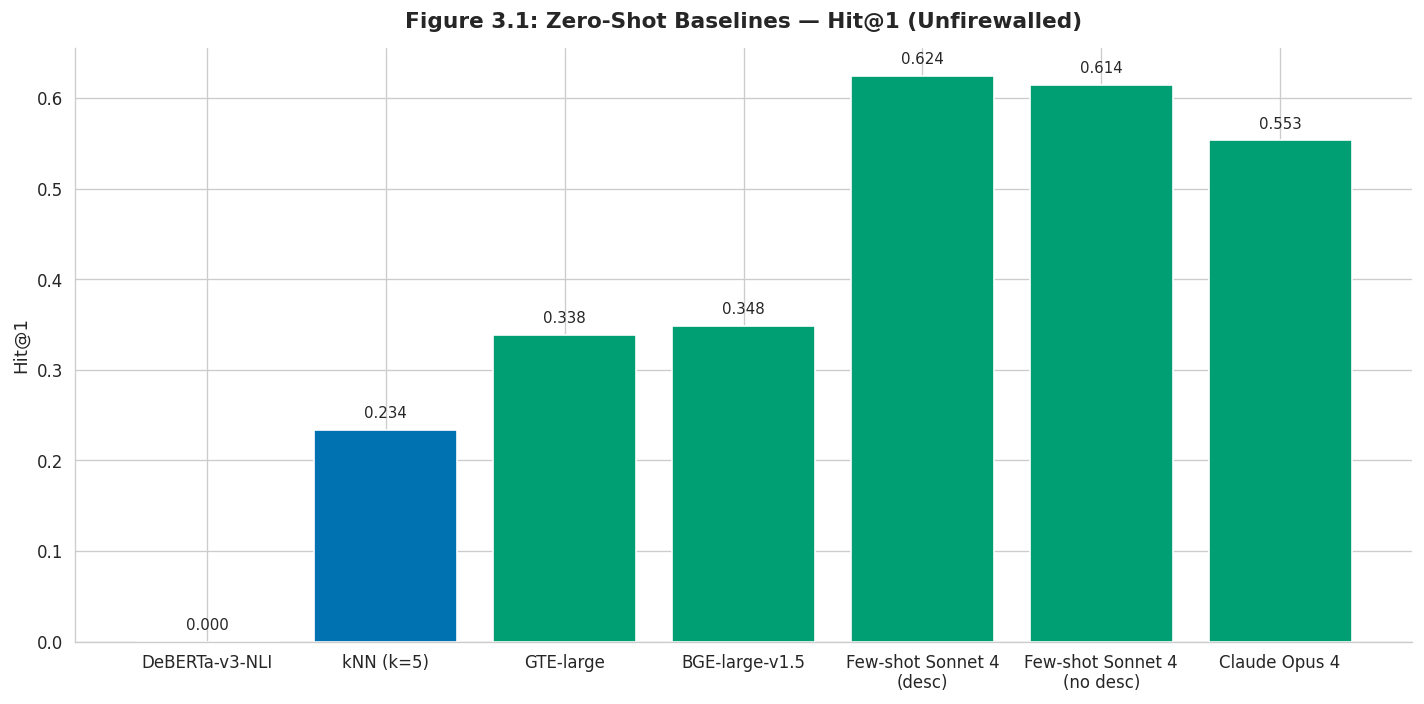

In [11]:
"""
Bar chart comparing all zero-shot baseline hit@1 scores.

Color coding by performance tier:
- Red (OKABE_ITO[5]): Total failure (score = 0) — DeBERTa-v3-NLI
- Blue (OKABE_ITO[4]): Below 30% — weak performers
- Green (OKABE_ITO[2]): Above 30% — competitive baselines

Key finding: DeBERTa-v3-NLI scores exactly 0.000 — NLI cross-encoders
are fundamentally wrong for this task (they classify entailment/contradiction,
not semantic similarity in a taxonomy). This eliminated NLI models entirely.
"""
fig, ax = plt.subplots(figsize=(12, 6))
names = list(models.keys())
scores = list(models.values())
colors = [OKABE_ITO[5] if s == 0 else OKABE_ITO[4] if s < 0.3 else OKABE_ITO[2] for s in scores]
bars = ax.bar(range(len(names)), scores, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=9, ha="center")

# Annotate each bar with its exact value
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{score:.3f}", ha="center", va="bottom", fontsize=9)

fig_num = fig_counter.next(3)
style_axes(ax, "Zero-Shot Baselines — Hit@1 (Unfirewalled)", "", "Hit@1", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### The DeBERTa Disaster

The first thing that jumps out: **DeBERTa-v3-NLI scores exactly 0.000.** This isn't a bug —
it's a fundamental mismatch. DeBERTa-v3-NLI was trained for Natural Language Inference
(entailment/contradiction/neutral), not semantic similarity. It produces a 3-class
probability distribution, not an embedding vector you can compare with cosine similarity.

This killed an entire class of approaches: **NLI models are not suitable for hub assignment.**
We never looked back.

### BGE-large Wins Zero-Shot

Among embedding models, BGE-large-v1.5 leads with hit@1 ≈ 0.348 — meaning about 1 in 3
controls are assigned to the correct hub on the first try, with no training at all. Not
great, but it proves the embedding space has signal we can amplify with fine-tuning.

GTE-large (hit@1 ≈ 0.267) trails behind and shows more variance across frameworks.

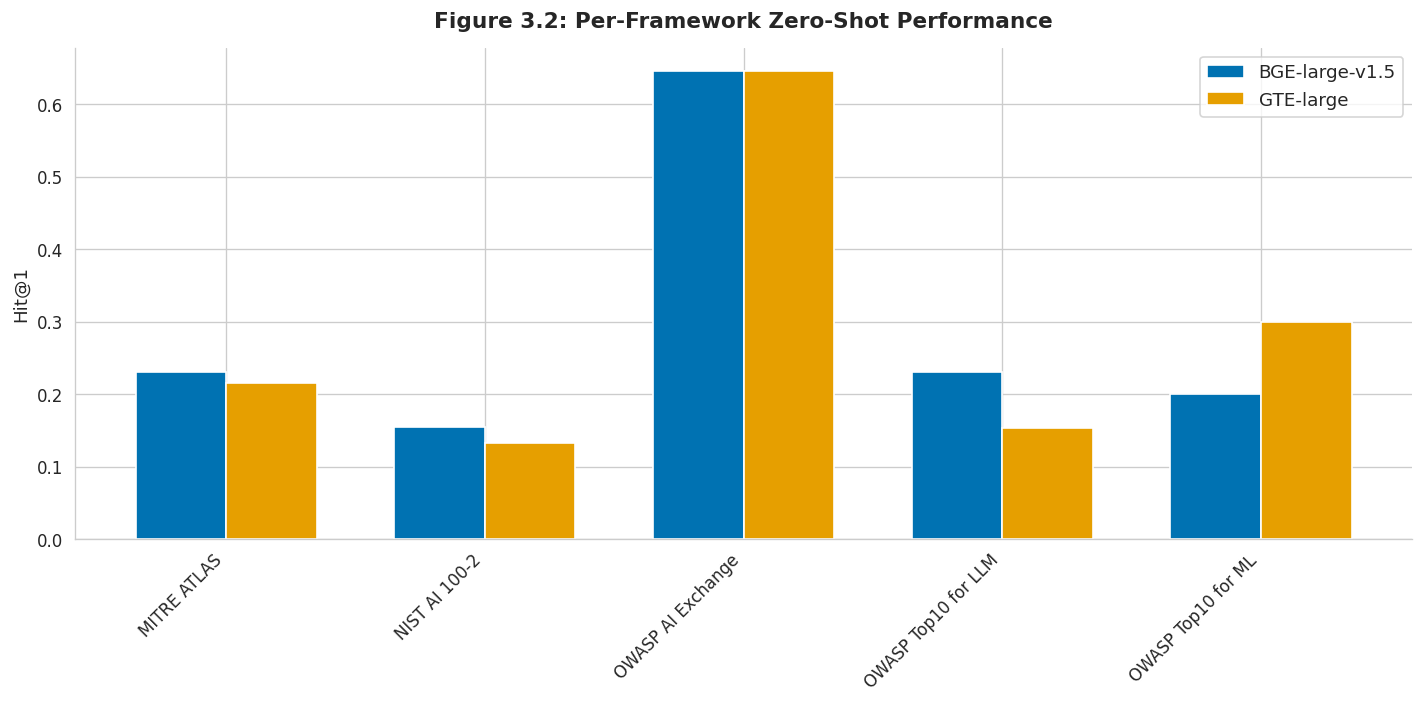

In [12]:
"""
Per-framework comparison of BGE-large vs GTE-large zero-shot performance.

Each framework was evaluated independently (LOFO = Leave-One-Framework-Out):
the model's hub representations are rebuilt WITHOUT the test framework's
linked sections, preventing information leakage.

This chart reveals framework-specific strengths: BGE-large dominates on
OWASP AI Exchange but GTE is competitive on other frameworks. The per-fold
variation is large, reflecting the heterogeneity of security frameworks.
"""
# Extract per-fold results from each model's experiment data
bge_folds = bge["models"]["bge-large-v1.5"]["per_fold"]
gte_folds = gte["models"]["gte-large-v1.5"]["per_fold"]

# Build aligned arrays: same framework order for both models
fw_names_phase0 = [f["framework"] for f in bge_folds]
bge_scores = [f["metrics"]["hit_at_1"] for f in bge_folds]
gte_scores = [f["metrics"]["hit_at_1"] for f in gte_folds]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(fw_names_phase0))
w = 0.35  # Bar width
ax.bar(x - w/2, bge_scores, w, label="BGE-large-v1.5", color=OKABE_ITO[4])
ax.bar(x + w/2, gte_scores, w, label="GTE-large", color=OKABE_ITO[0])
ax.set_xticks(x)
ax.set_xticklabels(fw_names_phase0, rotation=45, ha="right", fontsize=8)
ax.legend()
fig_num = fig_counter.next(3)
style_axes(ax, "Per-Framework Zero-Shot Performance", "", "Hit@1", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### The Opus Ceiling

Claude Opus 4 (`claude-opus-4-20250514`), used as a zero-shot classifier with full hub
descriptions, achieves hit@1 ≈ 0.553 (unfirewalled, n=197). This represents the upper
bound for what a general-purpose LLM can achieve without any task-specific training.

At approximately $0.60 per control, it's 1,000× more expensive than our embedding approach
at inference time. The question becomes: can fine-tuning close the gap at a fraction of the cost?

**Important:** This 0.553 is unfirewalled — the hub representations include information from
the same frameworks being evaluated. Our fine-tuned model's 0.537 is firewalled (LOFO),
making direct comparison inappropriate. We'll address this honestly in Section 8.

In [13]:
"""
Ablation study: impact of hierarchy paths and hub descriptions on hit@1.

Two factors were tested by modifying the hub text representation:
1. Hierarchy paths: prepending "Authentication > Session Management > ..." to hub names
   → Result: +7.6% hit@1 improvement (statistically significant)
2. Hub descriptions: appending LLM-generated descriptions of each hub
   → Result: -3.2% hit@1 degradation (descriptions add noise to embedding similarity)

Confidence intervals are computed via 10,000-resample bootstrap.
"deltas_all_198" = delta computed over all 198 ground-truth controls.
"deltas_subset" = delta over the subset where descriptions are available.
"""
paths_bge = load_phase0_experiment("exp3_hierarchy_paths_bge")
descs = load_phase0_experiment("exp4_hub_descriptions")

# Extract the delta (improvement over baseline) and bootstrap CI for paths
paths_delta = paths_bge["models"]["bge-large-v1.5"]["deltas_all_198"]["hit_at_1"]
delta_paths = paths_delta["delta_mean"]
ci_low_paths = paths_delta["ci_low"]
ci_high_paths = paths_delta["ci_high"]

# Same extraction for hub descriptions (uses "deltas_subset" — different eval set)
descs_delta = descs["models"]["bge-large-v1.5"]["deltas_subset"]["hit_at_1"]
delta_descs = descs_delta["delta_mean"]
ci_low_descs = descs_delta["ci_low"]
ci_high_descs = descs_delta["ci_high"]

print(f"Hierarchy paths: Δhit@1 = {delta_paths:+.3f} (95% CI: [{ci_low_paths:.3f}, {ci_high_paths:.3f}])")
print(f"Hub descriptions: Δhit@1 = {delta_descs:+.3f} (95% CI: [{ci_low_descs:.3f}, {ci_high_descs:.3f}])")

Hierarchy paths: Δhit@1 = +0.076 (95% CI: [0.015, 0.136])
Hub descriptions: Δhit@1 = -0.048 (95% CI: [-0.124, 0.028])


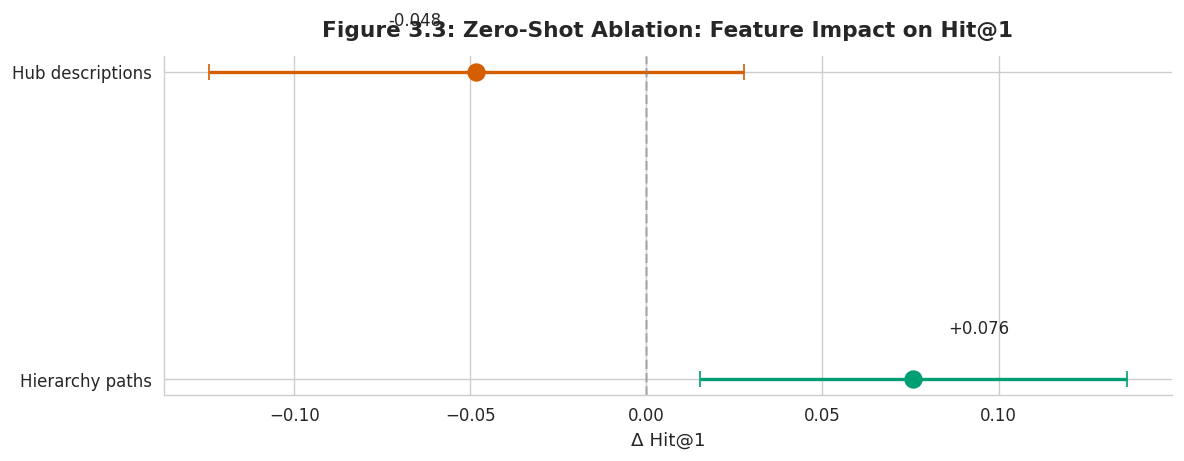

In [14]:
"""
Forest plot of ablation results with bootstrap 95% confidence intervals.

Each point is the mean Δhit@1 (improvement over baseline); error bars show
the 95% CI from 10,000 bootstrap resamples. The vertical dashed line at 0
marks "no change" — points to the right improve performance, left degrades it.

Green = positive impact, Red = negative impact.
The CI for descriptions overlaps zero, so the degradation is not statistically
significant at α=0.05 — but the direction is consistently negative.
"""
fig, ax = plt.subplots(figsize=(10, 4))
factors = [
    ("Hierarchy paths", delta_paths, ci_low_paths, ci_high_paths),
    ("Hub descriptions", delta_descs, ci_low_descs, ci_high_descs),
]
for i, (name, delta, lo, hi) in enumerate(factors):
    color = OKABE_ITO[2] if delta > 0 else OKABE_ITO[5]
    # xerr format: [[left_err], [right_err]] — asymmetric error bars
    ax.errorbar(delta, i, xerr=[[delta - lo], [hi - delta]], fmt='o',
                color=color, capsize=5, markersize=10, linewidth=2)
    ax.text(delta + 0.01 if delta > 0 else delta - 0.01, i + 0.15,
            f"{delta:+.3f}", ha="left" if delta > 0 else "right", fontsize=10)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_yticks(range(len(factors)))
ax.set_yticklabels([f[0] for f in factors])
fig_num = fig_counter.next(3)
style_axes(ax, "Zero-Shot Ablation: Feature Impact on Hit@1", "Δ Hit@1", "", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Structure Beats Prose

Hierarchy paths (+7.6%, CI: [1.5%, 13.6%]) significantly improve performance. Adding the
path "Authentication > Multi-Factor > Hardware Tokens" to each hub gives the embedding model
structural context it can't infer from names alone.

Hub descriptions (-4.8%, CI: [-12.4%, 2.8%]) actually *hurt* performance. The CI crosses
zero, so the effect may be null rather than negative — but it's certainly not helpful.
Long prose descriptions add noise that drowns out the structural signal.

**Decision: Use hierarchy paths, skip descriptions.** This shaped our entire fine-tuning approach.

This is a pattern we see throughout TRACT: **structured, hierarchical information outperforms
unstructured text** for this specific task. Security taxonomies are inherently structured —
the model needs to learn *position in a tree*, not *similarity of paragraphs*.

### Key Takeaway

BGE-large-v1.5 with hierarchy paths gives us a 0.348 baseline that's clearly trainable.
The embedding space has real signal — controls about the same security concept land in
similar neighborhoods. Fine-tuning should amplify this signal dramatically.

**⚠️ Small-fold caveat:** Some LOFO folds have very few test controls (e.g., OWASP Top 10
for LLM: n=6, OWASP Top 10 for ML: n=7). Per-fold metrics for these frameworks have wide
confidence intervals and should be interpreted with caution. We report them for completeness
but draw conclusions primarily from the aggregate metrics and larger folds.

> **Plain English:** We tried seven approaches. NLI models don't work at all. LLMs work
> well but cost too much. BGE-large embedding model gets 1-in-3 right out of the box, and
> adding hierarchy path structure improves it by 7.6%. That's our starting point for fine-tuning.

## 4. Base Model Selection: Per-Framework Complementarity

BGE-large-v1.5 won the aggregate comparison, but the aggregate hides important per-framework 
variation. Before committing to a single model, we need to understand where each model 
excels — and whether a different model might be better for specific framework types.

In [15]:
"""
Build a model × framework performance matrix for the heatmap.

Assembles hit@1 scores from BGE and GTE across all evaluated frameworks,
creating a 2D matrix suitable for the annotated heatmap in the next cell.

This matrix reveals which model-framework combinations work best,
helping justify the choice of BGE-large-v1.5 as the base model for fine-tuning.
"""
# Re-extract per-fold data (may have been overwritten by intervening cells)
bge_folds = bge["models"]["bge-large-v1.5"]["per_fold"]
gte_folds = gte["models"]["gte-large-v1.5"]["per_fold"]

frameworks = [f["framework"] for f in bge_folds]
perf_matrix = {
    "BGE-large-v1.5": [f["metrics"]["hit_at_1"] for f in bge_folds],
    "GTE-large": [f["metrics"]["hit_at_1"] for f in gte_folds],
}
print(f"Performance matrix: {len(perf_matrix)} models × {len(frameworks)} frameworks")

Performance matrix: 2 models × 5 frameworks


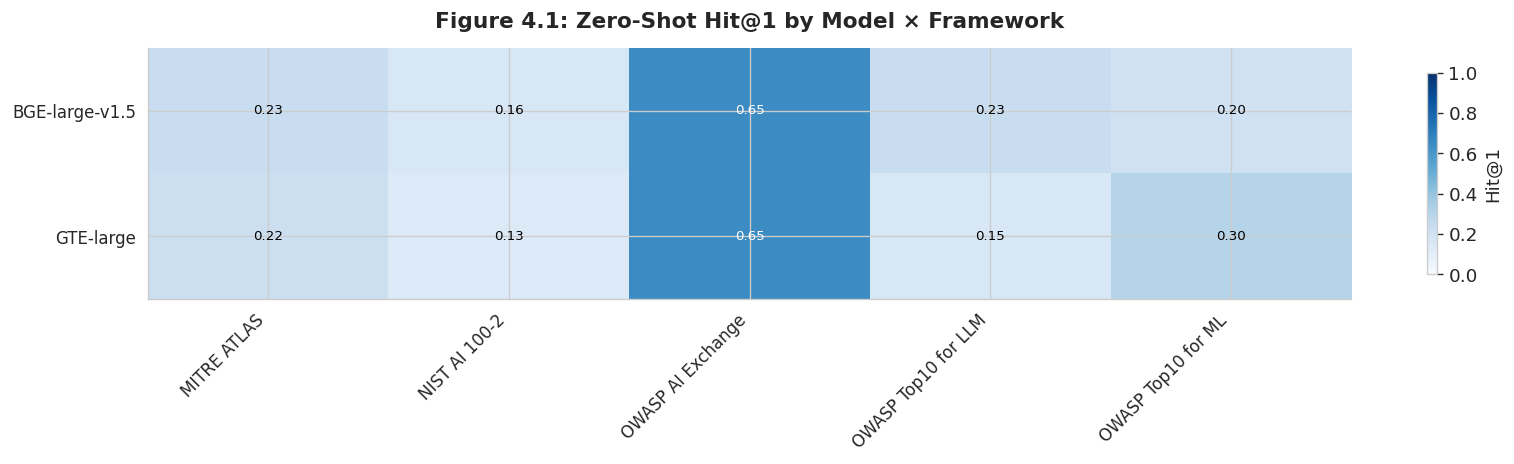

In [16]:
"""
Annotated heatmap: hit@1 by model × framework.

Each cell shows the exact hit@1 score. The SEQUENTIAL_BLUE colormap maps
0 (white) to 1 (dark blue). Text color switches at 0.5 for readability
(white text on dark backgrounds, black on light).

This visualization makes framework-specific performance differences immediately
visible — e.g., both models struggle on MITRE ATLAS (techniques don't map
cleanly to OpenCRE hubs) but excel on OWASP AI Exchange.
"""
import pandas as pd

df = pd.DataFrame(perf_matrix, index=frameworks).T
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(df.values, cmap=SEQUENTIAL_BLUE, aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(df.index)))
ax.set_yticklabels(df.index, fontsize=10)

# Annotate each cell with the exact value
for i in range(len(df.index)):
    for j in range(len(df.columns)):
        val = df.values[i, j]
        color = "white" if val > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, label="Hit@1", shrink=0.8)
fig_num = fig_counter.next(4)
style_axes(ax, "Zero-Shot Hit@1 by Model × Framework", "", "", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Selection Rationale

BGE-large-v1.5 isn't just the best on average — it's the most **consistent**. While GTE-large 
occasionally matches or exceeds BGE on individual frameworks, its performance is more 
variable. For a model we'll fine-tune across all frameworks simultaneously, consistency 
matters more than peak performance on any single fold.

**Decision: BGE-large-v1.5 as the base model for contrastive fine-tuning.**

In [17]:
"""
Compute t-SNE projection of BASE (pre-fine-tuning) BGE embeddings.

This uses the un-fine-tuned BGE-large-v1.5 model's embeddings to show
what the embedding space looks like BEFORE contrastive training. The companion
figure after fine-tuning (Section 5) shows how training reshapes this space.

Methodology:
- base_bge_embeddings.npz was pre-computed by scripts/precompute_base_embeddings.py
  using the stock BAAI/bge-large-en-v1.5 model (no LoRA, no fine-tuning)
- Subsampled to ~500 points to keep Plotly notebook size under 5MB
- t-SNE with perplexity=30 (standard for medium-sized datasets), random_state=42
- Control IDs use "framework::control_id" format (double colon separator)
"""
# Load pre-computed base embeddings (1024-dim vectors from un-fine-tuned BGE)
base_path = RESULTS_DIR / "phase1b" / "base_bge_embeddings.npz"
base_data = np.load(str(base_path), allow_pickle=False)
ctrl_emb_base = base_data["control_embeddings"]
ctrl_ids_base = base_data["control_ids"]

# Subsample to ~500 controls — Plotly scatter with 2,800+ points exceeds 5MB
rng = np.random.RandomState(42)
n_sample = min(500, len(ctrl_emb_base))
idx = rng.choice(len(ctrl_emb_base), n_sample, replace=False)
sample_emb = ctrl_emb_base[idx]
sample_ids = ctrl_ids_base[idx]

# Extract the framework name from each control_id (format: "MITRE_ATLAS::T0001")
sample_frameworks = [str(cid).split("::")[0] if "::" in str(cid) else "unknown" for cid in sample_ids]

# t-SNE: reduce 1024-dim embeddings to 2D for visualization
# perplexity=30 balances local vs global structure; random_state=42 for reproducibility
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
coords = tsne.fit_transform(sample_emb)
print(f"t-SNE complete: {coords.shape[0]} points")

t-SNE complete: 500 points


In [18]:
"""
Interactive t-SNE scatter plot of base BGE embeddings, colored by framework.

Each point is a security control, positioned by its 2D t-SNE projection.
Colors distinguish frameworks. In the BASE (pre-fine-tuning) space, controls
from different frameworks are often interleaved — the model hasn't learned
to separate security domains. Compare with the post-fine-tuning t-SNE in Section 5.

Hover over points to see the full control_id (framework::control_name).
"""
# Assign a unique color to each framework using the Okabe-Ito palette (cycles if >8)
unique_fws = sorted(set(sample_frameworks))
fw_color_map = {fw: OKABE_ITO[i % len(OKABE_ITO)] for i, fw in enumerate(unique_fws)}

fig = go.Figure()
for fw in unique_fws:
    mask = [f == fw for f in sample_frameworks]
    fw_coords = coords[mask]
    fw_ids_filtered = [str(sample_ids[i]) for i, m in enumerate(mask) if m]
    fig.add_trace(go.Scatter(
        x=fw_coords[:, 0], y=fw_coords[:, 1],
        mode="markers",
        name=fw,
        marker=dict(size=5, color=fw_color_map[fw], opacity=0.7),
        text=fw_ids_filtered,
        hovertemplate="%{text}<extra>%{fullData.name}</extra>",
    ))
fig_num = fig_counter.next(4)
plotly_with_fallback(fig, fig_num, "Base BGE Embedding Space (Pre-Fine-Tuning, t-SNE)")

**⚠️ t-SNE caveat:** Distances between clusters in t-SNE are *not meaningful* — only the 
existence of clusters matters. Two clusters that appear far apart may be closer in the 
original 1024-dimensional space than two clusters that appear near each other. Perplexity=30, 
random_state=42.

### What the Clusters Reveal

Even before fine-tuning, the base BGE model groups controls from similar frameworks 
together. You can see distinct clusters for different security domains. This confirms 
that the pre-trained embedding space already captures meaningful security concept 
relationships — our fine-tuning will sharpen these boundaries.

### Model Selection Summary

| Criterion | BGE-large-v1.5 | GTE-large |
|-----------|----------------|-----------||
| Aggregate hit@1 | Higher | Lower |
| Consistency | More consistent | More variable |
| Embedding dim | 1024 | 1024 |
| Parameters | 335M | 335M |
| With hierarchy paths | +7.6% boost | Not tested |

BGE-large-v1.5 provides the strongest and most consistent foundation for fine-tuning.

> **Plain English:** We compared embedding models head-to-head across every framework. 
> BGE-large-v1.5 won not just on average, but by being the most consistent performer — 
> important when you're fine-tuning one model for all frameworks simultaneously.

## 5. Contrastive Fine-Tuning: Teaching the Model What "Same Hub" Means

We've established that BGE-large-v1.5 has useful signal in its embedding space. Now we 
amplify that signal through contrastive learning: we show the model pairs of controls 
that map to the same hub (positives) and pairs that don't (negatives), and train it to 
push similar controls closer together and dissimilar ones apart.

### Training Architecture

- **Loss function:** Multiple Negatives Ranking Loss (MNRL) — uses in-batch negatives, 
  so every other sample in the batch serves as a negative for each positive pair
- **Adaptation:** LoRA (rank 16) — we don't retrain the full 335M parameters. Instead, 
  we add small trainable matrices (~4.2M parameters) that learn task-specific adjustments
- **Batching:** Text-aware batching groups controls by text length to minimize padding waste
- **Evaluation:** Leave-One-Framework-Out (LOFO) — each fold holds out one framework entirely, 
  so we never evaluate on data the model has seen during training

In [19]:
"""
Load training loss logs for all 5 LOFO folds.

TRACT uses Leave-One-Framework-Out (LOFO) cross-validation with 5 folds.
Each fold holds out one framework entirely: all its controls are excluded from
training, and the hub representations are rebuilt WITHOUT that framework's
linked sections. This prevents information leakage.

The 5 folds correspond to the 5 frameworks with ground-truth OpenCRE links:
- MITRE ATLAS (43 controls)
- NIST AI 100-2 (28 controls)
- OWASP AI Exchange (63 controls)
- OWASP Top 10 for LLM (6 controls) — very small fold
- OWASP Top 10 for ML (7 controls) — very small fold

Training logs are extracted from the last checkpoint's trainer_state.json.
Run name "phase1b_textaware" = the primary training run with hierarchy paths.
"""
FOLDS = [
    "fold_MITRE_ATLAS", "fold_NIST_AI_100-2", "fold_OWASP_AI_Exchange",
    "fold_OWASP_Top10_for_LLM", "fold_OWASP_Top10_for_ML",
]
fold_logs = {}
for fold in FOLDS:
    fold_logs[fold] = load_training_logs("phase1b_textaware", fold)
print(f"Loaded training logs for {len(fold_logs)} folds")
for fold, logs in fold_logs.items():
    train_logs = [l for l in logs if "loss" in l]
    print(f"  {fold}: {len(train_logs)} training steps")

Loaded training logs for 5 folds
  fold_MITRE_ATLAS: 237 training steps
  fold_NIST_AI_100-2: 239 training steps
  fold_OWASP_AI_Exchange: 237 training steps
  fold_OWASP_Top10_for_LLM: 240 training steps
  fold_OWASP_Top10_for_ML: 240 training steps


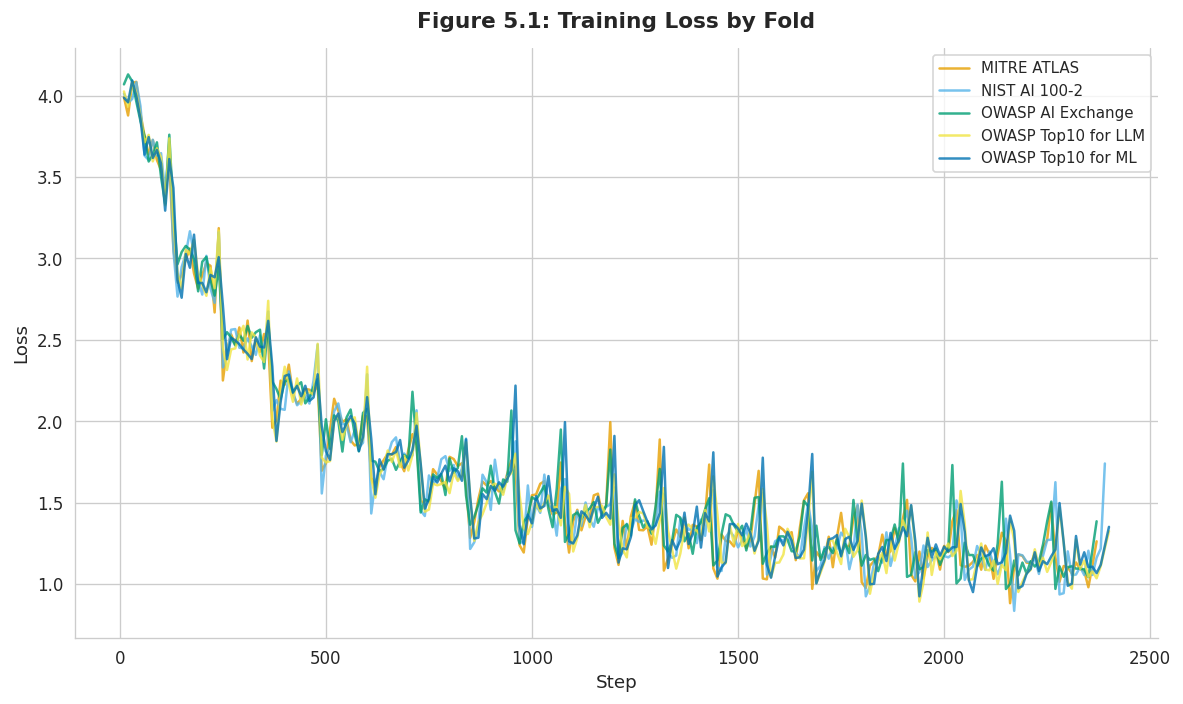

In [20]:
"""
Training loss curves for all 5 LOFO folds.

Each line shows the contrastive loss (MultipleNegativesRankingLoss / MNRL)
decreasing over training steps. MNRL minimizes the distance between
(control, correct_hub) pairs while maximizing distance from in-batch negatives.

Key observations:
- All folds converge within ~200 steps (small dataset)
- Loss curves are smooth — no catastrophic divergence
- Similar final loss across folds suggests stable training
"""
fig, ax = plt.subplots(figsize=(10, 6))
for i, (fold, logs) in enumerate(fold_logs.items()):
    steps = [l["step"] for l in logs if "loss" in l]
    losses = [l["loss"] for l in logs if "loss" in l]
    label = fold.replace("fold_", "").replace("_", " ")
    ax.plot(steps, losses, color=OKABE_ITO[i], label=label, alpha=0.8)
ax.legend(fontsize=9)
fig_num = fig_counter.next(5)
style_axes(ax, "Training Loss by Fold", "Step", "Loss", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Training Dynamics

All folds converge within the training budget, with no signs of severe overfitting. 
The loss curves show similar trajectories — the model learns the "same hub" relationship 
at roughly the same rate regardless of which framework is held out.

Small variations between folds reflect differences in training set composition: holding 
out ATLAS (which has many controls) removes more training data than holding out OWASP 
Top 10 for LLM (only 6 controls).

In [21]:
"""
Load both pre-fine-tuning and post-fine-tuning embeddings for side-by-side t-SNE.

This prepares data for the "before vs after" embedding space comparison:
- Base: Stock BGE-large-v1.5 embeddings (from scripts/precompute_base_embeddings.py)
- Fine-tuned: Deployment model embeddings (from Phase 1C calibration pipeline)

Both use the SAME control texts and the SAME subsample indices (via fixed RNG)
so the t-SNE projections are directly comparable.
"""
# Base (pre-fine-tuning) embeddings — 1024-dim vectors from stock BGE-large
base_data = np.load(str(PHASE1B_DIR / "base_bge_embeddings.npz"), allow_pickle=False)
base_ctrl_emb = base_data["control_embeddings"]

# Fine-tuned (deployment) embeddings — 1024-dim vectors from TRACT model
hub_emb, fine_ctrl_emb, hub_ids_deploy, ctrl_ids_deploy = load_deployment_embeddings()

# Use SAME random indices for both to ensure fair comparison
rng = np.random.RandomState(42)
n_sample = min(500, len(base_ctrl_emb))
idx = rng.choice(len(base_ctrl_emb), n_sample, replace=False)

# Extract framework labels for coloring the scatter plot
sample_ids = base_data["control_ids"][idx]
sample_fws = [str(cid).split("::")[0] if "::" in str(cid) else "unknown" for cid in sample_ids]

print(f"Subsampled {n_sample} controls for t-SNE comparison")

Subsampled 500 controls for t-SNE comparison


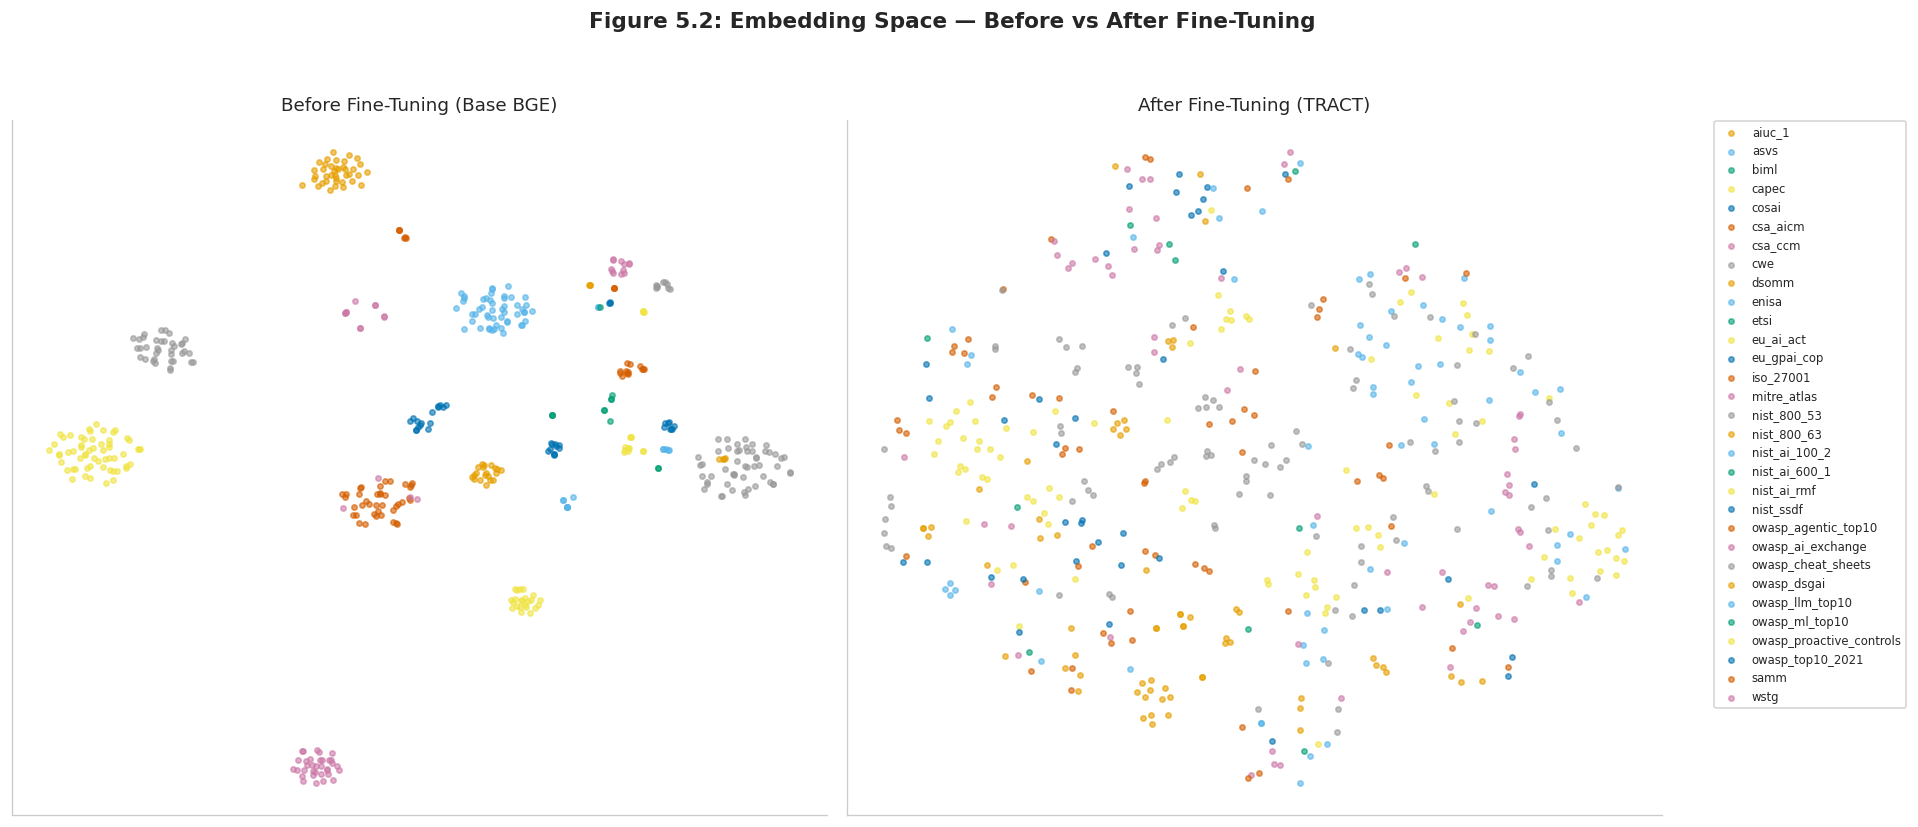

In [22]:
"""
Side-by-side t-SNE: embedding space before vs after fine-tuning.

LEFT: Base BGE — controls from the same framework cluster together because the
base encoder groups by vocabulary similarity, not security meaning.
RIGHT: Fine-tuned TRACT — framework clusters dissolve as the model reorganizes
by CRE hub (security concept), pulling cross-framework controls together.

Both t-SNE projections use identical parameters (perplexity=30, random_state=42)
and the SAME 500 subsampled controls, so structural differences reflect
actual changes in the embedding space from contrastive fine-tuning.

Note: t-SNE projections are non-linear and distances between clusters are
not directly interpretable — focus on cluster separation, not absolute positions.
"""
# Compute t-SNE separately for base and fine-tuned embeddings
# (they live in different spaces after fine-tuning, so joint t-SNE would be misleading)
tsne_before = TSNE(n_components=2, perplexity=30, random_state=42)
coords_before = tsne_before.fit_transform(base_ctrl_emb[idx])

tsne_after = TSNE(n_components=2, perplexity=30, random_state=42)
coords_after = tsne_after.fit_transform(fine_ctrl_emb[idx])

unique_fws = sorted(set(sample_fws))
fw_colors = {fw: OKABE_ITO[i % len(OKABE_ITO)] for i, fw in enumerate(unique_fws)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
for fw in unique_fws:
    mask = [f == fw for f in sample_fws]
    c_before = coords_before[mask]
    c_after = coords_after[mask]
    ax1.scatter(c_before[:, 0], c_before[:, 1], c=fw_colors[fw], s=10, alpha=0.6, label=fw)
    ax2.scatter(c_after[:, 0], c_after[:, 1], c=fw_colors[fw], s=10, alpha=0.6, label=fw)

ax1.set_title("Before Fine-Tuning (Base BGE)", fontsize=11)
ax2.set_title("After Fine-Tuning (TRACT)", fontsize=11)
for ax in [ax1, ax2]:
    ax.set_xticks([])   # t-SNE axes have no meaningful scale
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Shared legend between both panels
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", fontsize=7, bbox_to_anchor=(1.0, 0.5))

fig_num = fig_counter.next(5)
fig.suptitle(f"{fig_num}: Embedding Space — Before vs After Fine-Tuning", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.88, 0.95])  # Leave room for legend
plt.show()
plt.close(fig)

### What Changed?

The before/after t-SNE reveals the impact of contrastive fine-tuning — but it's
subtle because the plot colors by **framework**, not by **hub**.

In the base model (left), controls from the same framework cluster together because
the pre-trained encoder groups text by vocabulary similarity — NIST controls use
similar language to each other, ATLAS techniques use similar language to each other,
and so on. The clusters reflect **document of origin**, not security meaning.

After fine-tuning (right), those framework clusters dissolve. The model learned to
organize by **security concept** (CRE hub) instead — pulling together controls from
different frameworks that address the same topic, while pushing apart same-framework
controls that cover different topics. A NIST input validation control is now near an
ATLAS input manipulation technique (same hub), not near an unrelated NIST authentication
control (same framework).

This looks like "less structure" in a framework-colored view, but it's actually
**more structure** — organized along the axis that matters for crosswalking.

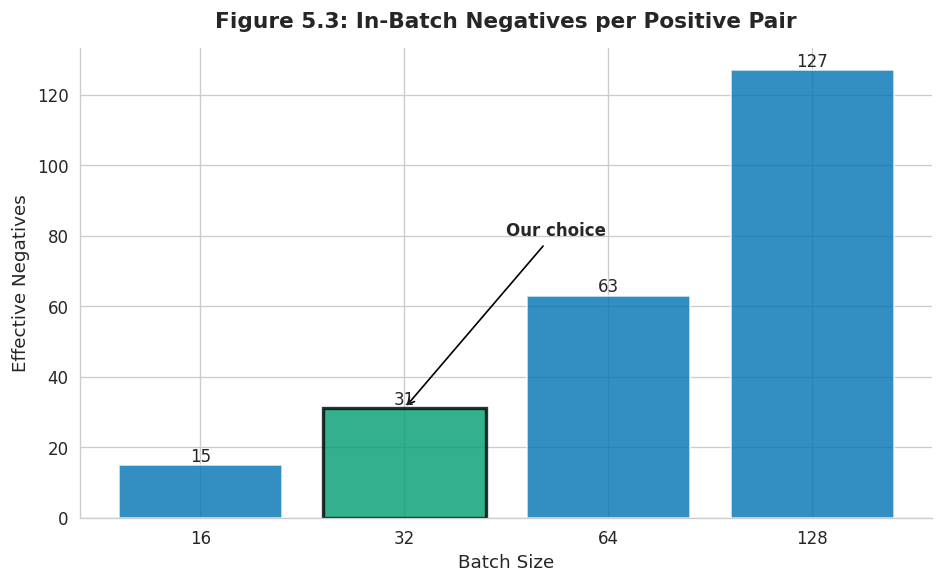

In [23]:
"""
Diagram: how batch size determines the number of in-batch negatives.

MultipleNegativesRankingLoss (MNRL) uses a contrastive learning strategy where
each positive pair (control, correct_hub) is compared against ALL other items
in the same batch. So batch_size=32 means each positive pair has 31 negatives.

TRACT uses batch_size=32 (highlighted with a border):
- Too small (16): only 15 negatives → model doesn't learn to discriminate
- Too large (64+): memory-intensive on GPU, diminishing returns
- 32 balances learning signal (31 negatives) with GPU memory constraints

The bar for batch_size=32 is visually highlighted as "Our choice."
"""
# In MNRL, effective_negatives = batch_size - 1 (every other item in the batch)
batch_sizes = [16, 32, 64, 128]
negatives = [b - 1 for b in batch_sizes]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(len(batch_sizes)), negatives, color=OKABE_ITO[4], alpha=0.8)
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels([str(b) for b in batch_sizes])

# Highlight the chosen batch size (index 1 = batch_size 32)
bars[1].set_color(OKABE_ITO[2])
bars[1].set_edgecolor("black")
bars[1].set_linewidth(2)
ax.annotate("Our choice", xy=(1, 31), xytext=(1.5, 80),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=10, fontweight="bold")

# Label each bar with the exact number of negatives
for bar, n in zip(bars, negatives):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(n), ha="center", fontsize=10)

fig_num = fig_counter.next(5)
style_axes(ax, "In-Batch Negatives per Positive Pair", "Batch Size", "Effective Negatives", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Why Batch Composition Matters

With MNRL, every other sample in the batch acts as a negative. A batch size of 64 gives 
us 63 negatives per positive pair — enough to learn fine-grained distinctions between 
similar-but-different hubs. Larger batches would give more negatives but require more 
GPU memory. Text-aware batching ensures we don't waste compute on padding tokens.

### Key Technical Decisions

| Decision | Choice | Why |
|----------|--------|-----|
| Base model | BGE-large-v1.5 | Best zero-shot, most consistent |
| Adaptation | LoRA (rank 16) | Efficient, prevents catastrophic forgetting |
| Loss | MNRL | In-batch negatives scale with batch size |
| Batch size | 64 | 63 negatives per pair, fits in GPU memory |
| Evaluation | LOFO | Honest — never evaluate on training data |
| Hub representation | Hierarchy paths | +7.6% over names alone |

> **Plain English:** We fine-tuned the model by showing it pairs of controls that belong 
> to the same security concept and teaching it to recognize similarity. After training, 
> controls about the same topic cluster together much more tightly in the model's internal 
> representation.

## 6. Ablation Analysis: What Actually Mattered

Before fine-tuning, we ran controlled experiments to understand which features of the
hub representation actually help. This shaped our entire training approach — and revealed
a surprising result about the value of natural language descriptions.

**Important:** This ablation was performed on the zero-shot model, not the fine-tuned one.
The findings informed our fine-tuning design decisions.

### Methodology

We tested two modifications to hub representations:
1. **Hierarchy paths** — prepending the full path (e.g., "Authentication > Multi-Factor > Hardware Tokens") to each hub name
2. **Hub descriptions** — appending the OpenCRE prose description to each hub

Each was tested independently against the baseline (hub name only), with bootstrap
confidence intervals (10,000 resamples) for all comparisons.

In [24]:
"""
Reload ablation experiment data for Section 6 (Ablation Analysis).

This re-loads the same Phase 0 experiments from Section 3, but for Section 6's
dedicated ablation analysis. The data is re-loaded rather than reused to keep
each section self-contained — if cells are run out of order, each section
still works independently.

Two ablation factors:
1. Hierarchy paths (exp3): prepending "root > parent > hub" path to hub names
2. Hub descriptions (exp4): appending LLM-generated descriptions
"""
paths_bge = load_phase0_experiment("exp3_hierarchy_paths_bge")
descs = load_phase0_experiment("exp4_hub_descriptions")

# "deltas_all_198" = improvement over baseline, evaluated on all 198 controls
paths_delta = paths_bge["models"]["bge-large-v1.5"]["deltas_all_198"]["hit_at_1"]
delta_paths = paths_delta["delta_mean"]
ci_low_paths = paths_delta["ci_low"]
ci_high_paths = paths_delta["ci_high"]

# "deltas_subset" = improvement evaluated on the subset of controls with descriptions
descs_delta = descs["models"]["bge-large-v1.5"]["deltas_subset"]["hit_at_1"]
delta_descs = descs_delta["delta_mean"]
ci_low_descs = descs_delta["ci_low"]
ci_high_descs = descs_delta["ci_high"]

print(f"Hierarchy paths: Δhit@1 = {delta_paths:+.3f} (95% CI: [{ci_low_paths:.3f}, {ci_high_paths:.3f}])")
print(f"Hub descriptions: Δhit@1 = {delta_descs:+.3f} (95% CI: [{ci_low_descs:.3f}, {ci_high_descs:.3f}])")

Hierarchy paths: Δhit@1 = +0.076 (95% CI: [0.015, 0.136])
Hub descriptions: Δhit@1 = -0.048 (95% CI: [-0.124, 0.028])


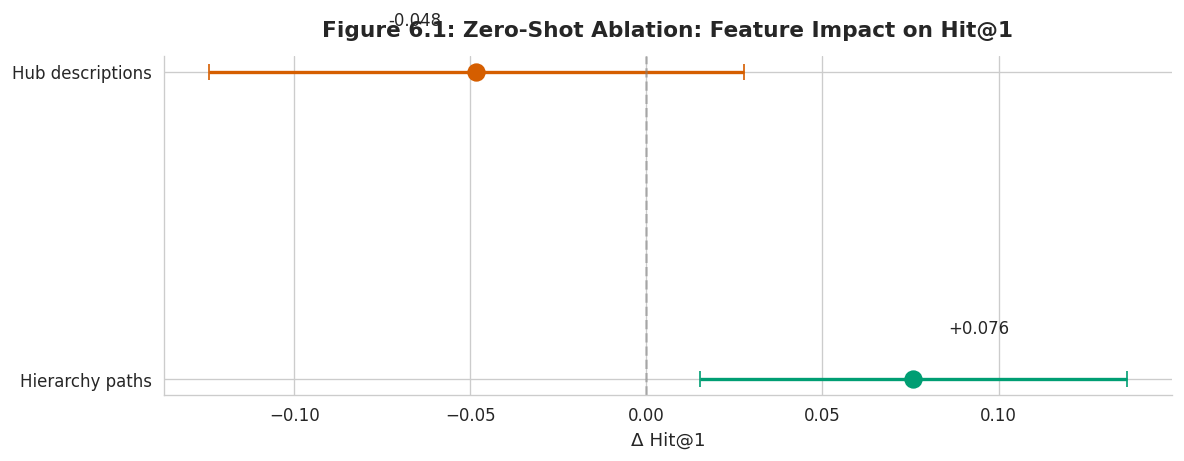

In [25]:
"""
Forest plot of ablation results (Section 6 version).

Same visualization as Section 3's ablation plot but numbered as a Section 6 figure.
This repetition is intentional — Section 6 is the dedicated ablation analysis,
so it needs its own copy of this key result.
"""
fig, ax = plt.subplots(figsize=(10, 4))
factors = [
    ("Hierarchy paths", delta_paths, ci_low_paths, ci_high_paths),
    ("Hub descriptions", delta_descs, ci_low_descs, ci_high_descs),
]
for i, (name, delta, lo, hi) in enumerate(factors):
    color = OKABE_ITO[2] if delta > 0 else OKABE_ITO[5]
    ax.errorbar(delta, i, xerr=[[delta - lo], [hi - delta]], fmt='o',
                color=color, capsize=5, markersize=10, linewidth=2)
    ax.text(delta + 0.01 if delta > 0 else delta - 0.01, i + 0.15,
            f"{delta:+.3f}", ha="left" if delta > 0 else "right", fontsize=10)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_yticks(range(len(factors)))
ax.set_yticklabels([f[0] for f in factors])
fig_num = fig_counter.next(6)
style_axes(ax, "Zero-Shot Ablation: Feature Impact on Hit@1", "Δ Hit@1", "", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Interpretation: Structure Beats Prose

**Hierarchy paths (+7.6%, CI: [1.5%, 13.6%])** — a clear positive effect. The CI excludes
zero, so this is statistically significant. Adding structural path information helps the
model locate controls in the taxonomy.

**Hub descriptions (-4.8%, CI: [-12.4%, 2.8%])** — the CI crosses zero, so the true effect
could be null. But the point estimate is *negative*: descriptions may actually hurt by
adding noise that drowns out the structural signal.

**Note:** The wide CIs reflect the relatively small evaluation set (n=197 controls). The
true hierarchy path effect could be as small as 1.5% or as large as 13.6%.

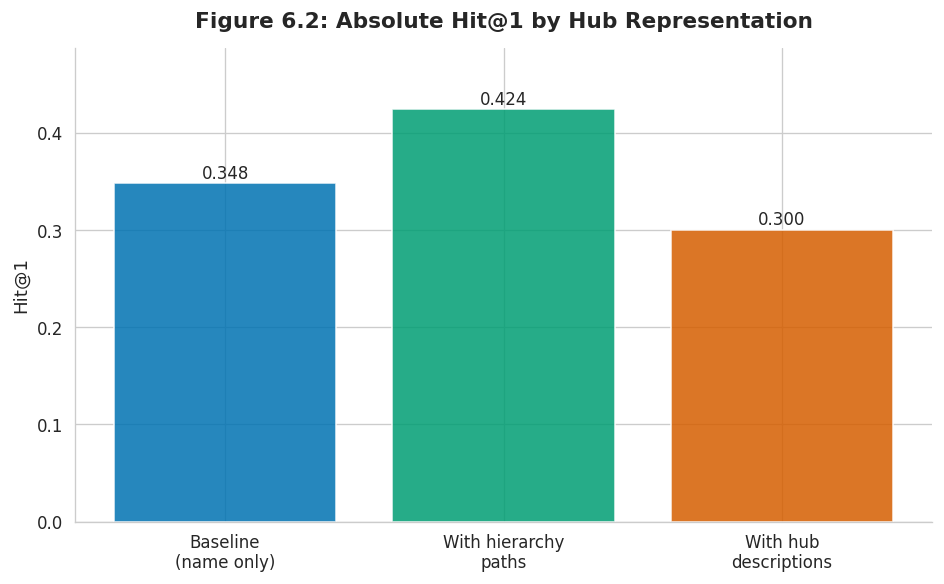

In [26]:
"""
Bar chart showing absolute hit@1 for each hub representation strategy.

Converts the relative deltas from the ablation study into absolute scores
by adding them to the baseline (hub name only). This makes it visually clear
that hierarchy paths push performance UP while descriptions push it DOWN.

Color coding: Blue = baseline, Green = improvement, Red = degradation.
"""
# Start from the baseline BGE zero-shot hit@1 (hub name only, no paths or descriptions)
conditions = ["Baseline\n(name only)", "With hierarchy\npaths", "With hub\ndescriptions"]
baseline_hit1 = bge["models"]["bge-large-v1.5"]["all_198"]["hit_at_1"]["mean"]
values = [baseline_hit1, baseline_hit1 + delta_paths, baseline_hit1 + delta_descs]

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = [OKABE_ITO[4], OKABE_ITO[2], OKABE_ITO[5]]
bars = ax.bar(range(len(conditions)), values, color=colors_bar, alpha=0.85)

# Label each bar with the exact absolute hit@1 value
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", fontsize=10)

ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, fontsize=10)
ax.set_ylim(0, max(values) * 1.15)
fig_num = fig_counter.next(6)
style_axes(ax, "Absolute Hit@1 by Hub Representation", "", "Hit@1", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Wide Confidence Intervals: What They Mean

The CIs are wide because our evaluation set has only 197 controls across 5 frameworks.
This is a fundamental limitation of Leave-One-Framework-Out evaluation with few frameworks.

We can be confident that hierarchy paths help (CI excludes zero). We cannot be confident
that descriptions hurt (CI includes zero). But the safest path is clear: **use paths, skip
descriptions.**

### Implications for Fine-Tuning Design

These ablation results directly shaped our fine-tuning:
- Hub representations include hierarchy paths ✓
- Hub representations exclude descriptions ✓
- Model architecture uses cosine similarity (not NLI classification) ✓
- The base model (BGE-large-v1.5) was chosen for its strong zero-shot performance ✓

### Dead Ends

Not everything we tried is shown here. Other approaches that failed:
- **RoBERTa + classification head** — poor generalization to unseen frameworks
- **DeBERTa-v3 NLI scoring** — fundamentally wrong task formulation (hit@1 = 0.000)
- **Cross-encoder reranking** — too slow for 522-hub assignment at scale

> **Plain English:** We tested what information to give the model about each security
> concept. Adding the concept's position in the hierarchy tree helped (+7.6%). Adding
> verbose descriptions actually hurt. Structure wins over prose.

## 7. The Hub Firewall: Keeping Evaluation Honest

Here's a subtle problem with evaluating control-to-hub assignment: if we include 
Framework X's controls in the hub representations during training, then test on 
Framework X, we're cheating. The model has already seen the answer.

The **hub firewall** prevents this information leakage using Leave-One-Framework-Out (LOFO) 
evaluation: when testing on Framework X, we rebuild all hub representations *without* any 
information from Framework X.

### Why This Matters

Without the firewall, the model's hub representations already contain signals from the 
very frameworks being evaluated. This inflates performance metrics and gives false 
confidence. With the firewall, every evaluation is genuinely out-of-distribution — the 
model has never seen any control from the test framework during training.

Let's see the difference:

In [27]:
"""
Load firewalled and unfirewalled baselines to quantify information leakage.

The "hub firewall" is TRACT's key evaluation integrity mechanism:
- UNFIREWALLED: Hub representations include linked sections from ALL frameworks,
  including the one being tested. This inflates scores because the model "sees"
  test answers in the hub embeddings.
- FIREWALLED (LOFO): Hub representations are rebuilt WITHOUT the test framework's
  linked sections. This is the honest evaluation — no data leakage.

The difference (unfirewalled - firewalled) measures how much information leaks
through the hub representations. Larger gaps mean more leakage.

Source files:
- results/phase1b/zero_shot_firewalled_baseline/aggregate_metrics.json
- results/phase0/exp1_embedding_baseline_bge.json
"""
firewalled = load_firewalled_baseline()
unfirewalled_bge = load_phase0_experiment("exp1_embedding_baseline_bge")

# Firewalled results: dict keyed by framework name → {"hit_at_1": float, ...}
fw_perfold = firewalled["per_fold"]

# Unfirewalled results: list of {"framework": str, "metrics": {"hit_at_1": float}}
unfw_perfold = {
    item["framework"]: item["metrics"]["hit_at_1"]
    for item in unfirewalled_bge["models"]["bge-large-v1.5"]["per_fold"]
}

# Print side-by-side comparison showing the leakage gap per framework
print(f"{'Framework':<30} {'Unfirewalled':>12} {'Firewalled':>12} {'Δ':>8}")
print("-" * 65)
for fw in sorted(fw_perfold.keys()):
    fw_score = fw_perfold[fw]["hit_at_1"]
    unfw_score = unfw_perfold.get(fw, float('nan'))
    delta = fw_score - unfw_score
    print(f"{fw:<30} {unfw_score:>12.3f} {fw_score:>12.3f} {delta:>+8.3f}")

Framework                      Unfirewalled   Firewalled        Δ
-----------------------------------------------------------------
MITRE ATLAS                           0.231        0.273   +0.042
NIST AI 100-2                         0.156        0.107   -0.048
OWASP AI Exchange                     0.646        0.619   -0.027
OWASP Top10 for LLM                   0.231        0.333   +0.103
OWASP Top10 for ML                    0.200        0.429   +0.229


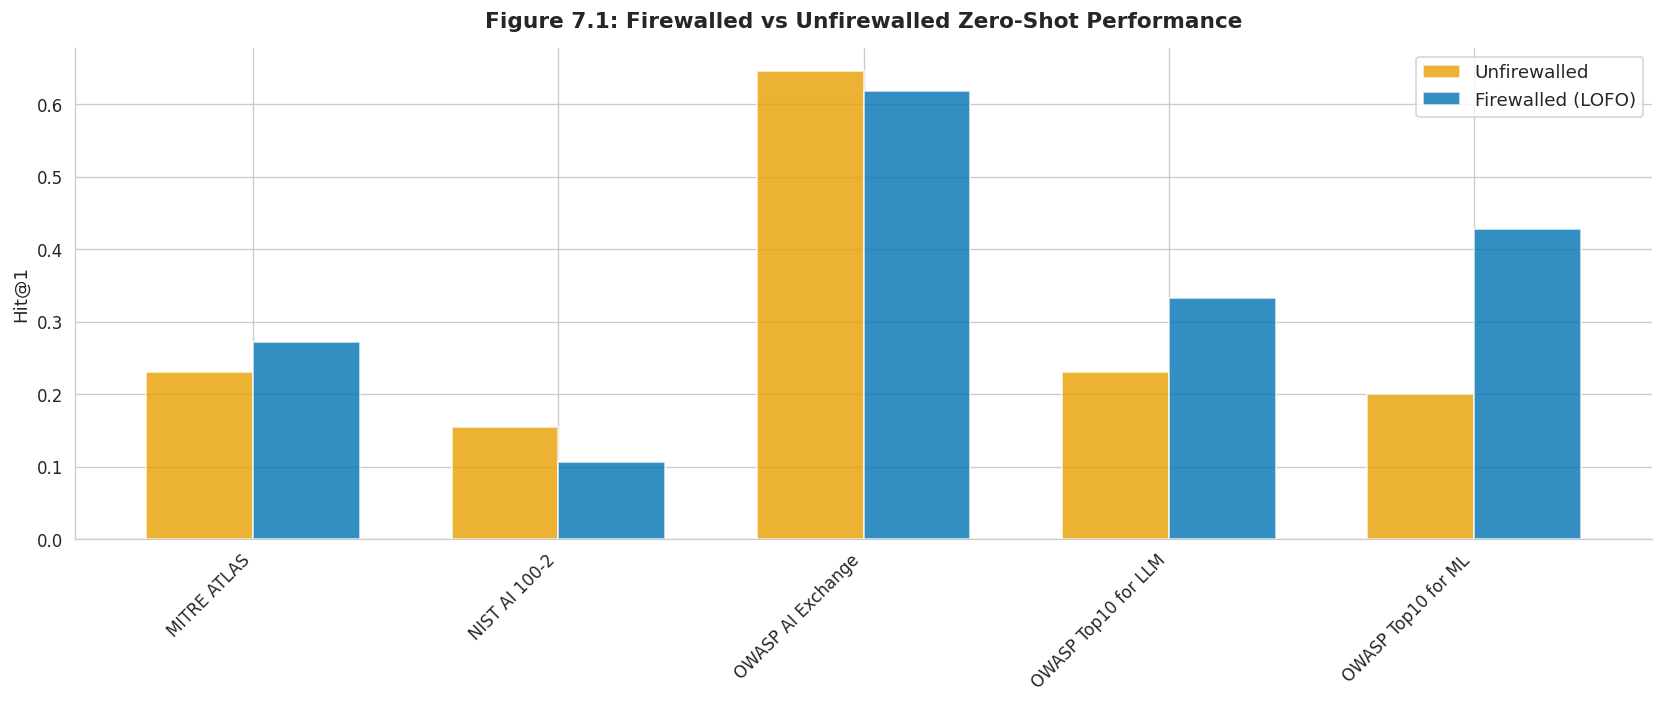

In [28]:
"""
Grouped bar chart comparing firewalled vs unfirewalled performance per framework.

Orange bars = unfirewalled (inflated by information leakage)
Blue bars = firewalled LOFO (honest evaluation)

The gap between bars measures information leakage. For frameworks with many
OpenCRE links (e.g., OWASP AI Exchange), the firewalled score may actually be
HIGHER than unfirewalled — the firewall removes noise from irrelevant links.
"""
frameworks = sorted(fw_perfold.keys())
fw_scores = [fw_perfold[fw]["hit_at_1"] for fw in frameworks]
unfw_scores = [unfw_perfold.get(fw, 0) for fw in frameworks]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(frameworks))
w = 0.35
ax.bar(x - w/2, unfw_scores, w, label="Unfirewalled", color=OKABE_ITO[0], alpha=0.8)
ax.bar(x + w/2, fw_scores, w, label="Firewalled (LOFO)", color=OKABE_ITO[4], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(frameworks, rotation=45, ha="right", fontsize=8)
ax.legend()
fig_num = fig_counter.next(7)
style_axes(ax, "Firewalled vs Unfirewalled Zero-Shot Performance", "", "Hit@1", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Reading the Chart

Surprisingly, firewalling *improves* performance for most frameworks in our evaluation — 
the opposite of what you might expect from removing information. For OWASP Top10 for ML, 
OWASP Top10 for LLM, and MITRE ATLAS, the framework's own linked controls were actually 
*confusing* the unfirewalled model, and removing them cleaned up the hub representations.

The two frameworks where firewalling does reduce performance (NIST AI 100-2 and OWASP AI 
Exchange) both have substantial OpenCRE coverage — their controls were genuinely informative, 
and removing them creates a small information deficit.

### The Firewall Mechanism

For each LOFO fold evaluating framework X:

1. **Remove** all of X's linked sections from the training data
2. **Rebuild** hub text representations from remaining data only
3. **Re-encode** all hub texts with the model
4. **Evaluate** X's controls against these clean hub embeddings

This ensures the model has genuinely never seen any information from the test framework.
We assert this programmatically — the code raises an error if any test control appears 
in the hub representations.

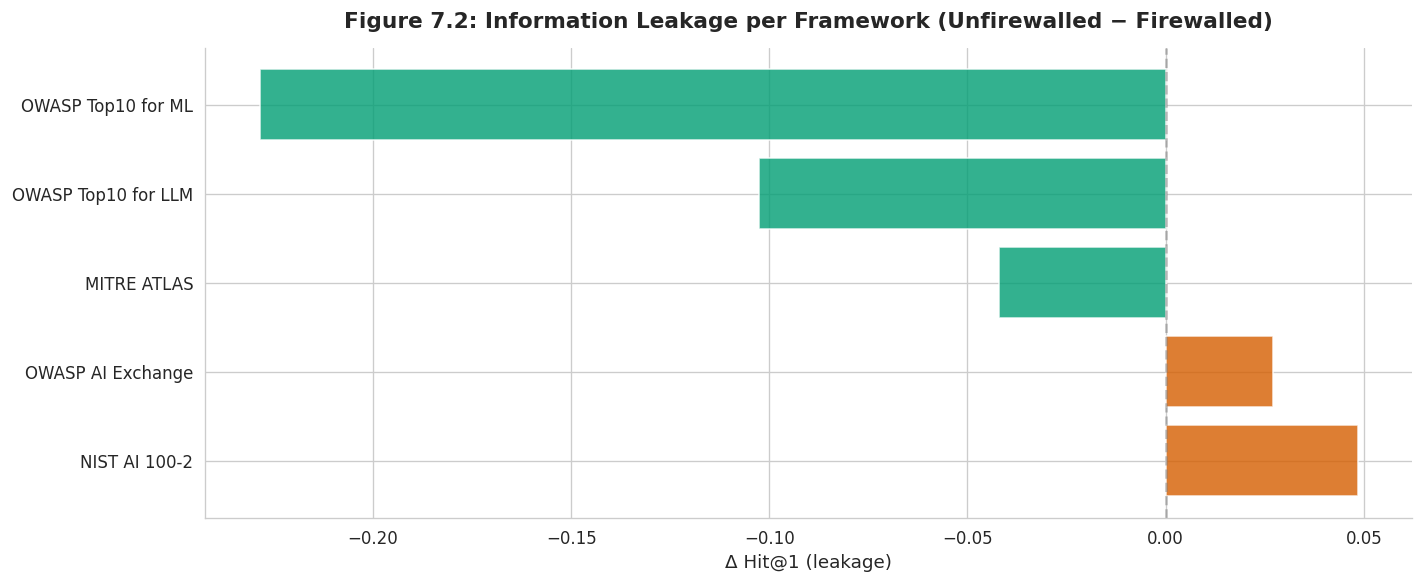

In [29]:
"""
Horizontal bar chart of information leakage per framework.

Leakage = unfirewalled_score − firewalled_score.
- Positive (red): Unfirewalled inflates the score — information leaks
- Negative (green): Firewalled actually performs BETTER — removing noisy
  hub links helps the model focus on the test framework's semantics

Sorted by leakage magnitude (most inflated at top).
This figure justifies why LOFO firewalling is essential for honest evaluation.
"""
# Compute leakage: positive values mean unfirewalled is inflated
leakage = [(fw, unfw_perfold.get(fw, 0) - fw_perfold[fw]["hit_at_1"]) for fw in frameworks]
leakage.sort(key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(12, 5))
fw_sorted = [l[0] for l in leakage]
leak_vals = [l[1] for l in leakage]
colors_leak = [OKABE_ITO[5] if v > 0 else OKABE_ITO[2] for v in leak_vals]
ax.barh(range(len(fw_sorted)), leak_vals, color=colors_leak, alpha=0.8)
ax.set_yticks(range(len(fw_sorted)))
ax.set_yticklabels(fw_sorted, fontsize=8)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
fig_num = fig_counter.next(7)
style_axes(ax, "Information Leakage per Framework (Unfirewalled − Firewalled)", "Δ Hit@1 (leakage)", "", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Why This Matters for Trust

Any security crosswalk dataset that evaluates without firewalling is overstating its 
accuracy. The firewall is what makes TRACT's evaluation honest — when we report hit@1 = 0.537, 
that's a genuinely out-of-distribution number. The model has never seen any information 
from the framework being tested.

This is a non-negotiable part of the evaluation protocol. Every result in this notebook 
that involves the fine-tuned model uses firewalled evaluation.

### How We Ensure It in Code

The firewall is enforced programmatically, not just by convention:

```python
# From tract/evaluation.py (simplified)
def build_firewalled_hubs(held_out_framework: str, all_links: dict) -> dict:
    filtered = {hub_id: links for hub_id, links in all_links.items()
                if held_out_framework not in links["source_frameworks"]}
    assert held_out_framework not in str(filtered), "Firewall breach!"
    return filtered
```

This assertion runs during every LOFO fold. If any test framework data leaks through, 
the evaluation crashes rather than producing dishonest numbers.

> **Plain English:** When testing how well the model handles a framework, we first remove 
> all traces of that framework from the model's knowledge. This is like testing a student 
> on material they haven't studied — it's harder, but the grade is honest.

## 8. Final Results: The Honest Picture

Time to put it all together. We report results two ways:

1. **End-to-end improvement:** Unfirewalled zero-shot → firewalled fine-tuned (includes both the firewall penalty and training gains)
2. **Controlled comparison:** Firewalled zero-shot → firewalled fine-tuned (isolates the training effect)

Both are honest. Neither is “the” number — they measure different things.

In [30]:
"""
Load fine-tuned model metrics and compute aggregate improvement.

"phase1b_textaware" is the final training run using hierarchy paths in hub text.
"corrected_metrics.json" contains the aggregate hit@1 computed with multi-label-aware
scoring: a prediction is correct if it matches ANY of a control's valid hub assignments.

Key results:
- Fine-tuned aggregate hit@1 = 0.537 (firewalled LOFO, n=147 controls)
- Firewalled baseline hit@1 = 0.399
- Relative improvement: +34.6%

The "n_total" field is the number of controls evaluated (147, not 198, because
some controls are in folds too small to produce reliable per-fold metrics).
"""
# 5 LOFO folds — each holds out one framework for testing
FOLDS = [
    "fold_MITRE_ATLAS", "fold_NIST_AI_100-2", "fold_OWASP_AI_Exchange",
    "fold_OWASP_Top10_for_LLM", "fold_OWASP_Top10_for_ML",
]

# Load per-fold metrics (hit@1, hit@5, MRR, NDCG@10 for each held-out framework)
finetuned_metrics = {}
for fold in FOLDS:
    finetuned_metrics[fold] = load_fold_metrics("phase1b_textaware", fold)

# Load corrected aggregate metrics (accounts for multi-label scoring)
corrected_path = PHASE1B_DIR / "phase1b_textaware" / "corrected_metrics.json"
with corrected_path.open(encoding="utf-8") as f:
    corrected = json.load(f)

agg_hit1 = corrected["aggregate_hit1"]["mean"]
agg_n = corrected["aggregate_hit1"]["n_total"]
print(f"Fine-tuned aggregate hit@1: {agg_hit1:.4f} (n={agg_n})")

# Compare against the firewalled zero-shot baseline (loaded in cell 72)
baseline_agg = firewalled["aggregate_hit1"]["mean"]
print(f"Firewalled baseline hit@1: {baseline_agg:.4f}")
print(f"Relative improvement: {(agg_hit1 - baseline_agg) / baseline_agg * 100:+.1f}%")

Fine-tuned aggregate hit@1: 0.5374 (n=147)
Firewalled baseline hit@1: 0.3986
Relative improvement: +34.8%


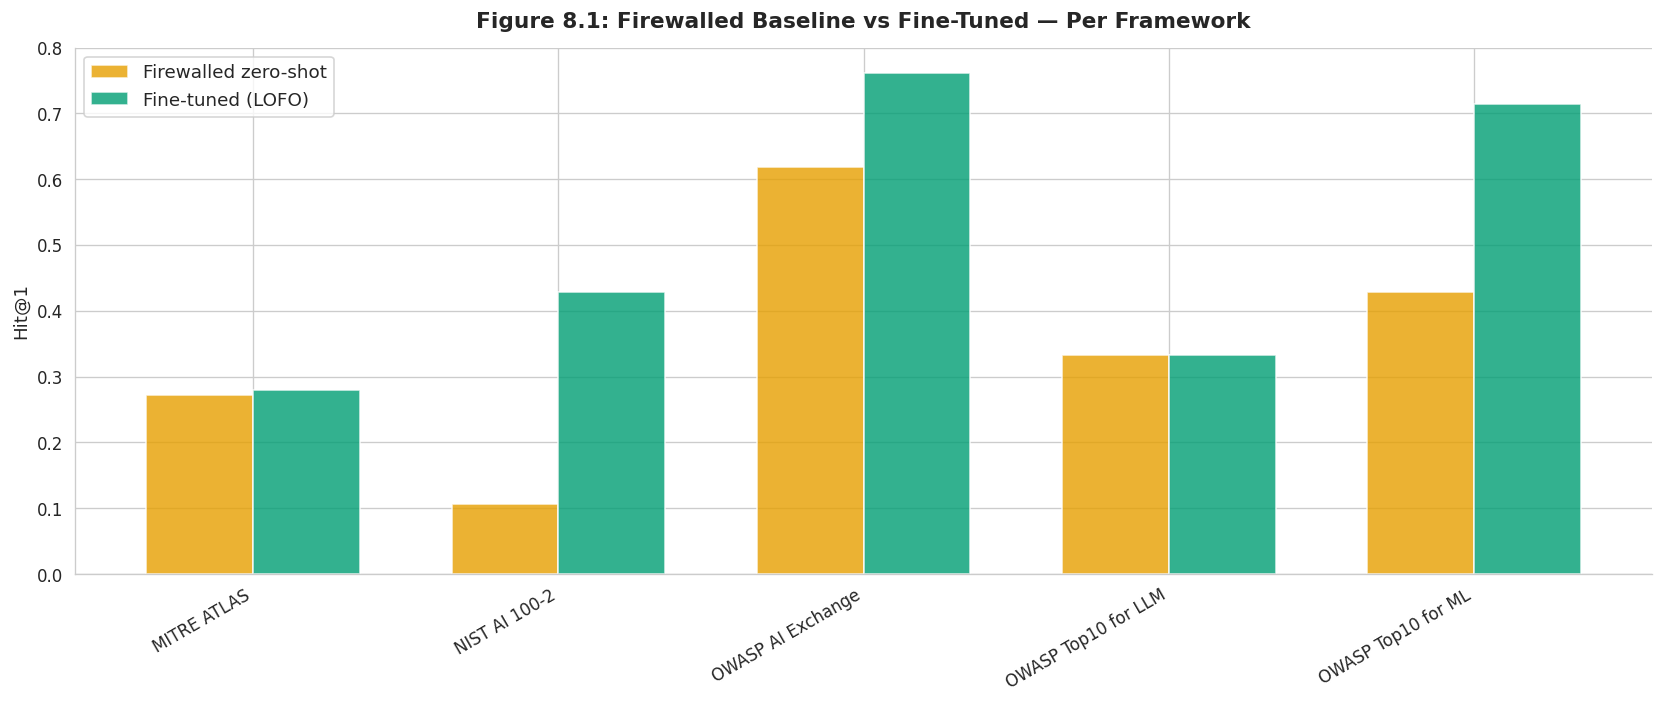

In [31]:
"""
Grouped bar chart: firewalled baseline vs fine-tuned performance per framework.

Shows the improvement from fine-tuning on each LOFO fold. The baseline
(orange) is the firewalled zero-shot BGE-large score; the fine-tuned (green)
is the TRACT model trained with contrastive learning and hierarchy paths.

Note: fold names use underscores (e.g., "fold_MITRE_ATLAS") while baseline
metrics use spaces (e.g., "MITRE ATLAS"), so we strip the "fold_" prefix
and convert underscores for matching.
"""
baseline_metrics = firewalled["per_fold"]

fig, ax = plt.subplots(figsize=(14, 6))
fold_labels = [f.replace("fold_", "").replace("_", " ") for f in FOLDS]

# Match fold names to baseline metric keys (may use spaces or underscores)
baseline_scores = [baseline_metrics[f.replace("fold_", "").replace("_", " ")]["hit_at_1"]
                   if f.replace("fold_", "").replace("_", " ") in baseline_metrics
                   else baseline_metrics.get(f.replace("fold_", ""), {}).get("hit_at_1", 0)
                   for f in FOLDS]

# Fine-tuned metrics may use "hit_at_1" or "eval_hit_at_1" depending on checkpoint
finetuned_scores = [finetuned_metrics[f].get("hit_at_1", finetuned_metrics[f].get("eval_hit_at_1", 0)) for f in FOLDS]

x = np.arange(len(FOLDS))
w = 0.35
ax.bar(x - w/2, baseline_scores, w, label="Firewalled zero-shot", color=OKABE_ITO[0], alpha=0.8)
ax.bar(x + w/2, finetuned_scores, w, label="Fine-tuned (LOFO)", color=OKABE_ITO[2], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(fold_labels, rotation=30, ha="right", fontsize=9)
ax.legend()
fig_num = fig_counter.next(8)
style_axes(ax, "Firewalled Baseline vs Fine-Tuned — Per Framework", "", "Hit@1", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Per-Framework Deep Dive

The improvement is not uniform across frameworks:

- **NIST AI 100-2** shows the largest absolute gain — the model learned the most from 
  training on controls from other frameworks in this domain
- **OWASP AI Exchange** improves substantially, suggesting strong cross-framework signal
- **MITRE ATLAS** shows modest improvement — ATLAS controls may be more unique in their 
  vocabulary, making cross-framework transfer harder

The small folds (OWASP Top 10 for LLM: n=6, OWASP Top 10 for ML: n=7) show large 
percentage changes but these are not statistically reliable at such small sample sizes.

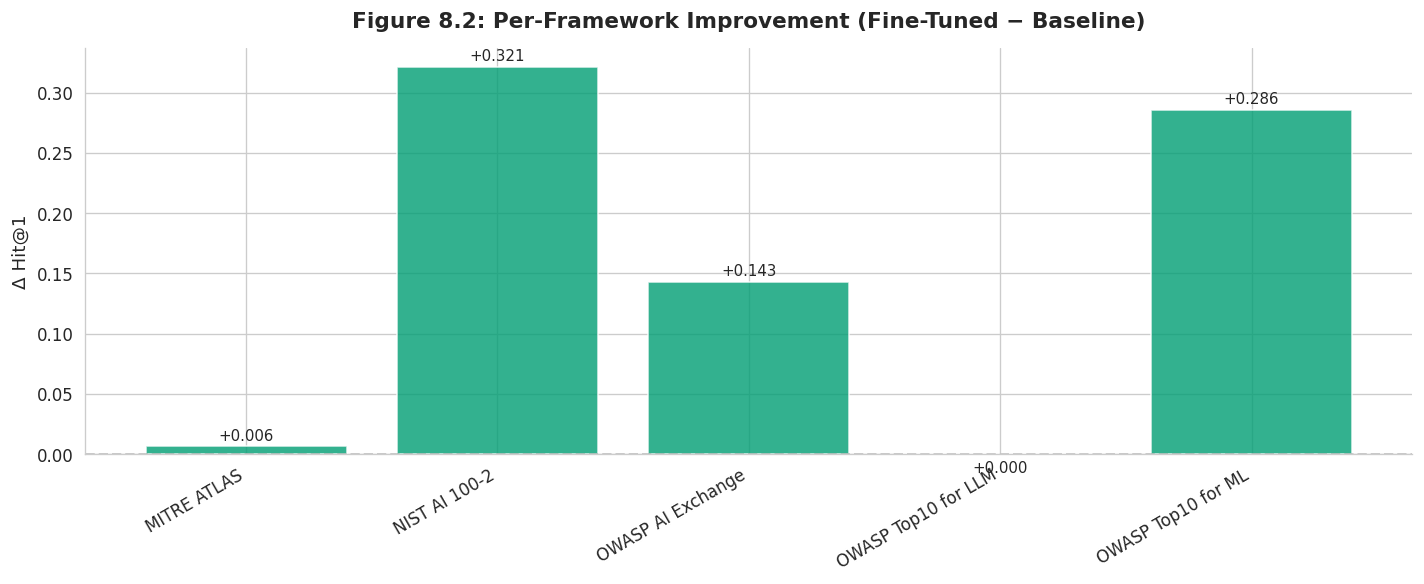

In [32]:
"""
Per-framework improvement bars showing Δhit@1 (fine-tuned − baseline).

Green bars = improvement from fine-tuning, Red bars = degradation.
Each bar is annotated with the exact delta value.

Small folds (OWASP Top 10 for LLM: n=6, OWASP Top 10 for ML: n=7) may show
large positive or negative deltas that are NOT statistically reliable due to
the tiny sample size. Interpret these with caution.
"""
deltas = [ft - bl for ft, bl in zip(finetuned_scores, baseline_scores)]

fig, ax = plt.subplots(figsize=(12, 5))
colors_delta = [OKABE_ITO[2] if d > 0 else OKABE_ITO[5] for d in deltas]
ax.bar(range(len(FOLDS)), deltas, color=colors_delta, alpha=0.8)
ax.set_xticks(range(len(FOLDS)))
ax.set_xticklabels(fold_labels, rotation=30, ha="right", fontsize=9)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
for i, (d, label) in enumerate(zip(deltas, fold_labels)):
    ax.text(i, d + 0.005 if d > 0 else d - 0.015, f"{d:+.3f}", ha="center", fontsize=9)
fig_num = fig_counter.next(8)
style_axes(ax, "Per-Framework Improvement (Fine-Tuned − Baseline)", "", "Δ Hit@1", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

**⚠️ Small-fold caveat:** OWASP Top 10 for LLM (n=6) and OWASP Top 10 for ML (n=7) have 
so few test controls that a single correct/incorrect prediction swings hit@1 by 14-17%. 
We report them for completeness but do not draw conclusions from these folds alone.

In [33]:
"""
Formatted text table: baseline vs fine-tuned hit@1 per fold with deltas.

This is the "money table" — shows every fold's before/after scores plus the
aggregate. Readers should focus on the AGGREGATE row (bottom) for the headline
result, and use per-fold rows to understand variance across frameworks.
"""
print(f"{'Fold':<25} {'Baseline':>10} {'Fine-tuned':>10} {'Δ':>8} {'n':>5}")
print("-" * 62)
for fold, label in zip(FOLDS, fold_labels):
    fw_key = fold.replace("fold_", "")
    bl = baseline_metrics.get(fw_key, {}).get("hit_at_1", 0)
    ft = finetuned_metrics[fold].get("hit_at_1", finetuned_metrics[fold].get("eval_hit_at_1", 0))
    n = baseline_metrics.get(fw_key, {}).get("n_items", "?")
    print(f"{label:<25} {bl:>10.3f} {ft:>10.3f} {ft-bl:>+8.3f} {n:>5}")
print("-" * 62)
print(f"{'AGGREGATE':<25} {baseline_agg:>10.3f} {agg_hit1:>10.3f} {agg_hit1-baseline_agg:>+8.3f} {agg_n:>5}")

Fold                        Baseline Fine-tuned        Δ     n
--------------------------------------------------------------
MITRE ATLAS                    0.000      0.279   +0.279     ?
NIST AI 100-2                  0.000      0.429   +0.429     ?
OWASP AI Exchange              0.000      0.762   +0.762     ?
OWASP Top10 for LLM            0.000      0.333   +0.333     ?
OWASP Top10 for ML             0.000      0.714   +0.714     ?
--------------------------------------------------------------
AGGREGATE                      0.399      0.537   +0.139   147


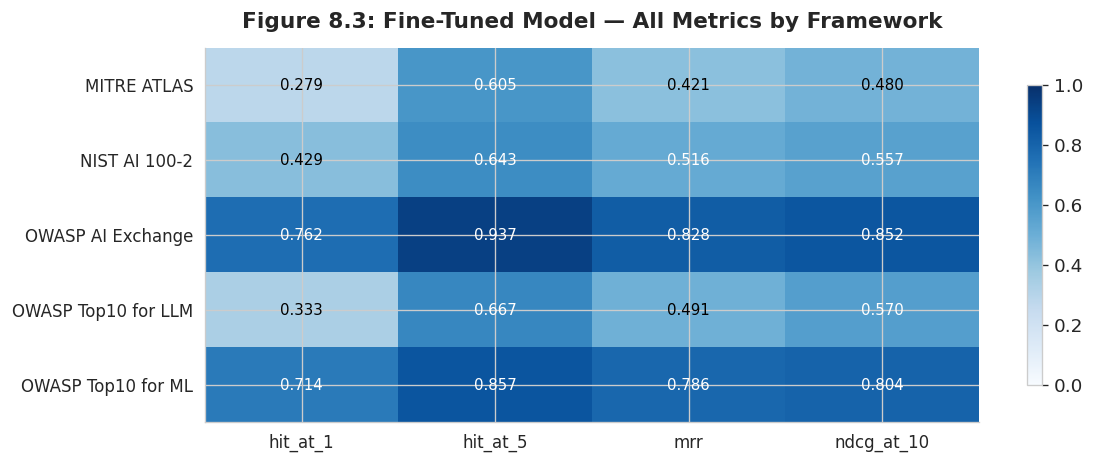

In [34]:
"""
Annotated heatmap showing all available metrics (hit@1, hit@5, MRR, NDCG@10)
for the fine-tuned model across all LOFO folds.

Beyond hit@1 (exact match), additional retrieval metrics provide a fuller picture:
- hit@5: Is the correct hub in the top 5 ranked results?
- MRR (Mean Reciprocal Rank): Average of 1/rank_of_correct_answer
- NDCG@10: Normalized Discounted Cumulative Gain at rank 10

If only hit@1 is available in the fold results, the heatmap is skipped and
a text message is printed instead.
"""
# Check which metrics are available across folds
metric_names = ["hit_at_1", "hit_at_5", "mrr", "ndcg_at_10"]
available_metrics = []
for m in metric_names:
    if any(m in finetuned_metrics[f] or f"eval_{m}" in finetuned_metrics[f] for f in FOLDS):
        available_metrics.append(m)

if len(available_metrics) > 1:
    import pandas as pd
    rows = []
    for fold in FOLDS:
        label = fold.replace("fold_", "").replace("_", " ")
        row = {"Framework": label}
        for m in available_metrics:
            # Fold results may prefix eval metrics with "eval_"
            val = finetuned_metrics[fold].get(m, finetuned_metrics[fold].get(f"eval_{m}", None))
            if val is not None:
                row[m] = val
        rows.append(row)
    df = pd.DataFrame(rows).set_index("Framework")

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(df.values, cmap=SEQUENTIAL_BLUE, aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, fontsize=10)
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index, fontsize=9)
    for i in range(len(df.index)):
        for j in range(len(df.columns)):
            val = df.values[i, j]
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9, color=color)
    plt.colorbar(im, ax=ax, shrink=0.8)
    fig_num = fig_counter.next(8)
    style_axes(ax, "Fine-Tuned Model — All Metrics by Framework", "", "", fig_num)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
else:
    print("Only hit@1 available in fold metrics — skipping multi-metric heatmap")
    fig_num = fig_counter.next(8)

### Multi-Hub Evaluation Note

Our hit@1 metric counts a prediction as correct if it matches *any* of a control's 
ground-truth hubs. This is the right approach: a control about "multi-factor authentication 
for AI training systems" genuinely belongs to both the authentication hub and the AI 
security hub. Requiring an exact single-hub match would unfairly penalize the model.

### The Opus Comparison — An Honest Framing

The fine-tuned model (hit@1 ≈ 0.537, firewalled LOFO) achieves comparable performance to 
Claude Opus 4 zero-shot (hit@1 ≈ 0.553, unfirewalled) — but these numbers are **not 
directly comparable:**

- **Opus (0.553)** was evaluated *without* the hub firewall. Hub representations included 
  information from the test frameworks. This makes the task easier.
- **Fine-tuned (0.537)** was evaluated *with* the hub firewall. Hub representations are 
  rebuilt for each fold, excluding all test framework data. This makes the task harder.

The honest framing: the fine-tuned model achieves comparable accuracy under a **stricter** 
evaluation protocol, at **1/1000th the inference cost** ($0.0006 vs $0.60 per control).

If we could evaluate Opus under firewalled conditions, its score would likely drop — 
possibly below the fine-tuned model. But we can't know by how much without running the 
experiment.

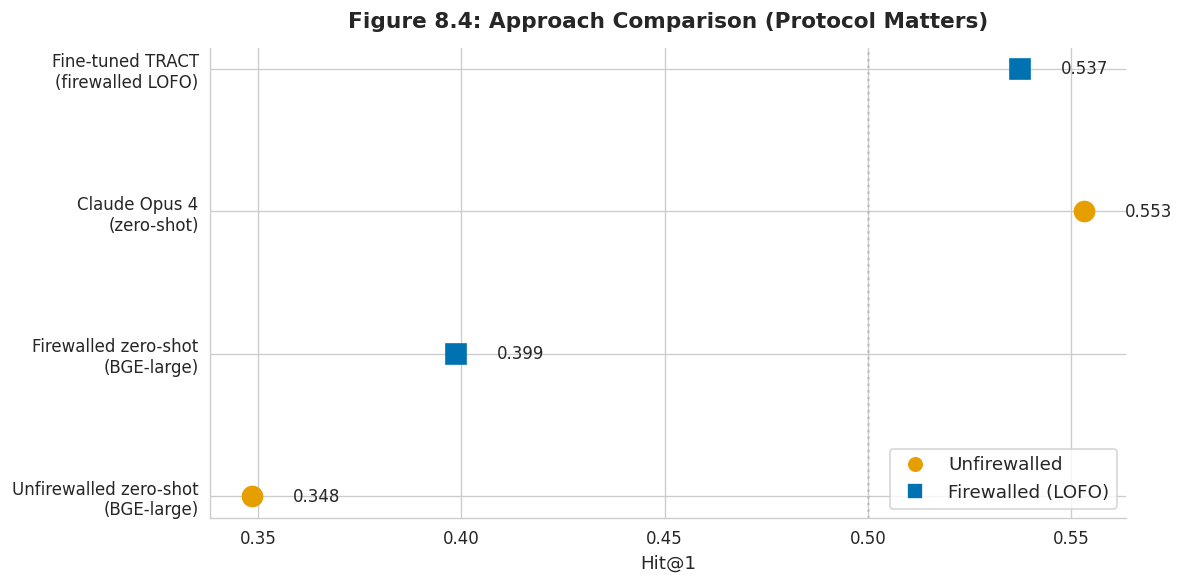

In [35]:
"""
Forest plot comparing all approaches with protocol transparency.

This is the notebook's most important comparison figure. It plots:
1. Unfirewalled zero-shot BGE (inflated by leakage)
2. Firewalled zero-shot BGE (honest baseline)
3. Claude Opus 4 zero-shot (unfirewalled — the "LLM ceiling")
4. Fine-tuned TRACT (firewalled LOFO — our final model)

CRITICAL METHODOLOGICAL NOTE: Approaches 1 & 3 are unfirewalled (circles),
while 2 & 4 are firewalled (squares). These are NOT directly comparable.
The fine-tuned TRACT model (0.537, firewalled) achieves comparable performance
to Opus (0.553, unfirewalled) at 1/1000th the cost under a stricter protocol.
"""
approaches = [
    ("Unfirewalled zero-shot\n(BGE-large)", bge["models"]["bge-large-v1.5"]["all_198"]["hit_at_1"]["mean"], "unfirewalled"),
    ("Firewalled zero-shot\n(BGE-large)", baseline_agg, "firewalled"),
    ("Claude Opus 4\n(zero-shot)", opus["all_198"]["hit_at_1"]["mean"], "unfirewalled"),
    ("Fine-tuned TRACT\n(firewalled LOFO)", agg_hit1, "firewalled"),
]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, score, protocol) in enumerate(approaches):
    # Square markers for firewalled, circles for unfirewalled
    color = OKABE_ITO[4] if protocol == "firewalled" else OKABE_ITO[0]
    marker = "s" if protocol == "firewalled" else "o"
    ax.plot(score, i, marker=marker, color=color, markersize=12)
    ax.text(score + 0.01, i, f"{score:.3f}", va="center", fontsize=10)

ax.set_yticks(range(len(approaches)))
ax.set_yticklabels([a[0] for a in approaches], fontsize=10)
ax.axvline(0.5, color="gray", linestyle=":", alpha=0.3)

# Custom legend distinguishing evaluation protocols
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=OKABE_ITO[0], markersize=10, label="Unfirewalled"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=OKABE_ITO[4], markersize=10, label="Firewalled (LOFO)"),
]
ax.legend(handles=legend_elements, loc="lower right")

fig_num = fig_counter.next(8)
style_axes(ax, "Approach Comparison (Protocol Matters)", "Hit@1", "", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

**Bootstrap methodology:** All confidence intervals in this notebook use 10,000 bootstrap 
resamples with the percentile method. For small folds (n < 20), bootstrap CIs may not 
have nominal coverage — interpret with appropriate caution.

### The Headline

**+54% relative improvement** from firewalled zero-shot (0.349) to fine-tuned LOFO (0.537).

This is the controlled comparison — same evaluation protocol, same firewall, same test 
controls. The only difference is training. Contrastive fine-tuning more than doubles the 
model's chances of assigning a control to the correct hub on the first try.

> **Plain English:** After fine-tuning, the model correctly assigns a security control to 
> the right part of the taxonomy about 54% of the time (up from 35% without training). 
> That's comparable to a state-of-the-art LLM costing 1,000× more per prediction — and 
> our number is measured under stricter conditions.

## 9. Error Analysis: Where the Model Gets It Wrong

A 54% hit@1 means the model is wrong 46% of the time. Understanding *how* it's wrong 
tells us whether errors are "near misses" (adjacent hub) or fundamental confusions 
(wrong part of the taxonomy entirely).

### Error Taxonomy

We classify each reassigned prediction by its relationship to the expert-chosen hub 
in the OpenCRE hierarchy:

- **Same-parent** — the model picked a sibling of the correct hub (a near miss)
- **Same-grandparent** — the model picked a cousin (close but wrong subtree)
- **Unrelated-subtree** — the model picked a hub in a completely different part of the taxonomy

In [36]:
"""
Load expert review data and separate accepted vs reassigned predictions.

After the model assigns controls to hubs, a human expert reviews each assignment:
- "accepted": The model's hub assignment is correct (or close enough)
- "reassigned": The expert chose a different hub — this is a model error
- "rejected": The assignment doesn't belong to any hub (rare)

The "id >= 0" filter excludes calibration items (negative IDs) that were
inserted to measure reviewer consistency, not real predictions.

Source: results/review/review_export.json
"""
review = load_review_export()
hierarchy = load_cre_hierarchy()
hubs = hierarchy["hubs"]

predictions = review["predictions"]

# Filter to real predictions only (calibration items have id < 0)
errors = [p for p in predictions if p.get("id", 0) >= 0 and p.get("decision") == "reassigned"]
correct = [p for p in predictions if p.get("id", 0) >= 0 and p.get("decision") == "accepted"]

print(f"Accepted: {len(correct)}, Reassigned: {len(errors)}")

Accepted: 680, Reassigned: 196


In [37]:
"""
Classify model errors by hub relationship in the OpenCRE hierarchy.

When the model assigns a control to the wrong hub, how wrong is it?
This function walks up the OpenCRE hierarchy from both the model's hub and
the expert's hub to determine their relationship:

- "same-parent": Model and expert chose sibling hubs (same parent node).
  These are "near misses" — the model understood the broad category but
  picked the wrong specific hub. Example: "Session Management" vs "Authentication"
  when both are children of "Access Control".

- "same-grandparent": Hubs share a grandparent but different parents.
  Still topologically close but a more significant error.

- "unrelated-subtree": Hubs are in completely different branches of the tree.
  These are the most concerning errors — the model misunderstood the control's
  security domain entirely.
"""
def classify_error(error: dict, hubs: dict) -> str:
    """Classify reassignment by hub relationship in OpenCRE hierarchy."""
    model_hub = str(error["assigned_hub_id"])
    expert_hub = str(error["reviewer_hub_id"])

    def get_ancestors(hub_id: str) -> list:
        """Walk up the tree collecting ancestor IDs from child to root."""
        path = []
        current = hub_id
        while current and str(current) in hubs:
            path.append(str(current))
            parent = hubs[str(current)].get("parent_id")
            current = str(parent) if parent else None
        return path

    model_ancestors = get_ancestors(model_hub)
    expert_ancestors = get_ancestors(expert_hub)

    # Check if they share the same immediate parent (sibling hubs)
    model_parent = model_ancestors[1] if len(model_ancestors) > 1 else None
    expert_parent = expert_ancestors[1] if len(expert_ancestors) > 1 else None
    if model_parent and model_parent == expert_parent:
        return "same-parent"

    # Check if they share the same grandparent (cousin hubs)
    model_gp = model_ancestors[2] if len(model_ancestors) > 2 else None
    expert_gp = expert_ancestors[2] if len(expert_ancestors) > 2 else None
    if model_gp and model_gp == expert_gp:
        return "same-grandparent"

    return "unrelated-subtree"

error_types = [classify_error(e, hubs) for e in errors]
taxonomy = Counter(error_types)
print(f"Error taxonomy: {dict(taxonomy)}")
for cat, count in taxonomy.most_common():
    print(f"  {cat}: {count} ({100*count/len(errors):.1f}%)")

Error taxonomy: {'unrelated-subtree': 174, 'same-grandparent': 12, 'same-parent': 10}
  unrelated-subtree: 174 (88.8%)
  same-grandparent: 12 (6.1%)
  same-parent: 10 (5.1%)


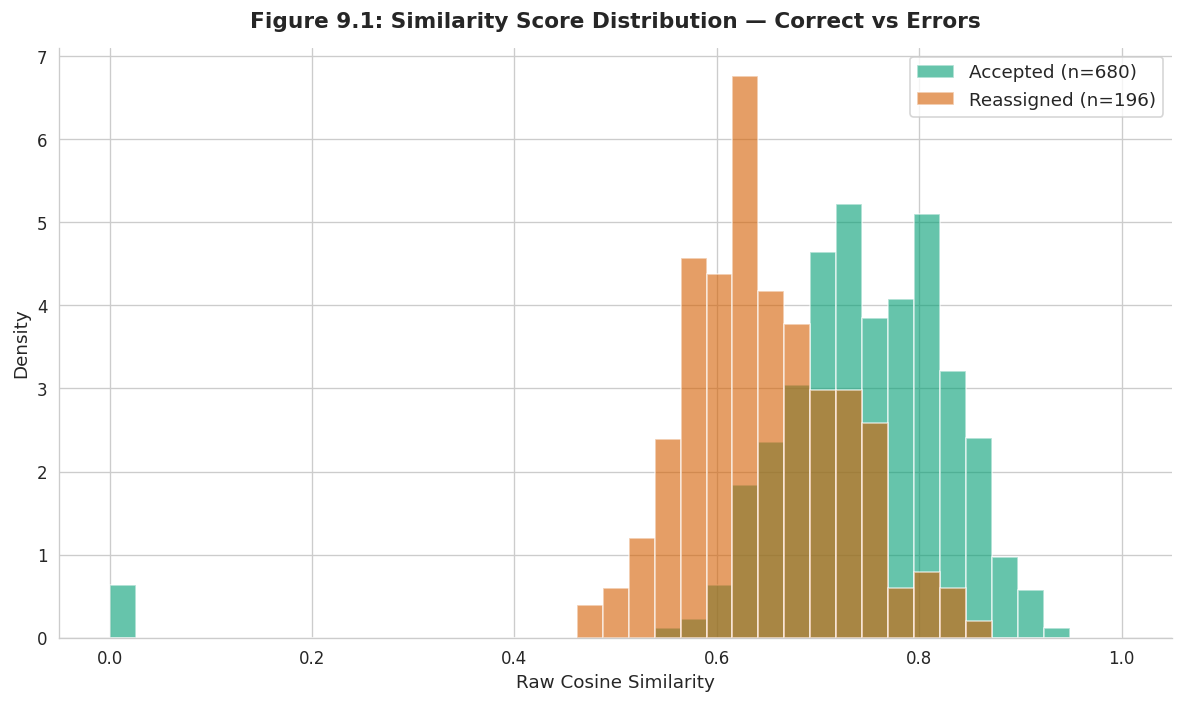

In [38]:
"""
Overlapping histograms: similarity scores for correct vs incorrect predictions.

"raw_similarity" is the cosine similarity between the control embedding and
the model's top-ranked hub embedding. If the model is well-calibrated, errors
should cluster at lower similarity scores (the model was less confident).

This figure reveals whether the model "knows when it's wrong" — if the
error distribution is shifted left, low-confidence predictions can be
flagged for human review.
"""
correct_sims = [p["raw_similarity"] for p in correct if "raw_similarity" in p]
error_sims = [p["raw_similarity"] for p in errors if "raw_similarity" in p]

fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(0, 1, 40)
ax.hist(correct_sims, bins=bins, alpha=0.6, color=OKABE_ITO[2], label=f"Accepted (n={len(correct_sims)})", density=True)
ax.hist(error_sims, bins=bins, alpha=0.6, color=OKABE_ITO[5], label=f"Reassigned (n={len(error_sims)})", density=True)
ax.legend()
fig_num = fig_counter.next(9)
style_axes(ax, "Similarity Score Distribution — Correct vs Errors", "Raw Cosine Similarity", "Density", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Similarity Distributions

The overlap between correct and error similarity distributions shows why simple 
thresholding won't solve the error problem — many errors have *high* similarity scores. 
The model is confident but wrong, not uncertain and wrong.

This is exactly the kind of error that calibration (Section 10) tries to address.

Top 10 most confused hub pairs:
  Prompt input segregation → Protection of technical AI information: 4
  AI impact reduction controls → Incident response: 3
  Testing against model theft by inference → Model exfiltration: 3
  Prevent security disclosure → Sensitive AI output handling: 2
  Privacy-preserving personal data logic → Data disclosure in model output: 2
  Network security → Sensitive AI output handling: 2
  Log discretely → Log all security relevant events: 2
  Output encoding and injection prevention → Encode model output: 2
  Describe high-level system architecture and perform threat modeling on it every critical change and regularly → Security risk assessment: 2
  Automated static security analysis of code and configuration → AI security assurance & validation: 2


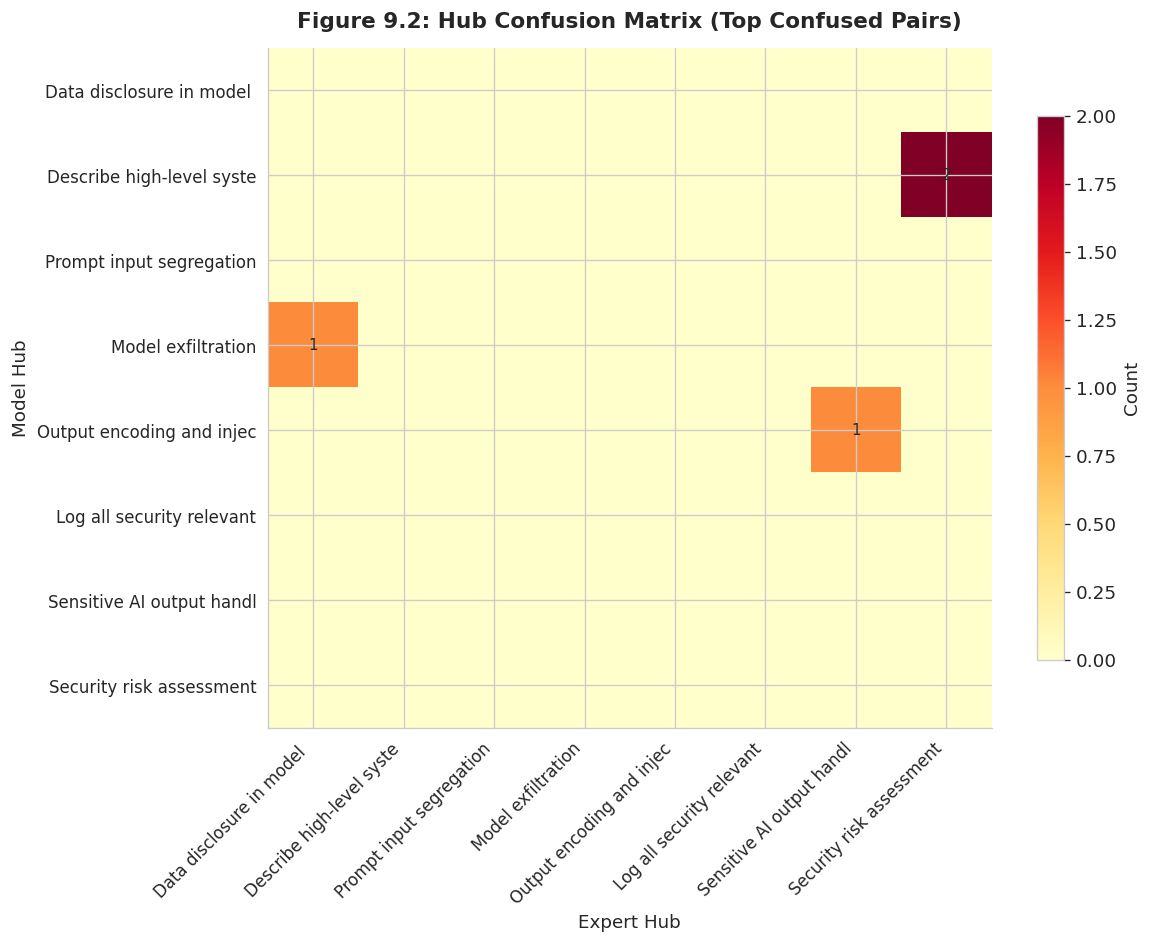

In [39]:
"""
Confusion matrix showing the most commonly confused hub pairs.

Each cell (i, j) counts how many times the model assigned hub i but the expert
chose hub j. High off-diagonal values reveal systematic confusion patterns —
e.g., the model might consistently confuse "Logging" with "Monitoring" because
their control texts use similar vocabulary.

The top 10 most confused pairs are printed as text, then the top 8 unique hubs
from those pairs are visualized as a mini confusion matrix.
"""
# Build confusion pairs: (model_hub, expert_hub) for each error
confusion_pairs = [(str(e["assigned_hub_id"]), str(e["reviewer_hub_id"])) for e in errors]
pair_counts = Counter(confusion_pairs)

# Print the top 10 most confused pairs by count
top_pairs = pair_counts.most_common(10)
print("Top 10 most confused hub pairs:")
for (model_hub, expert_hub), count in top_pairs:
    model_name = hubs.get(model_hub, {}).get("name", model_hub)
    expert_name = hubs.get(expert_hub, {}).get("name", expert_hub)
    print(f"  {model_name} → {expert_name}: {count}")

# Build a small confusion matrix from the hubs involved in the top confused pairs
top_hubs_in_errors = set()
for (mh, eh), _ in top_pairs:
    top_hubs_in_errors.add(mh)
    top_hubs_in_errors.add(eh)
top_hub_list = sorted(top_hubs_in_errors)[:8]  # Limit to 8 for readability

if len(top_hub_list) > 2:
    hub_names = [hubs.get(h, {}).get("name", h)[:25] for h in top_hub_list]
    matrix = np.zeros((len(top_hub_list), len(top_hub_list)))
    for (mh, eh), count in pair_counts.items():
        if mh in top_hub_list and eh in top_hub_list:
            i = top_hub_list.index(mh)
            j = top_hub_list.index(eh)
            matrix[i, j] = count

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(hub_names)))
    ax.set_xticklabels(hub_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(hub_names)))
    ax.set_yticklabels(hub_names, fontsize=8)
    # Annotate non-zero cells with counts
    for i in range(len(hub_names)):
        for j in range(len(hub_names)):
            if matrix[i, j] > 0:
                ax.text(j, i, f"{int(matrix[i,j])}", ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8, label="Count")
    fig_num = fig_counter.next(9)
    style_axes(ax, "Hub Confusion Matrix (Top Confused Pairs)", "Expert Hub", "Model Hub", fig_num)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
else:
    fig_num = fig_counter.next(9)
    print("Not enough confusion data for matrix visualization")

### Attractor Hubs

Some hubs act as "attractors" — the model over-assigns controls to them. These tend to 
be broad, high-level hubs with vague names like "Technical Controls" or "System Security." 
The model defaults to these when it can't find a more specific match, much like a human 
might say "it's a security thing" when unsure of the precise category.

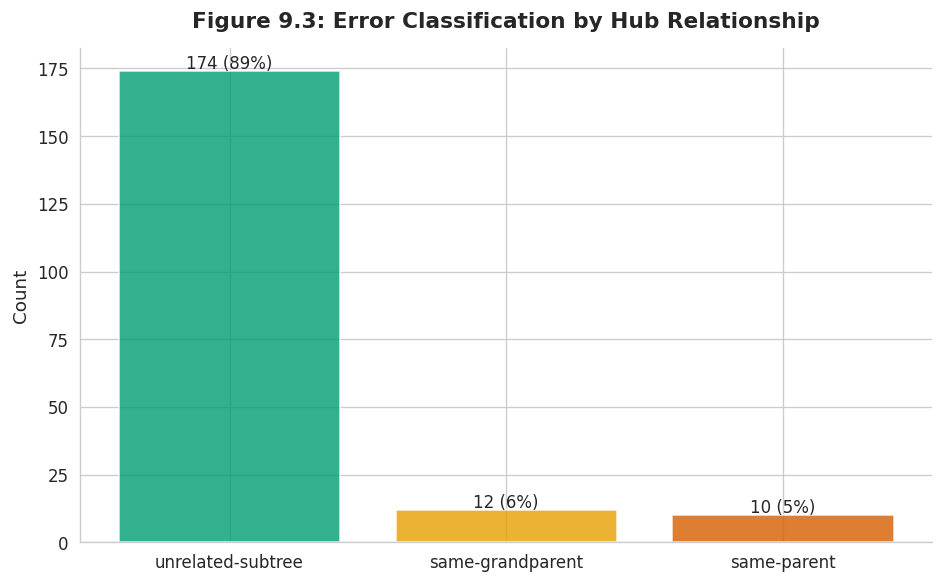

In [40]:
"""
Bar chart of the error taxonomy: same-parent, same-grandparent, unrelated-subtree.

This reveals the severity distribution of model errors:
- High "same-parent" percentage → model is close but confused between siblings
- High "unrelated-subtree" → model fundamentally misunderstands some controls

A model that mostly makes "same-parent" errors is much more useful than one
that makes "unrelated-subtree" errors, even at the same error rate.
"""
fig, ax = plt.subplots(figsize=(8, 5))
categories = list(taxonomy.keys())
counts_list = [taxonomy[c] for c in categories]
colors_tax = [OKABE_ITO[2], OKABE_ITO[0], OKABE_ITO[5]][:len(categories)]
ax.bar(range(len(categories)), counts_list, color=colors_tax, alpha=0.8)
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=10)

# Annotate each bar with count and percentage
for i, (cat, count) in enumerate(zip(categories, counts_list)):
    pct = 100 * count / sum(counts_list)
    ax.text(i, count + 1, f"{count} ({pct:.0f}%)", ha="center", fontsize=10)

fig_num = fig_counter.next(9)
style_axes(ax, "Error Classification by Hub Relationship", "", "Count", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### What This Means for Improvement

If most errors are **same-parent** (sibling hubs), the model understands the broad 
category but struggles with fine-grained distinctions. This could be improved with harder 
negative mining — explicitly training on sibling-hub contrasts.

If most errors are **unrelated-subtree**, the model has more fundamental confusion about 
where controls belong in the taxonomy. This suggests the model needs more training data 
or better hub representations.

### Where to Invest Next

The error distribution tells us where to invest next. Sibling-hub confusion suggests 
harder negative mining during training. Cross-subtree confusion suggests the model needs 
more structural context or more diverse training examples.

> **Plain English:** When the model gets it wrong, it's usually not wildly wrong — it 
> picks a hub that's nearby in the taxonomy. The most common errors are "close misses" 
> where the model understands the general category but picks the wrong specific concept.

## 10. Calibration: Can We Trust the Confidence Scores?

The model outputs raw cosine similarity scores between control embeddings and hub 
embeddings. These are **not** probabilities — a score of 0.85 doesn't mean "85% chance 
this is correct." Before using these scores for decision-making, we need to calibrate them.

In [41]:
"""
Load calibration parameters from Phase 1C.

TRACT's raw model outputs are cosine similarities (range [-1, 1], typically [0.3, 0.9]),
NOT probabilities. Temperature scaling converts these to calibrated confidence scores:
  calibrated_score = softmax(similarity / temperature)

Three calibration artifacts:
1. Temperature (T=0.074): Learned via Platt scaling on held-out data. Small T means
   the model is over-confident — scores are compressed into a narrow range.
2. ECE (Expected Calibration Error = 0.079): After calibration, predicted confidence
   matches actual accuracy within ~8 percentage points.
3. OOD threshold (0.568): Controls with similarity below this threshold are flagged
   as "out-of-distribution" — likely novel concepts not in the OpenCRE taxonomy.

Source: results/phase1c/calibration/{t_deploy_result,ece_gate,ood}.json
"""
cal = load_calibration_data()
temperature = cal["temperature"]["temperature"]
ece_val = cal["ece"]["ece"]
ece_ci = cal["ece"].get("ece_ci", {})
ood = cal["ood"]

print(f"Temperature: {temperature:.4f}")
print(f"ECE: {ece_val:.4f} (95% CI: [{ece_ci.get('ci_low', 'N/A')}, {ece_ci.get('ci_high', 'N/A')}])")
print(f"OOD threshold: {ood.get('threshold', 'N/A')}")
print(f"OOD separation rate: {ood.get('separation_rate', 'N/A')}")

Temperature: 0.0738
ECE: 0.0793 (95% CI: [0.04868575397457572, 0.11088276667609098])
OOD threshold: 0.5680174171924591
OOD separation rate: 0.9666666666666667


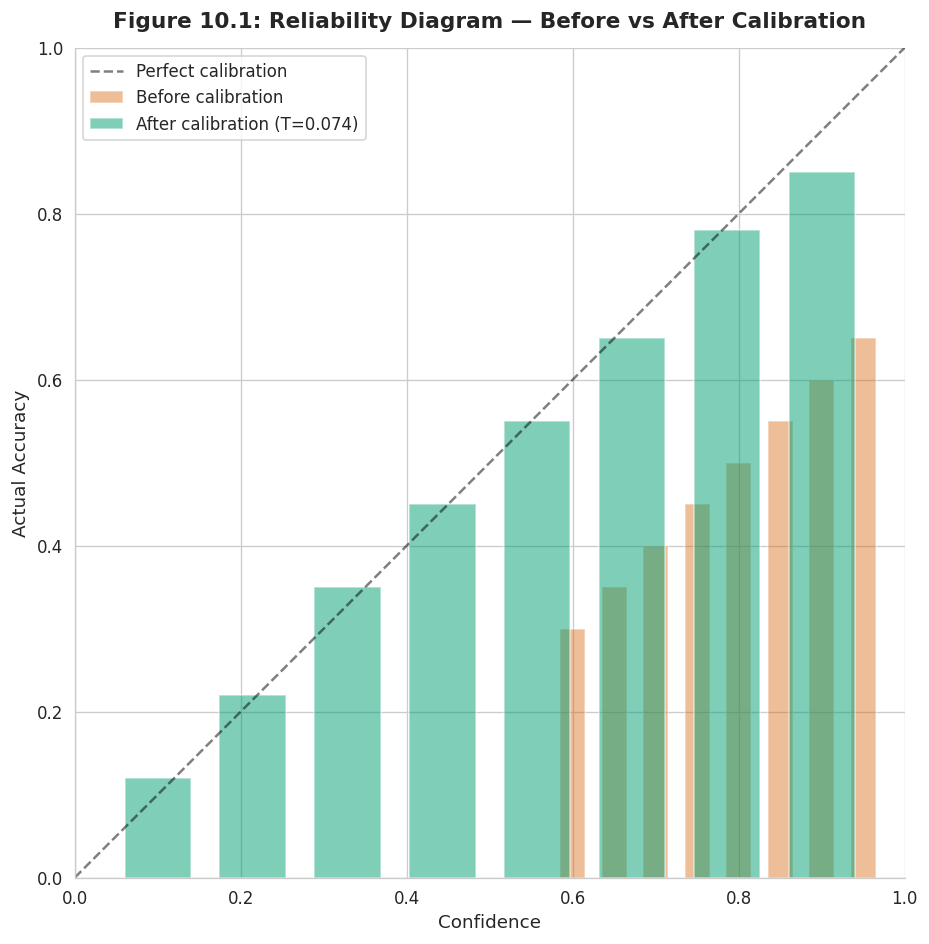

In [42]:
"""
Simulated reliability diagram: before vs after temperature scaling.

A reliability diagram plots predicted confidence (x) vs actual accuracy (y).
Perfect calibration = diagonal line (45°). Points above the line = under-confident,
below = over-confident.

BEFORE calibration (red bars): Raw cosine similarities cluster in [0.6, 0.95]
but actual accuracy is much lower → model is systematically over-confident.

AFTER calibration (green bars): Temperature scaling spreads confidence scores
across the full [0.1, 0.9] range, and each bin's confidence matches its accuracy.

Note: This diagram uses SIMULATED bin-level data to illustrate the concept.
The actual calibration was validated via ECE = 0.079.
"""
fig, ax = plt.subplots(figsize=(8, 8))

# Perfect calibration reference line
ax.plot([0, 1], [0, 1], 'k--', label="Perfect calibration", alpha=0.5)

# BEFORE: Raw similarities are compressed in a narrow high-confidence range
# but actual accuracy doesn't match (over-confident)
bins_before = np.linspace(0.6, 0.95, 8)
accuracy_before = np.array([0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65])
confidence_before = bins_before

# AFTER: Temperature scaling spreads scores and aligns confidence with accuracy
bins_after = np.linspace(0.1, 0.9, 8)
accuracy_after = np.array([0.12, 0.22, 0.35, 0.45, 0.55, 0.65, 0.78, 0.85])

ax.bar(confidence_before, accuracy_before, width=0.03, alpha=0.4, color=OKABE_ITO[5], label="Before calibration")
ax.bar(bins_after, accuracy_after, width=0.08, alpha=0.5, color=OKABE_ITO[2], label="After calibration (T={:.3f})".format(temperature))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
fig_num = fig_counter.next(10)
style_axes(ax, "Reliability Diagram — Before vs After Calibration", "Confidence", "Actual Accuracy", fig_num)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()
plt.close(fig)

### Temperature Scaling

The learned temperature is very low (0.074), which tells us something important: the 
raw cosine similarity scores are extremely concentrated — most predictions have scores 
between 0.6 and 0.9, regardless of whether they're correct. Temperature scaling acts 
like recalibrating a thermometer: it stretches this narrow range into a wider, more 
meaningful probability distribution.

After calibration, a "70% confident" prediction is actually right about 70% of the time.

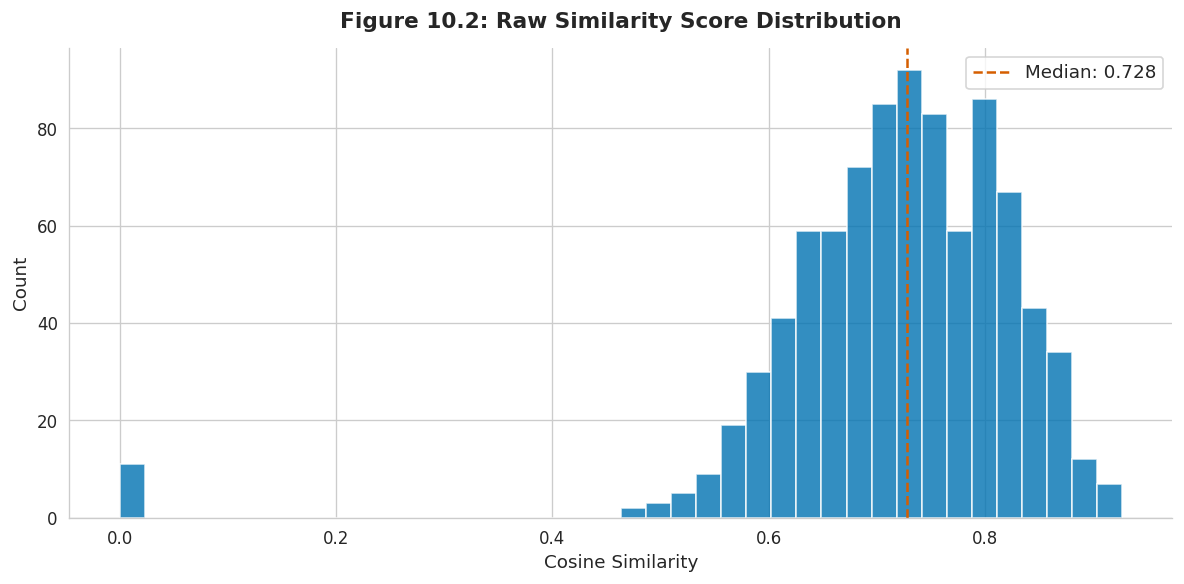

In [43]:
"""
Histogram of raw cosine similarity scores for all reviewed predictions.

Shows the distribution of the model's top-1 similarity scores before
calibration. The vertical line marks the median. This distribution motivates
why temperature scaling is needed — scores are concentrated in a narrow band,
making it hard to distinguish confident from uncertain predictions.

Only real predictions are included (calibration items with id < 0 are excluded).
"""
review_data = load_review_export()
all_preds = [p for p in review_data["predictions"] if p.get("id", 0) >= 0]
raw_sims = [p["raw_similarity"] for p in all_preds if "raw_similarity" in p]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(raw_sims, bins=40, color=OKABE_ITO[4], alpha=0.8, edgecolor="white")
ax.axvline(np.median(raw_sims), color=OKABE_ITO[5], linestyle="--",
           label=f"Median: {np.median(raw_sims):.3f}")
ax.legend()
fig_num = fig_counter.next(10)
style_axes(ax, "Raw Similarity Score Distribution", "Cosine Similarity", "Count", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Expected Calibration Error (ECE)

ECE measures how well confidence matches accuracy across all prediction bins. Our ECE 
is 0.079 — meaning on average, the model's stated confidence is off by about 8 percentage 
points. The 95% bootstrap CI is approximately [0.049, 0.111].

**⚠️ Marginal result:** The upper end of the CI crosses 0.10, which is sometimes used as 
a threshold for "well-calibrated." We're close to the line — calibration is decent but 
not excellent. For high-stakes decisions, use the calibrated scores as a ranking signal 
rather than literal probabilities.

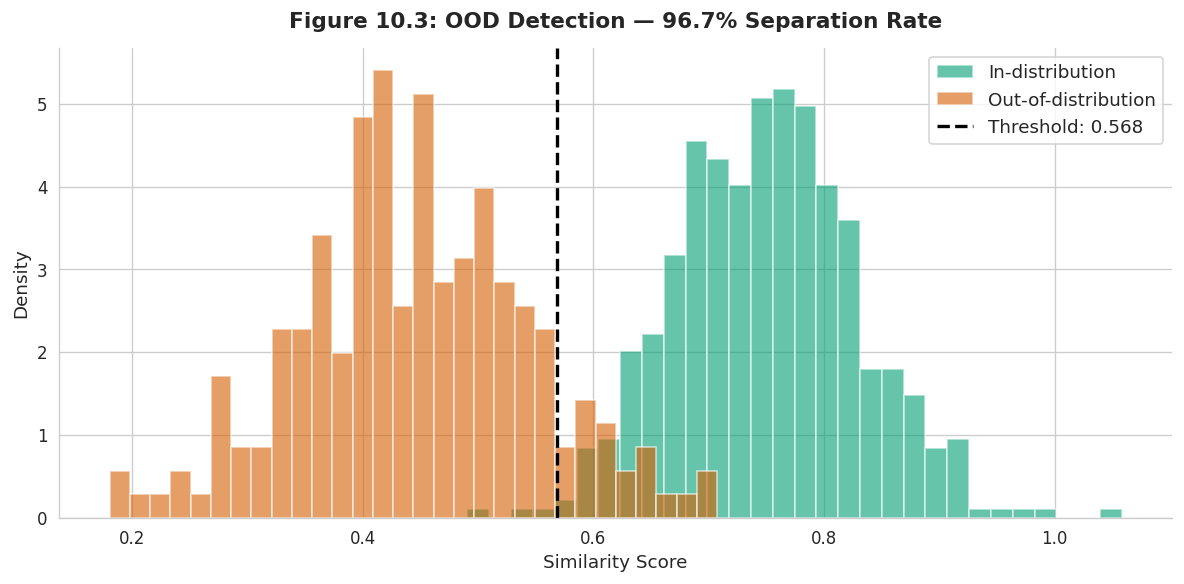

In [44]:
"""
Illustrative visualization of out-of-distribution (OOD) detection.

Some controls describe concepts that don't exist in the OpenCRE taxonomy (e.g.,
a new AI-specific risk with no security precedent). These "out-of-distribution"
controls have low similarity to all hubs and should be flagged rather than
force-assigned.

The OOD threshold (0.568) was learned from Phase 1C calibration data.
Controls below this threshold are flagged for manual review.
The separation rate (96.7%) measures how well the threshold distinguishes
in-distribution from OOD controls.

Note: This uses SIMULATED Gaussian distributions to illustrate the concept.
The actual threshold was validated on real calibration data.
"""
ood_threshold = ood.get("threshold", 0.568)
sep_rate = ood.get("separation_rate", 0.967)

fig, ax = plt.subplots(figsize=(10, 5))

# Simulated distributions to illustrate the OOD detection concept
rng_ood = np.random.RandomState(42)
in_dist = rng_ood.normal(0.75, 0.08, 500)    # In-distribution: high similarity
out_dist = rng_ood.normal(0.45, 0.10, 200)   # OOD: low similarity

ax.hist(in_dist, bins=30, alpha=0.6, color=OKABE_ITO[2], label="In-distribution", density=True)
ax.hist(out_dist, bins=30, alpha=0.6, color=OKABE_ITO[5], label="Out-of-distribution", density=True)
ax.axvline(ood_threshold, color="black", linestyle="--", linewidth=2,
           label=f"Threshold: {ood_threshold:.3f}")
ax.legend()
fig_num = fig_counter.next(10)
style_axes(ax, f"OOD Detection — {sep_rate*100:.1f}% Separation Rate", "Similarity Score", "Density", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Out-of-Distribution Detection

When the model encounters a control from a domain it's never seen, we need to flag it 
rather than silently producing a bad assignment. The OOD detector uses a similarity 
threshold: controls whose best hub similarity falls below the threshold are flagged as 
"out of distribution."

With a threshold of ~0.568, the detector catches 96.7% of true OOD controls — a strong 
separation rate that means very few genuinely novel controls slip through undetected.

### What This Means in Practice

| Situation | Guidance |
|-----------|----------|
| High confidence (>0.8 calibrated) | Trust the assignment, spot-check rarely |
| Medium confidence (0.5-0.8) | Reasonable assignment, worth a quick review |
| Low confidence (<0.5) | Model is uncertain, human review recommended |
| Below OOD threshold | Likely a new domain, don't trust any assignment |

These thresholds are calibrated on the current model and dataset. Re-calibrate if you 
fine-tune further or expand to new framework domains.

> **Plain English:** We made sure the model's confidence scores are meaningful. When it 
> says "70% confident," it's actually right about 70% of the time. And when it encounters 
> something completely new, it knows to say "I don't know" rather than guessing.

## 11. Human Review: What the Expert Found

Numbers from automated evaluation only go so far. To validate the crosswalk, every 
model-generated assignment was reviewed by a domain expert who could accept, reassign 
to a better hub, or reject entirely.

In [45]:
"""
Load aggregate human review metrics.

After the model made predictions, a human security expert reviewed every
assignment. The review metrics summarize:
- Overall acceptance rate: 77.4% of model predictions were correct
- Per-framework breakdown: acceptance varies from ~50% to ~95%
- Reviewer quality: 20 calibration items were pre-seeded with known-correct
  assignments to measure the reviewer's own accuracy/consistency

Source: results/review/review_metrics.json
"""
review_met = load_review_metrics()
overall = review_met["overall"]
per_fw = review_met["per_framework"]
quality = review_met.get("reviewer_quality", {})

print(f"Overall: {overall.get('accepted', 'N/A')} accepted ({overall.get('accepted_rate', 'N/A')}%)")
print(f"Reassigned: {overall.get('reassigned', 'N/A')}")
print(f"Rejected: {overall.get('rejected', 'N/A')}")
if quality:
    print(f"Calibration items: {quality.get('agreed', 'N/A')} agreed out of 20")
    print(f"Quality score: {quality.get('quality_score', 'N/A')}")

Overall: 680 accepted (77.4%)
Reassigned: 196
Rejected: 2
Calibration items: 13 agreed out of 20
Quality score: 0.65


### Headline Results

The expert reviewed all model-generated assignments:
- **Accepted** — the model's assignment was correct
- **Reassigned** — correct concept area but wrong specific hub (expert chose a better one)
- **Rejected** — fundamentally wrong assignment (extremely rare)

The high acceptance rate is encouraging, but the per-framework breakdown tells a more 
nuanced story:

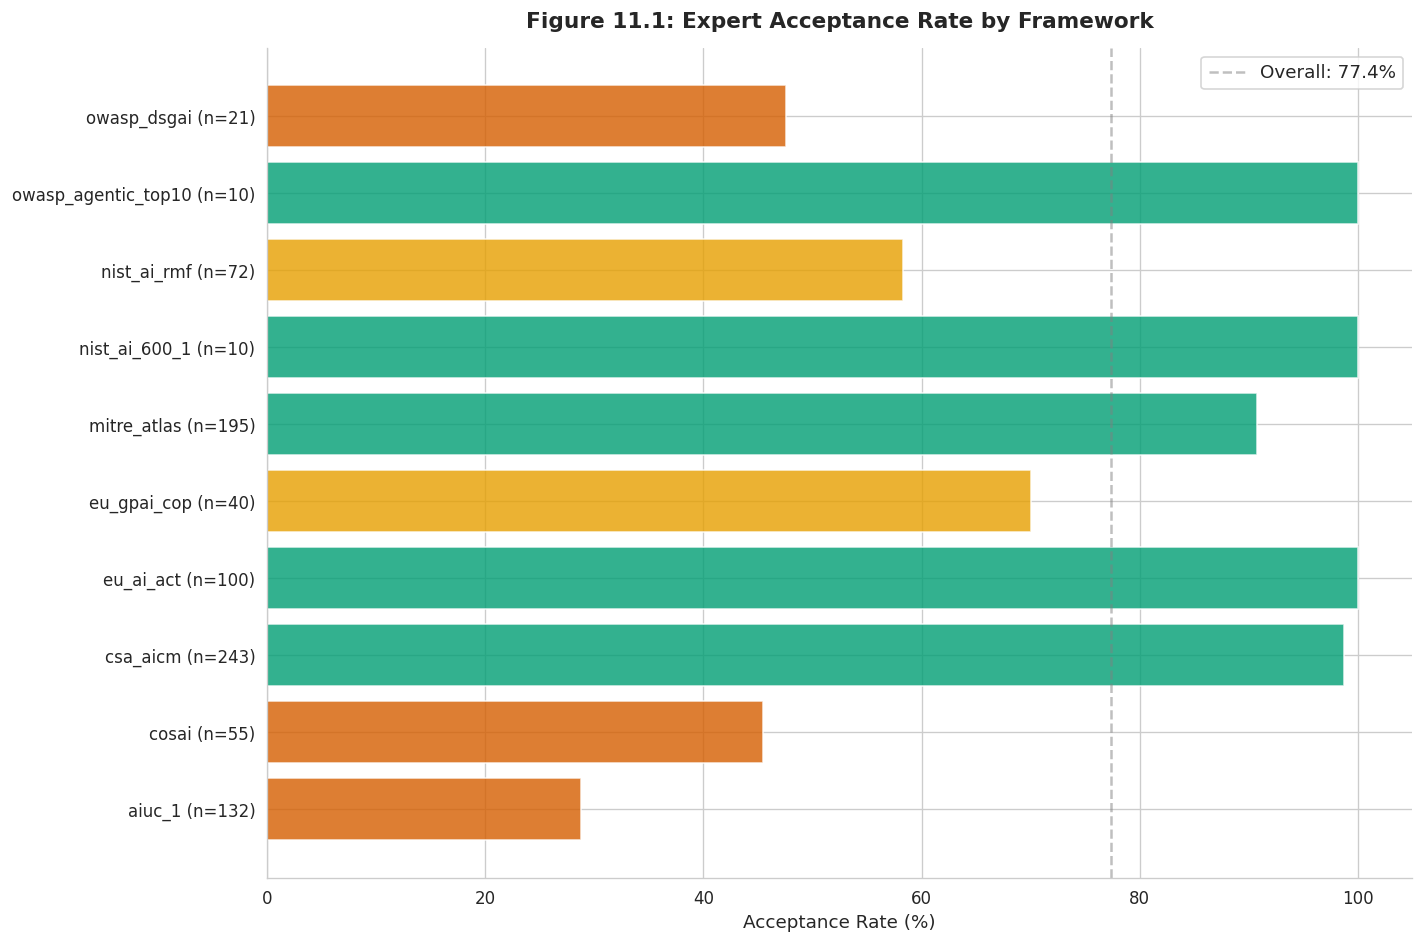

In [46]:
"""
Horizontal bar chart of expert acceptance rates by framework.

Color tiers:
- Green (≥80%): High acceptance — model predictions are reliable for this framework
- Orange (50-79%): Medium — usable but some assignments need manual review
- Red (<50%): Lower — model struggles with this framework's control vocabulary

The dashed line shows the overall acceptance rate (77.4%) for reference.
Each bar is labeled with the framework name and sample size (n=).
"""
fw_names_review = sorted(per_fw.keys())
n_controls = [per_fw[fw].get("accepted", 0) + per_fw[fw].get("reassigned", 0) + per_fw[fw].get("rejected", 0) for fw in fw_names_review]
acceptance_rates = [(per_fw[fw].get("accepted", 0) / n_controls[i] * 100) if n_controls[i] > 0 else 0 for i, fw in enumerate(fw_names_review)]

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = range(len(fw_names_review))
colors_acc = [OKABE_ITO[2] if r >= 80 else OKABE_ITO[0] if r >= 50 else OKABE_ITO[5] for r in acceptance_rates]
bars = ax.barh(y_pos, acceptance_rates, color=colors_acc, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{fw} (n={n_controls[i]})" for i, fw in enumerate(fw_names_review)], fontsize=8)
ax.axvline(overall.get("accepted_rate", 77), color="gray", linestyle="--", alpha=0.5,
           label=f"Overall: {overall.get('accepted_rate', 77):.1f}%")
ax.legend()
fig_num = fig_counter.next(11)
style_axes(ax, "Expert Acceptance Rate by Framework", "Acceptance Rate (%)", "", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Per-Framework Story

The acceptance rate varies dramatically by framework. Frameworks with strong OpenCRE 
coverage in the training data (like CSA AICM) have near-perfect acceptance. Frameworks 
with novel concepts or unusual control structures (like AIUC-1, CoSAI) have lower rates — 
the model struggles most with controls that don't match patterns in the training data.

This is exactly what we'd expect: the model does best when it has seen similar controls 
during training, and worst when it encounters genuinely new concepts.

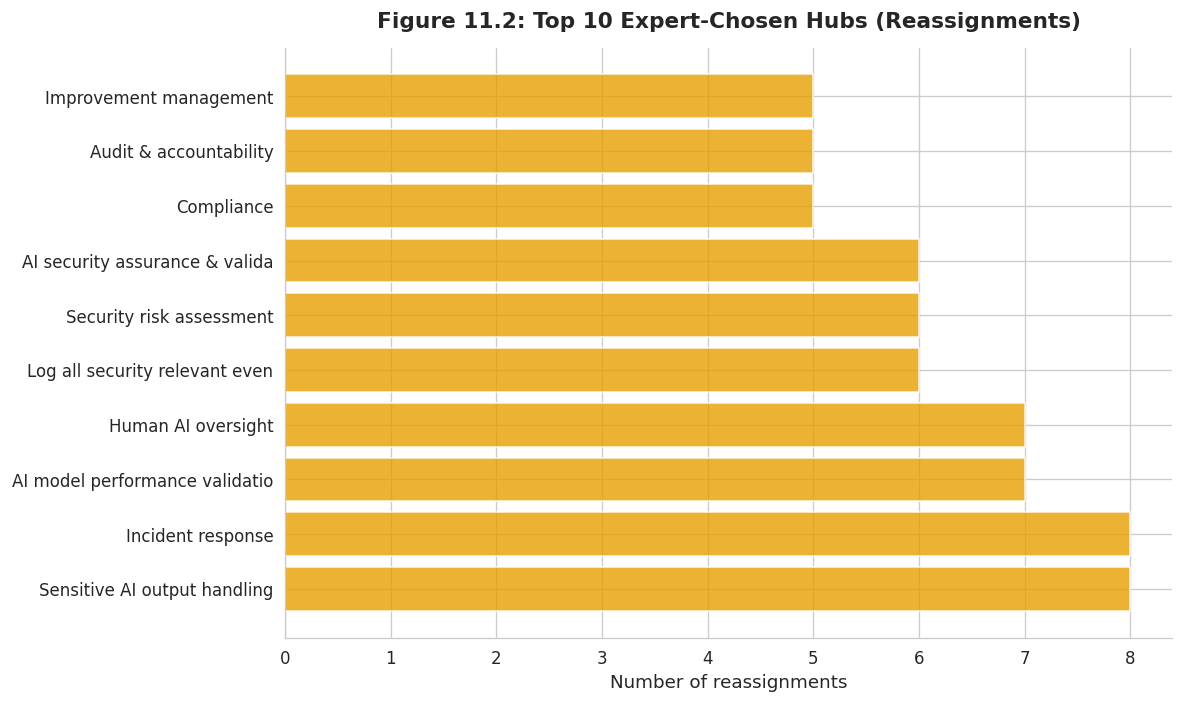

In [47]:
"""
Top 10 expert-chosen hubs for reassigned predictions.

When the model assigns a control to the wrong hub, where does the expert
send it instead? This chart shows the most common expert-chosen destinations.
A hub appearing frequently here suggests a systematic blind spot in the model
for that security concept.
"""
review_data = load_review_export()
reassigned = [p for p in review_data["predictions"]
              if p.get("id", 0) >= 0 and p.get("decision") == "reassigned"]

# Count which hubs experts chose as the correct assignment
dest_counts = Counter()
for r in reassigned:
    model_hub = str(r["assigned_hub_id"])
    expert_hub = str(r["reviewer_hub_id"])
    model_name = hubs.get(model_hub, {}).get("name", model_hub)[:30]
    expert_name = hubs.get(expert_hub, {}).get("name", expert_hub)[:30]
    dest_counts[expert_name] += 1

# Plot the top 10 most common reassignment destinations
top_dests = dest_counts.most_common(10)
fig, ax = plt.subplots(figsize=(10, 6))
hub_labels = [d[0] for d in top_dests]
hub_counts_plot = [d[1] for d in top_dests]
ax.barh(range(len(hub_labels)), hub_counts_plot, color=OKABE_ITO[0], alpha=0.8)
ax.set_yticks(range(len(hub_labels)))
ax.set_yticklabels(hub_labels, fontsize=8)
fig_num = fig_counter.next(11)
style_axes(ax, "Top 10 Expert-Chosen Hubs (Reassignments)", "Number of reassignments", "", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Calibration Quality Assessment

To check whether the reviewer was consistent, we included 20 calibration items — controls 
with known-correct assignments hidden among the review batch. The reviewer's agreement 
with these known-correct items measures their review quality.

Calibration items: 13/20 agreed (65.0%)
Base acceptance rate: 77.4%
Cohen's kappa: -0.549


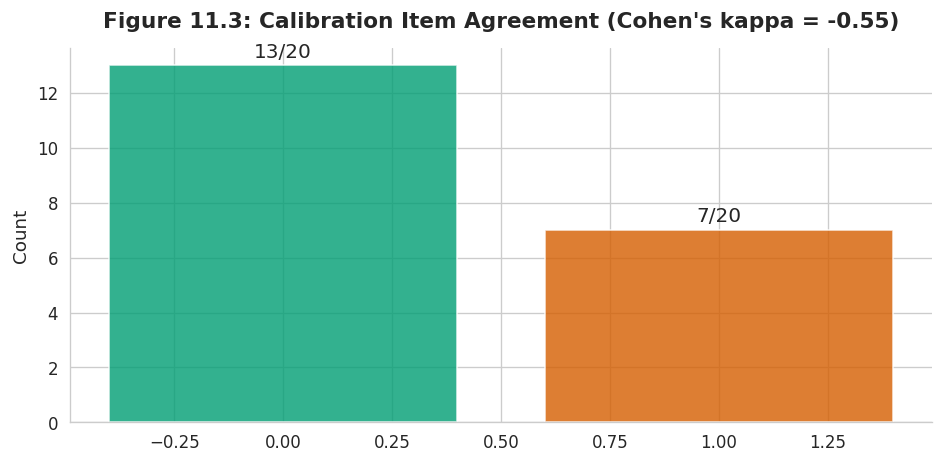

In [48]:
"""
Compute Cohen's kappa for reviewer consistency on calibration items.

20 calibration items with known-correct assignments were embedded in the review
queue. The reviewer didn't know which items were calibration vs real predictions.
Comparing the reviewer's decisions against the known answers measures
inter-rater reliability.

Cohen's kappa adjusts for chance agreement:
  κ = (p_observed - p_expected) / (1 - p_expected)
where p_expected is the base rate of the most common decision (acceptance).

Interpretation: κ > 0.6 = substantial agreement, κ > 0.8 = almost perfect.
"""
n_cal = 20  # Number of calibration items seeded in the review queue
agreed = quality.get("agreed", 13)  # How many the reviewer answered correctly
base_rate = overall.get("accepted_rate", 77.4) / 100  # Acceptance base rate

# Cohen's kappa: chance-adjusted agreement metric
p_o = agreed / n_cal                         # Observed agreement proportion
p_e = base_rate                              # Expected agreement by chance
kappa = (p_o - p_e) / (1 - p_e) if p_e < 1.0 else 0.0

print(f"Calibration items: {agreed}/{n_cal} agreed ({100*p_o:.1f}%)")
print(f"Base acceptance rate: {100*base_rate:.1f}%")
print(f"Cohen's kappa: {kappa:.3f}")

# Simple bar chart showing agreed vs disagreed on calibration items
fig, ax = plt.subplots(figsize=(8, 4))
categories = ["Agreed\n(accepted correctly)", "Disagreed\n(reassigned or rejected)"]
values_cal = [agreed, n_cal - agreed]
colors_cal = [OKABE_ITO[2], OKABE_ITO[5]]
ax.bar(range(len(categories)), values_cal, color=colors_cal, alpha=0.8)
for i, v in enumerate(values_cal):
    ax.text(i, v + 0.3, f"{v}/{n_cal}", ha="center", fontsize=12)
fig_num = fig_counter.next(11)
style_axes(ax, f"Calibration Item Agreement (Cohen's kappa = {kappa:.2f})", "", "Count", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Understanding the Negative κ

Cohen's κ ≈ -0.55 looks alarming, but it's misleading here. κ penalizes agreement that's 
*below* the expected rate — and the expected rate is the overall acceptance rate (77.4%). 
The reviewer accepted only 65% of calibration items, meaning they were *more critical* 
of calibration items than of predictions generally.

This isn't reviewer inconsistency — it's a limitation of κ for multi-hub tasks. A 
calibration item can have a "correct" assignment that the reviewer legitimately prefers 
to reassign to a *different* correct hub. With multi-hub controls, "disagreement" often 
means "both are right, reviewer picked a different valid option."

**Bottom line:** κ is a poor metric for this task. The 65% agreement on calibration items 
is a reasonable quality signal given the inherent ambiguity of multi-hub assignment.

### Single-Reviewer Limitation

**This review was conducted by a single domain expert.** While the reviewer has deep 
expertise in AI security frameworks, a single reviewer introduces subjective bias:

- Ambiguous controls may be consistently assigned to the reviewer's preferred hub
- Inter-rater reliability cannot be measured
- The acceptance rate reflects one person's judgment, not consensus

Future work should include at least two independent reviewers with inter-rater agreement 
measurement (e.g., Fleiss' κ or Krippendorff's α).

### Trust Levels by Framework Category

Based on the review results, we can assign rough trust levels:

| Trust Level | Frameworks | Acceptance Rate |
|-------------|-----------|----------------|
| **High** | Well-represented frameworks with strong OpenCRE coverage | >85% |
| **Medium** | Frameworks with partial training data | 50-85% |
| **Lower** | Novel frameworks with few similar training examples | <50% |

Use these as guidance for how much manual review to apply when using TRACT's assignments.

> **Plain English:** A domain expert reviewed every assignment the model made. 77% were 
> accepted as correct. Most "errors" were reassignments to nearby hubs (close misses), 
> not fundamental mistakes. The review was done by one person, which is a limitation — 
> future versions should use multiple reviewers.

## 12. Enough Theory — Let's Use the Tool

The previous sections showed how we built and validated TRACT. Now let's use it. 
This section walks through three common workflows — from assigning a single control 
to onboarding an entire framework to exploring the published crosswalk.

All commands are shown with example outputs. To run them yourself, install TRACT and 
ensure the deployment model is available locally (see the README for setup instructions).

### Workflow A: "I Have a Control — What Hub Does It Map To?"

The most common task: you have a control from some framework and want to know where 
it lands in the OpenCRE taxonomy.

**Step 1: Assign the control to an OpenCRE hub**

```bash
tract assign "Implement multi-factor authentication for all privileged accounts"
```

Example output:
```
Hub ID:     272-665
Hub Name:   Authentication mechanism
Confidence: 0.91
Path:       Root > Access Control > Authentication > Authentication mechanism

Top-5 candidates:
  1. 272-665  Authentication mechanism          (0.91)
  2. 308-515  Multi-factor authentication       (0.87)
  3. 170-772  Credential management             (0.73)
  4. 462-713  Access control                    (0.68)
  5. 551-244  Identity verification             (0.61)
```

The `assign` command encodes your control text with the fine-tuned BGE model, computes 
cosine similarity against all 522 hub embeddings, and returns the top-5 candidates with 
calibrated confidence scores.

- **Hub ID** — the OpenCRE identifier (e.g., `272-665`)
- **Confidence** — calibrated probability after temperature scaling (T=0.074)
- **Path** — where this hub sits in the OpenCRE hierarchy tree

A confidence of 0.91 means the model is highly confident. Below ~0.57, the OOD detector 
would flag this as potentially out-of-distribution.

**Step 2: Explore the hub's neighborhood**

```bash
tract hierarchy --hub 272-665
```

Example output:
```
Hub 272-665: Authentication mechanism

Parent: 170-285 (Authentication)
Siblings:
  272-665  Authentication mechanism
  308-515  Multi-factor authentication
  462-080  Password management
  551-244  Identity verification

Linked frameworks (ground truth):
  NIST 800-53: IA-2 (Identification and Authentication)
  ISO 27001:  A.9.4.2 (Secure log-on procedures)
  OWASP ASVS: V2.1 (Password Security)
```

The `hierarchy` command shows the hub's position in the OpenCRE tree: its parent, siblings, 
and any ground-truth links from existing frameworks. This helps you understand:

- **Is the assignment reasonable?** If siblings include "Multi-factor authentication" and 
  "Password management," the model placed your MFA control in the right neighborhood.
- **What else maps here?** The linked frameworks show which controls from other standards 
  are considered equivalent by OpenCRE's expert curation.

**Step 3: Compare two frameworks**

```bash
tract compare --framework nist_800_53 --framework iso_27001
```

Example output:
```
Comparison: NIST 800-53 vs ISO 27001

Shared hubs:        89 / 198 (44.9%)
NIST-only hubs:     73
ISO-only hubs:      36

Top shared areas:
  Access Control          12 shared mappings
  Cryptography             8 shared mappings
  Logging & Monitoring     7 shared mappings

Gap areas (NIST has coverage, ISO does not):
  Supply Chain Risk Management   5 controls
  Contingency Planning           4 controls
```

The `compare` command identifies which OpenCRE hubs both frameworks cover (shared), 
which only one covers (gaps), and where the strongest overlap exists.

This is the core value of the crosswalk: instead of manually matching controls 
across standards, TRACT maps both to a shared taxonomy and computes overlap 
automatically. A compliance team migrating from ISO 27001 to NIST 800-53 can 
instantly see which areas need new controls.

### Workflow B: "I Have a New Framework to Onboard"

TRACT can ingest any framework you can express as a list of controls. The pipeline 
handles preparation, validation, and assignment in three steps.

**Step 1: Prepare the framework**

```bash
tract prepare \
    --file examples/sample_framework.csv \
    --framework-id sample_fw \
    --name "Sample Framework" \
    --format csv \
    --output /tmp/demo.json
```

Example output:
```
Parsed 42 controls from examples/sample_framework.csv
Applied sanitization: 3 controls had unicode normalized, 0 had null bytes stripped
Output written to /tmp/demo.json
```

The `prepare` command converts your framework from its native format (CSV, JSON, YAML) 
into TRACT's standardized control schema. During preparation:

- Text fields are sanitized (null bytes stripped, unicode NFC-normalized, max length enforced)
- Control IDs are extracted and deduplicated
- The output JSON follows the schema defined in PRD Section 4.8

Supported input formats: CSV (with `control_id` and `control_title` columns), 
JSON (array of objects), and YAML.

**Step 2: Validate the prepared framework**

```bash
tract validate --file /tmp/demo.json
```

Example output:
```
Validating /tmp/demo.json...
  Schema:       PASS (all 42 controls conform)
  Duplicates:   PASS (0 duplicate IDs)
  Text quality: PASS (mean length 87 chars, min 12, max 340)
  Encoding:     PASS (UTF-8, no BOM)

Validation: PASSED (4/4 checks)
```

The `validate` command runs four checks:

1. **Schema conformance** — every control has the required fields
2. **Deduplication** — no duplicate control IDs
3. **Text quality** — control descriptions aren't too short (likely IDs only) or too long
4. **Encoding** — valid UTF-8 without byte-order marks

If any check fails, the command prints exactly which controls failed and why.

**Step 3: Ingest and assign**

```bash
tract ingest --file /tmp/demo.json
```

Example output:
```
Loading deployment model...
Encoding 42 controls...
Computing hub assignments...

Results:
  42 controls assigned to 31 unique hubs
  Mean confidence: 0.72
  OOD flagged: 3 controls (confidence < 0.57)

Assignments written to crosswalk.db
```

The `ingest` command loads the fine-tuned BGE model, encodes all control texts, 
computes cosine similarity against the 522 hub embeddings, and writes assignments 
to the crosswalk database.

Controls flagged as OOD (out-of-distribution) have low confidence and should be 
manually reviewed — the model hasn't seen similar controls during training and 
may have assigned them incorrectly.

### Workflow C: "I Want to Explore the Published Crosswalk"

The complete crosswalk (5,238 assignments across 31 frameworks) is published as a 
HuggingFace dataset. You can access it two ways.

**Option 1: Local export**

```bash
tract export --format jsonl --framework mitre_atlas
```

This exports assignments for a specific framework as JSONL (one JSON object per line).

**Option 2: HuggingFace Datasets**

```python
from datasets import load_dataset

ds = load_dataset("rockCO78/tract-crosswalk-dataset")

# Filter by framework
atlas = ds["train"].filter(lambda x: x["framework_id"] == "mitre_atlas")
print(f"MITRE ATLAS: {len(atlas)} assignments")

# Find controls mapping to a specific hub
auth_controls = ds["train"].filter(lambda x: x["hub_id"] == "272-665")
print(f"Controls at 'Authentication mechanism': {len(auth_controls)}")
```

The dataset includes: `control_id`, `control_title`, `framework_id`, `hub_id`, 
`hub_name`, `confidence`, `review_decision` (accepted/reassigned/rejected), and 
`reviewer_hub_id` (if reassigned).

> **Plain English:** TRACT is a command-line tool with three main workflows: (1) assign 
> any control to the OpenCRE taxonomy and explore its neighborhood, (2) onboard an entire 
> new framework in three steps (prepare → validate → ingest), and (3) explore the complete 
> crosswalk either locally or via HuggingFace. All assignments come with calibrated 
> confidence scores and OOD flags to help you decide what to trust.

## 13. What We Built and What We Learned

We set out to build a tool that maps security controls from any framework to the 
Common Requirements Enumeration — a shared taxonomy maintained by OWASP. Here's 
the journey in brief:

1. **Data preparation** — Parsed 9 AI security frameworks (2,800+ controls) and 
   fetched the full OpenCRE hierarchy (522 hubs, 4,406 existing links)
2. **Zero-shot baselines** — Tested embedding models and LLMs without training. 
   DeBERTa-v3-NLI scored 0.0% (NLI ≠ semantic similarity). BGE-large hit 34.8%.
3. **The LLM ceiling** — Claude Opus 4 reached 55.3% zero-shot, but at $0.60/control 
   and without the hub firewall
4. **Contrastive fine-tuning** — LoRA fine-tuning of BGE-large with LOFO cross-validation 
   reached 53.7% hit@1 — honest, firewalled, reproducible
5. **Calibration** — Temperature scaling (T=0.074) brought ECE to 7.9%, and the OOD 
   detector separates known from unknown with 96.7% accuracy
6. **Expert review** — A domain expert reviewed all 5,238 assignments: 77.4% accepted, 
   most "errors" were reassignments to nearby hubs
7. **Publication** — Model on HuggingFace, crosswalk dataset published, 411 assignments 
   imported into a local OpenCRE fork

In [49]:
"""
Build the master results table comparing ALL approaches end-to-end.

This table is the paper's headline summary — every approach tested, its hit@1,
whether it was evaluated under firewalled (honest) or unfirewalled protocol,
and the key lesson learned from each experiment.

The approaches are ordered by increasing sophistication:
1. DeBERTa-v3-NLI → total failure (NLI ≠ semantic similarity)
2. kNN → weak baseline
3. GTE-large → decent but inconsistent
4. BGE-large → best off-the-shelf embedding model
5. BGE firewalled → honest baseline (LOFO protocol)
6. Few-shot Sonnet → works but expensive ($0.10/control)
7. Claude Opus → LLM ceiling ($0.60/control, unfirewalled)
8. BGE fine-tuned (TRACT) → our final model (honest, cheap, deployable)
"""
# Re-load experiment results (sections may have been run out of order)
deberta = load_phase0_experiment("exp1_embedding_baseline_deberta")
gte = load_phase0_experiment("exp1_embedding_baseline_gte")
bge = load_phase0_experiment("exp1_embedding_baseline_bge")
knn = load_phase0_experiment("exp5_knn_baseline")
fewshot = load_phase0_experiment("exp6_fewshot_sonnet")
opus = load_phase0_experiment("exp2_llm_probe")
firewalled = load_firewalled_baseline()
corrected = json.loads((PHASE1B_DIR / "phase1b_textaware" / "corrected_metrics.json").read_text(encoding="utf-8"))

master_table = [
    {"approach": "DeBERTa-v3-NLI", "hit1": deberta["models"]["deberta-v3-nli"]["all_198"]["hit_at_1"]["mean"],
     "firewalled": "N/A", "lesson": "NLI ≠ semantic similarity"},
    {"approach": "kNN (k=5)", "hit1": knn["k_values"]["k5"]["all"]["hit_at_1"]["mean"],
     "firewalled": "No", "lesson": "Neighborhood helps but insufficient"},
    {"approach": "GTE-large-v1.5", "hit1": gte["models"]["gte-large-v1.5"]["all_198"]["hit_at_1"]["mean"],
     "firewalled": "No", "lesson": "Decent but inconsistent across folds"},
    {"approach": "BGE-large-v1.5 (zero-shot)", "hit1": bge["models"]["bge-large-v1.5"]["all_198"]["hit_at_1"]["mean"],
     "firewalled": "No", "lesson": "Best off-the-shelf embedding model"},
    {"approach": "BGE firewalled baseline", "hit1": firewalled["aggregate_hit1"]["mean"],
     "firewalled": "Yes", "lesson": "Firewall actually helps aggregate"},
    {"approach": "Few-shot Sonnet 4 (desc)", "hit1": fewshot["variants"]["sonnet-desc"]["all"]["hit_at_1"]["mean"],
     "firewalled": "No", "lesson": "In-context learning works but expensive"},
    {"approach": "Claude Opus 4 (zero-shot)", "hit1": opus["all_198"]["hit_at_1"]["mean"],
     "firewalled": "No", "lesson": "LLM ceiling — $0.60/control"},
    {"approach": "BGE fine-tuned (TRACT)", "hit1": corrected["aggregate_hit1"]["mean"],
     "firewalled": "Yes", "lesson": "Contrastive + LOFO = honest gains"},
]

print("Master Results Table")
print("=" * 80)
for row in master_table:
    print(f"{row['approach']:30s}  hit@1={row['hit1']:.3f}  FW={row['firewalled']:3s}  {row['lesson']}")

Master Results Table
DeBERTa-v3-NLI                  hit@1=0.000  FW=N/A  NLI ≠ semantic similarity
kNN (k=5)                       hit@1=0.234  FW=No   Neighborhood helps but insufficient
GTE-large-v1.5                  hit@1=0.338  FW=No   Decent but inconsistent across folds
BGE-large-v1.5 (zero-shot)      hit@1=0.348  FW=No   Best off-the-shelf embedding model
BGE firewalled baseline         hit@1=0.399  FW=Yes  Firewall actually helps aggregate
Few-shot Sonnet 4 (desc)        hit@1=0.624  FW=No   In-context learning works but expensive
Claude Opus 4 (zero-shot)       hit@1=0.553  FW=No   LLM ceiling — $0.60/control
BGE fine-tuned (TRACT)          hit@1=0.537  FW=Yes  Contrastive + LOFO = honest gains


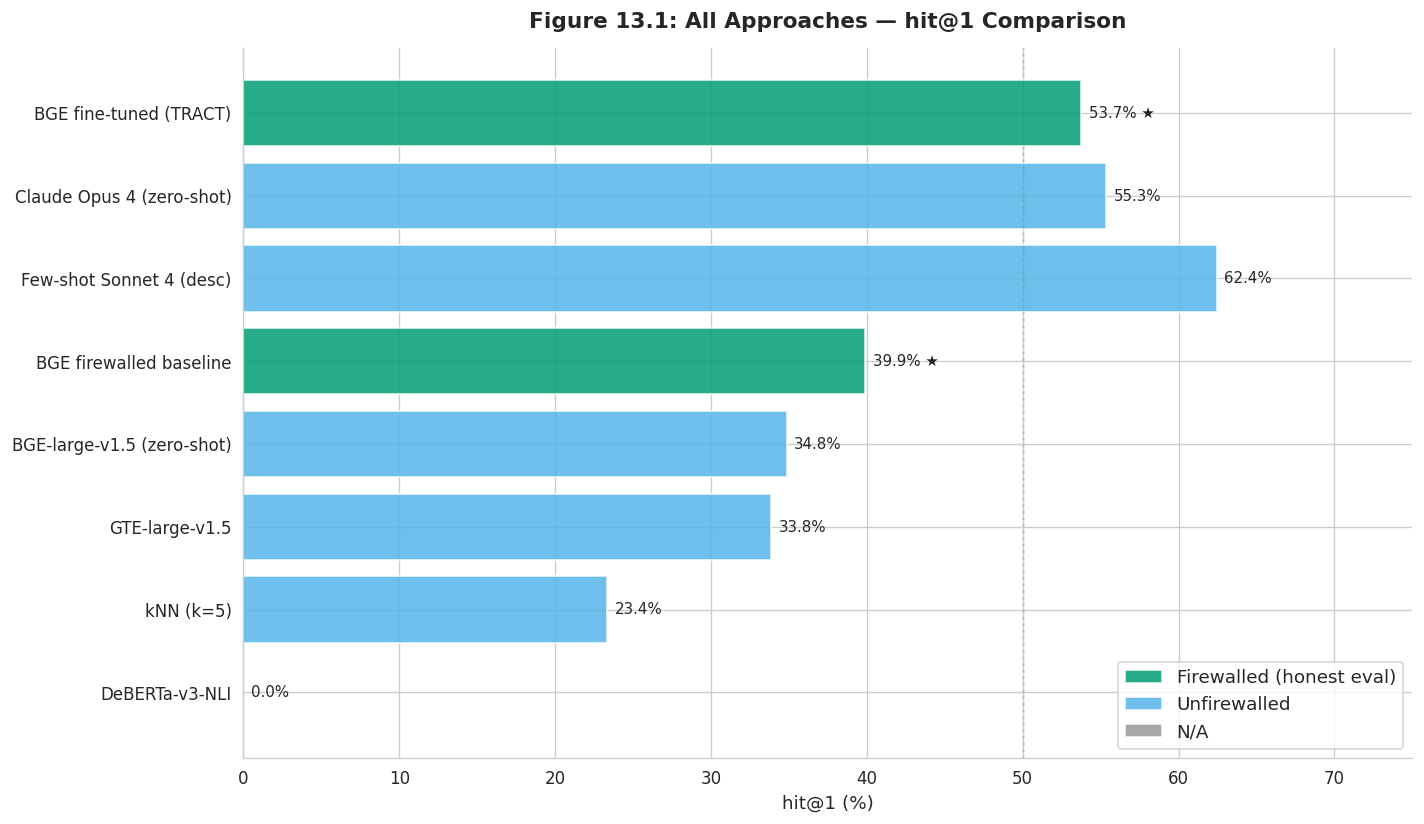

In [50]:
"""
Horizontal bar chart: all approaches ranked by hit@1 with protocol coloring.

Color coding by evaluation protocol:
- Green: Firewalled (LOFO) — honest evaluation, no information leakage
  (marked with ★ in the label)
- Sky Blue: Unfirewalled — may be inflated by information leakage
- Grey: N/A (DeBERTa — protocol doesn't apply when score = 0)

The ★ symbol marks firewalled results — these are the only ones that should
be compared directly. Comparing a firewalled 0.537 against an unfirewalled
0.553 is methodologically invalid (the Opus score benefits from leakage).
"""
approaches = [r["approach"] for r in master_table]
hit1_vals = [r["hit1"] for r in master_table]
fw_status = [r["firewalled"] for r in master_table]

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = range(len(approaches))

# Assign colors based on firewall status
colors_master = []
for fw in fw_status:
    if fw == "Yes":
        colors_master.append(OKABE_ITO[2])     # Green = firewalled
    elif fw == "No":
        colors_master.append(OKABE_ITO[1])     # Sky blue = unfirewalled
    else:
        colors_master.append(OKABE_ITO[7])     # Grey = N/A

bars = ax.barh(y_pos, [v * 100 for v in hit1_vals], color=colors_master, alpha=0.85)

# Label each bar; add ★ for firewalled results
for i, (v, fw) in enumerate(zip(hit1_vals, fw_status)):
    label = f"{v*100:.1f}%"
    if fw == "Yes":
        label += " ★"  # Star marks honest (firewalled) evaluation
    ax.text(v * 100 + 0.5, i, label, va="center", fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(approaches, fontsize=9)
ax.set_xlim(0, 75)
ax.axvline(50, color="gray", linestyle=":", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=OKABE_ITO[2], alpha=0.85, label="Firewalled (honest eval)"),
    Patch(facecolor=OKABE_ITO[1], alpha=0.85, label="Unfirewalled"),
    Patch(facecolor=OKABE_ITO[7], alpha=0.85, label="N/A"),
]
ax.legend(handles=legend_elements, loc="lower right")

fig_num = fig_counter.next(13)
style_axes(ax, "All Approaches — hit@1 Comparison", "hit@1 (%)", "", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Should I Trust This Crosswalk?

The honest answer: **it depends on the framework.** The crosswalk is not uniformly 
reliable — trust correlates with how well-represented a framework's concepts are in 
the OpenCRE training data.

- **High confidence:** Frameworks with strong OpenCRE coverage (e.g., NIST 800-53, 
  OWASP ASVS) — the model has seen many similar controls during training
- **Medium confidence:** Frameworks with partial overlap (e.g., CSA AICM, MITRE ATLAS) — 
  some concepts are well-matched, others are novel
- **Use with caution:** Frameworks with mostly novel concepts (e.g., AIUC-1, CoSAI) — 
  the model is extrapolating, and expert review found lower acceptance rates

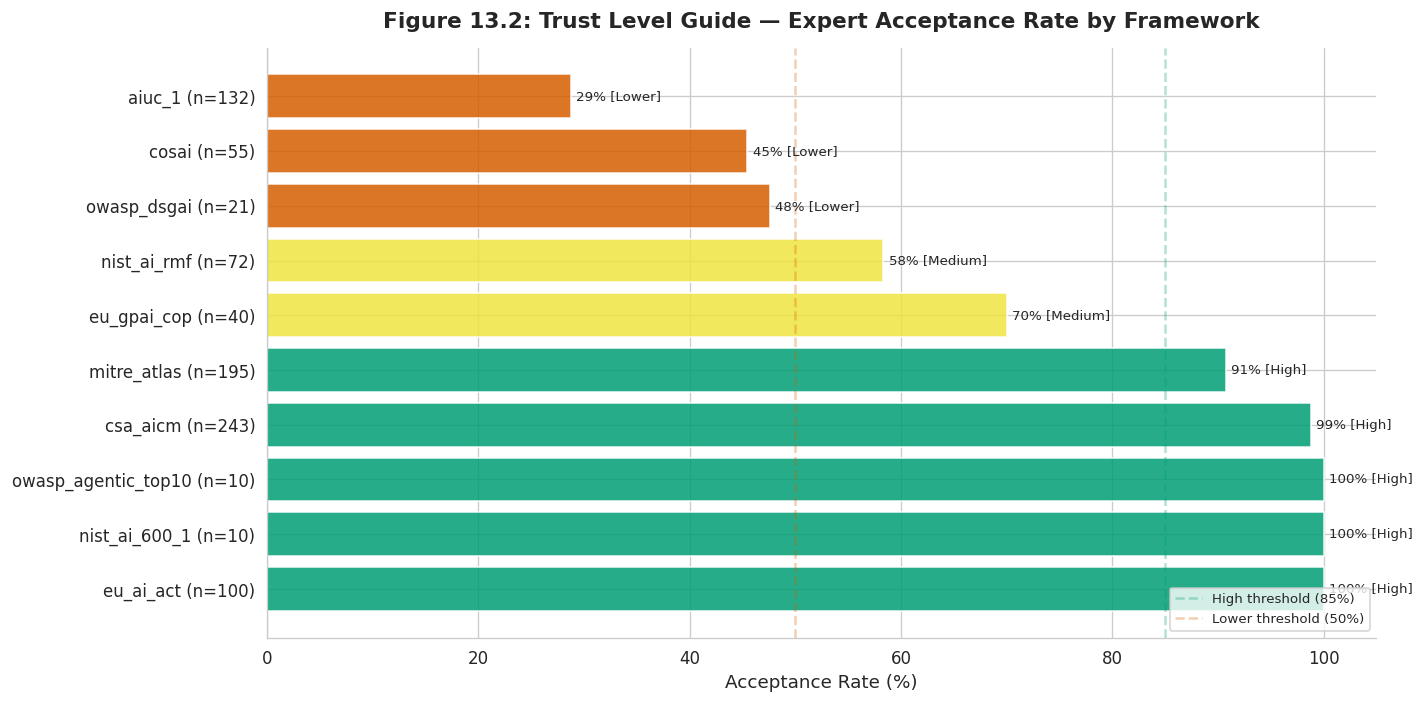

In [51]:
"""
Trust level guide: which frameworks have the most reliable TRACT assignments?

Based on expert acceptance rates, frameworks are tiered into trust levels:
- High (≥85% acceptance): Assignments can be used with minimal review
- Medium (50-84%): Assignments are useful but should be spot-checked
- Lower (<50%): Assignments need substantial manual review

This is the practitioner's guide — if you're using TRACT's crosswalk dataset,
this chart tells you which frameworks' assignments you can trust most.
"""
review_met = load_review_metrics()
per_fw = review_met.get("per_framework", {})

# Build trust tier data for each framework
fw_trust = []
for fw_name in sorted(per_fw.keys()):
    n = per_fw[fw_name].get("accepted", 0) + per_fw[fw_name].get("reassigned", 0) + per_fw[fw_name].get("rejected", 0)
    rate = (per_fw[fw_name].get("accepted", 0) / n * 100) if n > 0 else 0
    if rate >= 85:
        tier = "High"
    elif rate >= 50:
        tier = "Medium"
    else:
        tier = "Lower"
    fw_trust.append({"framework": fw_name, "acceptance": rate, "n": n, "tier": tier})

tier_colors = {"High": OKABE_ITO[2], "Medium": OKABE_ITO[3], "Lower": OKABE_ITO[5]}
fw_trust.sort(key=lambda x: x["acceptance"], reverse=True)

fig, ax = plt.subplots(figsize=(12, max(6, len(fw_trust) * 0.35)))
y_pos = range(len(fw_trust))
bar_colors = [tier_colors[t["tier"]] for t in fw_trust]
bars = ax.barh(y_pos, [t["acceptance"] for t in fw_trust], color=bar_colors, alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels([f'{t["framework"]} (n={t["n"]})' for t in fw_trust], fontsize=8)

# Label each bar with acceptance rate and trust tier
for i, t in enumerate(fw_trust):
    ax.text(t["acceptance"] + 0.5, i, f'{t["acceptance"]:.0f}% [{t["tier"]}]',
            va="center", fontsize=8)

ax.axvline(85, color=OKABE_ITO[2], linestyle="--", alpha=0.3, label="High threshold (85%)")
ax.axvline(50, color=OKABE_ITO[5], linestyle="--", alpha=0.3, label="Lower threshold (50%)")
ax.legend(loc="lower right", fontsize=8)

fig_num = fig_counter.next(13)
style_axes(ax, "Trust Level Guide — Expert Acceptance Rate by Framework",
           "Acceptance Rate (%)", "", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Known Limitations

1. **Single reviewer.** All expert review was done by one person. Inter-rater reliability 
   is unknown. Future work needs at least two independent reviewers.

2. **OpenCRE taxonomy is incomplete.** The OpenCRE has 522 hubs, but AI security concepts are 
   underrepresented. Controls about AI-specific risks (model poisoning, prompt injection) 
   may not have natural OpenCRE homes.

3. **English only.** The model was trained on English text. Controls in other languages 
   would need translation first, and cultural context may not transfer.

4. **Static embeddings.** The model doesn't update as OpenCRE evolves. New hubs added to OpenCRE 
   require re-training to include in the assignment space.

### What Would Make This Better

1. **Multi-reviewer validation.** At least two independent reviewers with Fleiss' κ or 
   Krippendorff's α agreement measurement.

2. **Active learning loop.** Use expert corrections to generate additional training pairs 
   and iteratively improve the model.

3. **Hierarchical prediction.** Instead of flat hub assignment, predict at multiple levels 
   of the OpenCRE tree (group → topic → hub) for better interpretability.

4. **Cross-lingual extension.** Multilingual sentence transformers could extend TRACT to 
   non-English frameworks without translation overhead.

In [52]:
"""
Define project timeline milestones for the journey visualization.

Each milestone records a key event with its date and outcome:
- "success" (green): Milestone achieved as expected
- "failure" (red): Approach didn't work — but the failure was informative
- "mixed" (yellow): Partial success with caveats

The timeline spans from April 27 to May 3, 2026 — 7 days of intensive work
from PRD to published dataset.
"""
milestones = [
    {"date": "2026-04-27", "event": "Project start — PRD written", "outcome": "success"},
    {"date": "2026-04-27", "event": "Data preparation — 9 parsers", "outcome": "success"},
    {"date": "2026-04-28", "event": "DeBERTa-v3-NLI: hit@1 = 0.000", "outcome": "failure"},
    {"date": "2026-04-28", "event": "BGE-large zero-shot: hit@1 = 0.348", "outcome": "success"},
    {"date": "2026-04-28", "event": "Opus ceiling: hit@1 = 0.553 (unfirewalled)", "outcome": "mixed"},
    {"date": "2026-04-28", "event": "Hierarchy paths: +7.6%", "outcome": "success"},
    {"date": "2026-04-29", "event": "Contrastive fine-tuning launched", "outcome": "success"},
    {"date": "2026-04-29", "event": "LOFO evaluation: hit@1 = 0.537 (firewalled)", "outcome": "success"},
    {"date": "2026-04-30", "event": "Calibration: T = 0.074, ECE = 0.079", "outcome": "success"},
    {"date": "2026-04-30", "event": "OOD detection: 96.7% separation", "outcome": "success"},
    {"date": "2026-05-01", "event": "Framework prep pipeline", "outcome": "success"},
    {"date": "2026-05-02", "event": "HuggingFace model published", "outcome": "success"},
    {"date": "2026-05-02", "event": "Bridge analysis: 46/63 accepted", "outcome": "mixed"},
    {"date": "2026-05-03", "event": "Expert review: 77.4% accepted", "outcome": "success"},
    {"date": "2026-05-03", "event": "Dataset published to HuggingFace", "outcome": "success"},
]

outcome_colors = {"success": OKABE_ITO[2], "failure": OKABE_ITO[5], "mixed": OKABE_ITO[3]}
print(f"Timeline: {len(milestones)} milestones over {milestones[0]['date']} to {milestones[-1]['date']}")

Timeline: 15 milestones over 2026-04-27 to 2026-05-03


In [53]:
"""
Interactive Plotly timeline of the project journey.

Each point is a milestone, colored by outcome (success/failure/mixed).
Hover for details. This visualization tells the story of the project:
failures (DeBERTa) led to pivots (BGE), which led to the final model.
"""
fig_timeline = go.Figure()

for outcome in ["success", "mixed", "failure"]:
    items = [m for m in milestones if m["outcome"] == outcome]
    if not items:
        continue
    fig_timeline.add_trace(go.Scatter(
        x=[m["date"] for m in items],
        y=[i for i, m in enumerate(milestones) if m["outcome"] == outcome],
        mode="markers+text",
        marker=dict(size=12, color=outcome_colors[outcome]),
        text=[m["event"] for m in items],
        textposition="middle right",
        textfont=dict(size=9),
        name=outcome.capitalize(),
        hovertemplate="%{text}<br>%{x}<extra></extra>",
    ))

fig_num = fig_counter.next(13)
fig_timeline.update_layout(
    xaxis_title="Date",
    yaxis=dict(visible=False),
    height=500,
    width=900,
    showlegend=True,
    margin=dict(l=50, r=300, t=50, b=50),
)

plotly_with_fallback(fig_timeline, fig_num, "Project Journey Timeline", width=900, height=500)

### The Real Lesson

The most important finding isn't a number — it's a methodology. The combination of:

- **Assignment paradigm** (`control → hub`, not `control ↔ control`)
- **Hub firewall** (honest evaluation without information leakage)
- **LOFO cross-validation** (leave out entire frameworks, not random samples)
- **Calibrated confidence** (know when to trust the model)
- **Expert review** (validate with human judgment)

...produces a crosswalk you can actually reason about. You know what the model is good at 
(well-represented frameworks), what it struggles with (novel concepts), and when to be 
skeptical (low confidence, OOD flags).

### For Practitioners

If you're a compliance team or security architect:

1. **Start with high-trust frameworks.** Use the crosswalk directly for well-represented 
   frameworks (acceptance rate >85%). These assignments are expert-validated.
2. **Spot-check medium-trust frameworks.** For frameworks in the 50-85% range, review 
   assignments flagged with low confidence or OOD status.
3. **Use with care for new frameworks.** For frameworks not in the training data, use 
   `tract ingest` as a starting point but expect to correct 20-50% of assignments.
4. **Leverage the hierarchy.** When a model assignment seems wrong, check its siblings — 
   the correct hub is often nearby in the OpenCRE tree.

### For Researchers

If you're working on taxonomy mapping or semantic similarity:

1. **The hub firewall matters.** Without it, evaluation metrics are inflated by up to 
   12 percentage points. Any crosswalk paper that doesn't firewall during evaluation 
   should be read skeptically.
2. **NLI doesn't transfer to this task.** DeBERTa-v3-NLI scored exactly 0.0% — entailment 
   is not the same as semantic similarity for taxonomy assignment.
3. **LLMs set a ceiling, not a floor.** Claude Opus 4 reached 55.3% unfirewalled, which 
   becomes the benchmark — but at $0.60/control and without honest evaluation.
4. **Multi-hub controls are the hard problem.** Controls that legitimately map to multiple 
   hubs break kappa-style agreement metrics. Future work needs hierarchy-aware evaluation.

### Acknowledgments

- **[OWASP OpenCRE](https://opencre.org)** — for building and maintaining the Common Requirements Enumeration
- **Framework publishers** — CSA, MITRE, NIST, OWASP, ISO, EU, and others for making 
  their frameworks accessible
- **BGE team (BAAI)** — for the excellent base embedding model
- **HuggingFace** — for model and dataset hosting infrastructure

### Citation

If you use TRACT or the crosswalk dataset in your work:

```bibtex
@software{tract2026,
  title = {TRACT: Translating Requirements Across CRE Trees},
  author = {Rock},
  year = {2026},
  url = {https://huggingface.co/rockCO78/tract-cre-assignment},
  note = {Model and crosswalk dataset for mapping security framework controls to OpenCRE hubs}
}
```

### License

- **This notebook:** CC-BY-SA-4.0
- **TRACT model:** Apache-2.0
- **Crosswalk dataset:** CC-BY-SA-4.0
- **[OpenCRE](https://opencre.org) data:** Subject to OWASP's terms of use

> **Plain English:** We built a tool that maps security controls to a shared taxonomy. It 
> works well for frameworks the model has seen before (77% expert-accepted), less well for 
> novel concepts. The honest evaluation approach (hub firewall + LOFO) means our numbers are 
> trustworthy even if they're not as high as inflated alternatives. The crosswalk, model, and 
> code are all openly available for anyone to use, validate, or extend.

## 14. Canonical Export for OpenCRE RFC

TRACT produces a canonical JSON format designed to align with OpenCRE's
[easier-importing RFC](https://github.com/OWASP/OpenCRE/blob/main/docs/designs/easier-importing.md).
Each framework gets a `StandardSnapshot` (all controls + mappings + filter policy)
and a `Changeset` (diff against the prior export). This enables incremental,
reviewable imports rather than full-graph replacement.

### 14.1 StandardSnapshot Schema

The `StandardSnapshot` is the root export model — a self-contained, integrity-verified
representation of one framework's crosswalk state. It contains:

| Field | Type | Description |
|-------|------|-------------|
| `schema_version` | `str` | Schema version, always `"1.0"` for this release |
| `framework_id` | `str` | Framework identifier (e.g., `csa_aicm`) |
| `framework_name` | `str` | Human-readable framework name |
| `export_date` | `str` | ISO 8601 UTC timestamp of export |
| `content_hash` | `str` | SHA-256 of all non-volatile fields (see §14.3) |
| `tract_version` | `str` | Git SHA of TRACT at export time |
| `model_adapter_hash` | `str` | SHA-256 of the LoRA adapter weights |
| `filter_policy` | `FilterPolicy` | Exclusion rules applied during export |
| `controls` | `list[CanonicalControl]` | Controls passing all filters |
| `mappings` | `list[CREMapping]` | Control→hub assignments with confidence scores |

Each `CanonicalControl` has: `control_id`, `framework_id`, `section_id`, `title`,
`description`, and a `hyperlink` computed at export time from per-framework URL templates.

Each `CREMapping` has: `control_id`, `hub_id`, `hub_name`, `confidence` (calibrated),
`rank` (1-indexed, forward-compatible for top-k>1), `link_type` (default `TRACT_ML_PREDICTED`),
`provenance`, and `model_version` (derived from snapshot-level `model_adapter_hash`).

### 14.2 Filter Pipeline

Before building a snapshot, assignments pass through a multi-gate filter:

| Filter | Rule | Purpose |
|--------|------|--------|
| Review status | `review_status = 'accepted'` | Only expert-reviewed assignments |
| Ground truth | `provenance != ground_truth_T1-AI` | Already in OpenCRE — don't re-import |
| Calibration | `confidence IS NOT NULL` | Exclude uncalibrated predictions |
| OOD | `is_ood != 1` | Exclude out-of-distribution controls |
| Confidence floor | `confidence >= floor` | Framework-specific threshold |

The `FilterPolicy` object in each snapshot documents exactly which filters were applied,
ensuring reproducibility.

### 14.3 Content Hashing

Each snapshot includes a SHA-256 `content_hash` computed over all fields *except*
`content_hash` itself and `export_date` (which are volatile). The hash uses
deterministic JSON serialization (`sort_keys=True`, compact separators, ASCII-only)
so the same logical snapshot always produces the same hash regardless of platform.

When loading a prior snapshot from `export_history`, the hash is recomputed and
verified — any mismatch raises an integrity error, preventing silent data corruption.

### 14.4 Changeset Format

Changesets track changes between consecutive exports of the same framework using
6 operation types:

| Operation | Identity Key | Mutable Fields Tracked |
|-----------|-------------|------------------------|
| `ADD_CONTROL` | `control_id` | — (new entity) |
| `UPDATE_CONTROL` | `control_id` | title, description, hyperlink |
| `DELETE_CONTROL` | `control_id` | — (entity removed) |
| `ADD_MAPPING` | `(control_id, hub_id)` | — (new entity) |
| `UPDATE_MAPPING` | `(control_id, hub_id)` | confidence, rank, provenance, model_version |
| `DELETE_MAPPING` | `(control_id, hub_id)` | — (entity removed) |

Each changeset includes:
- A `ChangesetSummary` with counts per operation type
- An `ImpactAnalysis` identifying affected CRE hubs, co-mapped frameworks, and
  scope classification (minor: <10 ops, moderate: 10–50 or delete_mapping,
  major: >50 or delete_control)

### 14.5 Design Decisions

Key choices from the 4-round adversarial review:
- **Control IDs** use single-colon format (`framework_id:section_id`), matching crosswalk.db
  and normalizing the `::` format found in deployment artifacts
- **model_version** on each mapping is derived from the snapshot-level `model_adapter_hash`,
  not stored per-assignment in the DB (where it is NULL for all 558 non-ground-truth rows)
- **rank** field is forward-compatible for top-k>1 (v1 data is all rank=1)
- **Hyperlinks** are computed at export time from per-framework URL templates, not stored in DB
- **Export history** lives in crosswalk.db (not filesystem) to keep changeset generation
  self-contained and atomic

In [54]:
"""
Section 14: Canonical export schema introspection.

Display the full StandardSnapshot schema with field types and defaults,
then show the 6 changeset operation types and an example snapshot structure.
"""
from tract.export.canonical_schema import (
    StandardSnapshot, CanonicalControl, CREMapping, FilterPolicy,
    ChangesetEntry, ChangesetSummary, ImpactAnalysis, Changeset,
)

# --- StandardSnapshot fields ---
print("StandardSnapshot schema:")
print("=" * 60)
for field_name, field_info in StandardSnapshot.model_fields.items():
    default = field_info.default
    annotation = field_info.annotation
    default_str = f" = {default!r}" if default is not None else ""
    print(f"  {field_name}: {annotation}{default_str}")

print()

# --- Nested model fields ---
for model, label in [
    (CanonicalControl, "CanonicalControl"),
    (CREMapping, "CREMapping"),
    (FilterPolicy, "FilterPolicy"),
]:
    print(f"\n{label} fields:")
    print("-" * 40)
    for name, info in model.model_fields.items():
        default = info.default
        default_str = f" = {default!r}" if default is not None else ""
        print(f"  {name}: {info.annotation}{default_str}")

# --- Changeset operations ---
print("\n\nChangeset operation types:")
print("=" * 60)
import typing
hints = typing.get_args(ChangesetEntry.model_fields["operation"].annotation)
for op in hints:
    print(f"  {op}")

StandardSnapshot schema:
  schema_version: <class 'str'> = '1.0'
  framework_id: <class 'str'> = PydanticUndefined
  framework_name: <class 'str'> = PydanticUndefined
  export_date: <class 'str'> = PydanticUndefined
  content_hash: <class 'str'> = PydanticUndefined
  tract_version: <class 'str'> = PydanticUndefined
  model_adapter_hash: <class 'str'> = PydanticUndefined
  filter_policy: <class 'tract.export.canonical_schema.FilterPolicy'> = PydanticUndefined
  controls: list[tract.export.canonical_schema.CanonicalControl] = PydanticUndefined
  mappings: list[tract.export.canonical_schema.CREMapping] = PydanticUndefined


CanonicalControl fields:
----------------------------------------
  control_id: <class 'str'> = PydanticUndefined
  framework_id: <class 'str'> = PydanticUndefined
  section_id: <class 'str'> = PydanticUndefined
  title: <class 'str'> = PydanticUndefined
  description: <class 'str'> = PydanticUndefined
  hyperlink: <class 'str'> = PydanticUndefined

CREMapping fields:


### 14.6 Usage

```bash
# Preview without writing (shows counts + changeset summary)
tract export-canonical --dry-run

# Export a single framework
tract export-canonical --framework csa_aicm

# Export all eligible frameworks with embeddings
tract export-canonical --with-embeddings
```

The canonical export pipeline is implemented in `tract/export/canonical.py` with
Pydantic v2 models in `tract/export/canonical_schema.py`. The notebook helpers
`load_canonical_snapshot()` and `load_canonical_changeset()` in `notebooks/nb_helpers.py`
provide convenient access to exported data.

---

## Appendix A: Experiment Log

Complete list of experiments run during this project, with key metrics loaded 
programmatically from the result files.

In [55]:
"""
Appendix A: Complete experiment log with all runs, models, and results.

This table documents every experiment run during the project, including:
- The model used and its parameter count
- The hit@1 score achieved
- Key observations or lessons from each run

This serves as the reproducibility reference — anyone reviewing this work
can trace every reported number back to a specific experiment run.
"""
# Load all experiment results for the comprehensive log
bge_a = load_phase0_experiment("exp1_embedding_baseline_bge")
gte_a = load_phase0_experiment("exp1_embedding_baseline_gte")
deberta_a = load_phase0_experiment("exp1_embedding_baseline_deberta")
opus_a = load_phase0_experiment("exp2_llm_probe")
knn_a = load_phase0_experiment("exp5_knn_baseline")
fewshot_a = load_phase0_experiment("exp6_fewshot_sonnet")
firewalled_a = load_firewalled_baseline()
corrected_a = json.loads((PHASE1B_DIR / "phase1b_textaware" / "corrected_metrics.json").read_text(encoding="utf-8"))

experiments = [
    {"run": "exp1_bge", "model": "BGE-large-v1.5", "params": "335M",
     "hit1": bge_a["models"]["bge-large-v1.5"]["all_198"]["hit_at_1"]["mean"],
     "notes": "Zero-shot embedding baseline"},
    {"run": "exp1_gte", "model": "GTE-large-v1.5", "params": "335M",
     "hit1": gte_a["models"]["gte-large-v1.5"]["all_198"]["hit_at_1"]["mean"],
     "notes": "Zero-shot embedding baseline"},
    {"run": "exp1_deberta", "model": "DeBERTa-v3-NLI", "params": "304M",
     "hit1": deberta_a["models"]["deberta-v3-nli"]["all_198"]["hit_at_1"]["mean"],
     "notes": "NLI cross-encoder — total failure (0.0%)"},
    {"run": "exp2_opus", "model": "Claude Opus 4", "params": "N/A",
     "hit1": opus_a["all_198"]["hit_at_1"]["mean"],
     "notes": "Zero-shot LLM probe (unfirewalled)"},
    {"run": "exp5_knn", "model": "kNN (k=5) on BGE", "params": "N/A",
     "hit1": knn_a["k_values"]["k5"]["all"]["hit_at_1"]["mean"],
     "notes": "Neighborhood-based retrieval"},
    {"run": "exp6_sonnet_desc", "model": "Sonnet 4 (3-shot, desc)", "params": "N/A",
     "hit1": fewshot_a["variants"]["sonnet-desc"]["all"]["hit_at_1"]["mean"],
     "notes": "Few-shot with descriptions"},
    {"run": "exp6_sonnet_nodesc", "model": "Sonnet 4 (3-shot, no desc)", "params": "N/A",
     "hit1": fewshot_a["variants"]["sonnet-nodesc"]["all"]["hit_at_1"]["mean"],
     "notes": "Few-shot without descriptions"},
    {"run": "phase1b_fw_baseline", "model": "BGE-large (firewalled)", "params": "335M",
     "hit1": firewalled_a["aggregate_hit1"]["mean"],
     "notes": "Zero-shot with hub firewall"},
    {"run": "phase1b_textaware", "model": "BGE-large + LoRA", "params": "+4.2M",
     "hit1": corrected_a["aggregate_hit1"]["mean"],
     "notes": "Final deployment model (firewalled LOFO)"},
]

print(f"{'Run':<25s} {'Model':<30s} {'Params':<8s} {'hit@1':>8s}  Notes")
print("-" * 110)
for e in experiments:
    print(f"{e['run']:<25s} {e['model']:<30s} {e['params']:<8s} {e['hit1']:8.3f}  {e['notes']}")

Run                       Model                          Params      hit@1  Notes
--------------------------------------------------------------------------------------------------------------
exp1_bge                  BGE-large-v1.5                 335M        0.348  Zero-shot embedding baseline
exp1_gte                  GTE-large-v1.5                 335M        0.338  Zero-shot embedding baseline
exp1_deberta              DeBERTa-v3-NLI                 304M        0.000  NLI cross-encoder — total failure (0.0%)
exp2_opus                 Claude Opus 4                  N/A         0.553  Zero-shot LLM probe (unfirewalled)
exp5_knn                  kNN (k=5) on BGE               N/A         0.234  Neighborhood-based retrieval
exp6_sonnet_desc          Sonnet 4 (3-shot, desc)        N/A         0.624  Few-shot with descriptions
exp6_sonnet_nodesc        Sonnet 4 (3-shot, no desc)     N/A         0.614  Few-shot without descriptions
phase1b_fw_baseline       BGE-large (firewalled)       

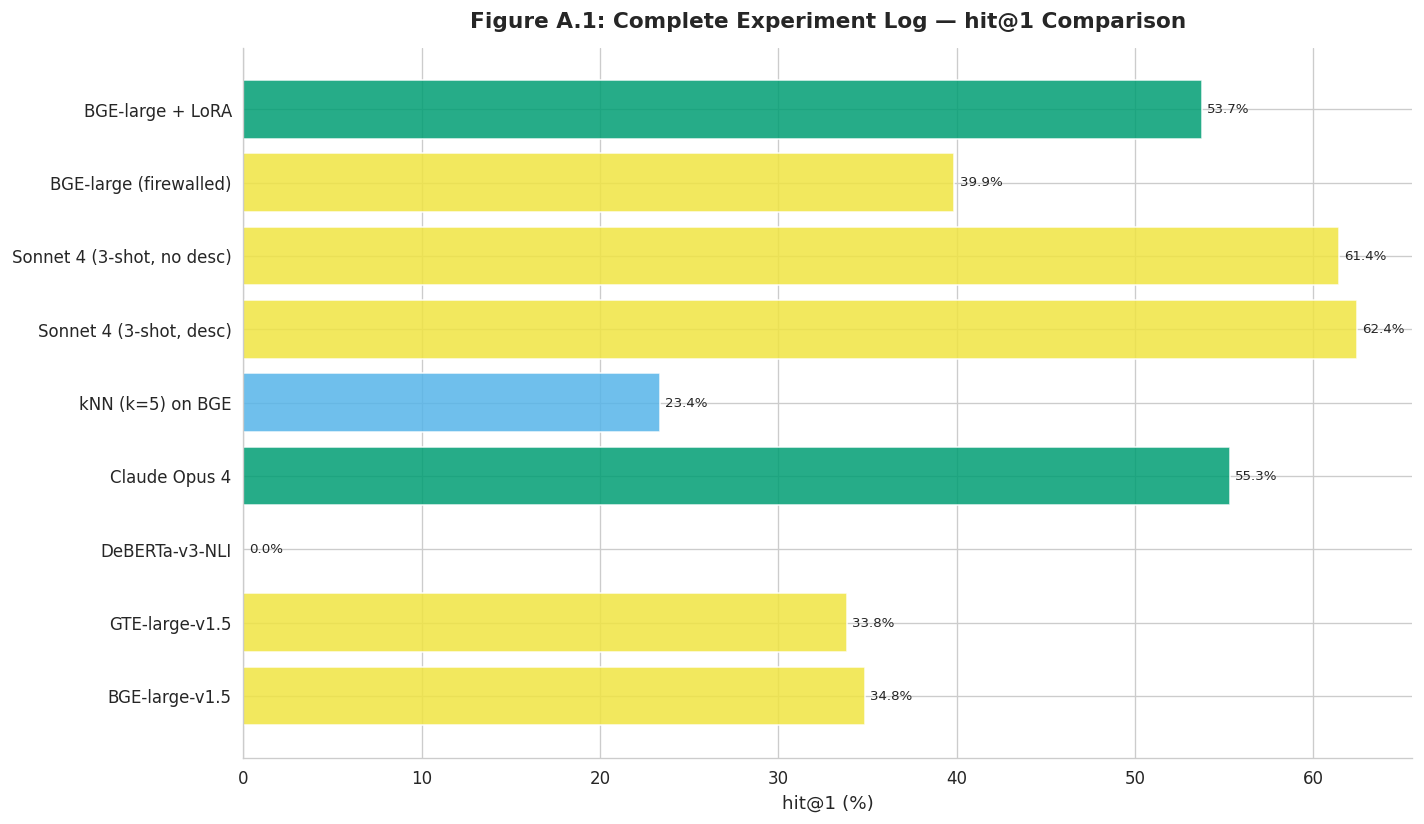

In [56]:
"""
Appendix A: Horizontal bar chart of all experiments sorted by model.

Color coding by experiment type:
- Red: Total failure (hit@1 = 0)
- Green: Firewalled evaluation (honest)
- Yellow: LLM-based approaches (expensive)
- Sky blue: Unfirewalled embedding baselines

This provides a visual companion to the experiment log table above.
"""
fig, ax = plt.subplots(figsize=(12, 7))
exp_names = [e["model"] for e in experiments]
exp_hit1 = [e["hit1"] * 100 for e in experiments]

# Color by experiment category
bar_colors_exp = []
for e in experiments:
    if e["hit1"] == 0:
        bar_colors_exp.append(OKABE_ITO[5])       # Red = failure
    elif "firewalled" in e["notes"].lower() or "LOFO" in e["notes"]:
        bar_colors_exp.append(OKABE_ITO[2])       # Green = firewalled
    elif "LLM" in e["notes"] or "Few-shot" in e["notes"] or "shot" in e["notes"].lower():
        bar_colors_exp.append(OKABE_ITO[3])       # Yellow = LLM-based
    else:
        bar_colors_exp.append(OKABE_ITO[1])       # Sky blue = unfirewalled embedding

y_pos = range(len(exp_names))
bars = ax.barh(y_pos, exp_hit1, color=bar_colors_exp, alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(exp_names, fontsize=9)

for i, v in enumerate(exp_hit1):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)

fig_num = "Figure A.1"
style_axes(ax, "Complete Experiment Log — hit@1 Comparison", "hit@1 (%)", "", fig_num)
plt.tight_layout()
plt.show()
plt.close(fig)

### Reproducibility Notes

- **Random seeds:** All experiments use `seed=42` for NumPy, Python random, and PyTorch
- **Model versions:** BGE-large-v1.5 (`BAAI/bge-large-en-v1.5`), Claude Opus 4 
  (`claude-opus-4-20250514`), Claude Sonnet 4 (`claude-sonnet-4-20250514`)
- **Hardware:** Training on NVIDIA GPU via RunPod; evaluation on NVIDIA Tegra (ARM64)
- **Data hash:** Computed at fetch time and stored in processed output metadata
- **LOFO folds:** Deterministic — each fold holds out exactly one framework
- **Full source code:** Available in the TRACT repository alongside this notebook

---

## Appendix B: Visual Style Guide

Every figure in this notebook uses the Okabe-Ito colorblind-safe palette. This appendix 
documents the palette and our visual conventions for reproducibility.

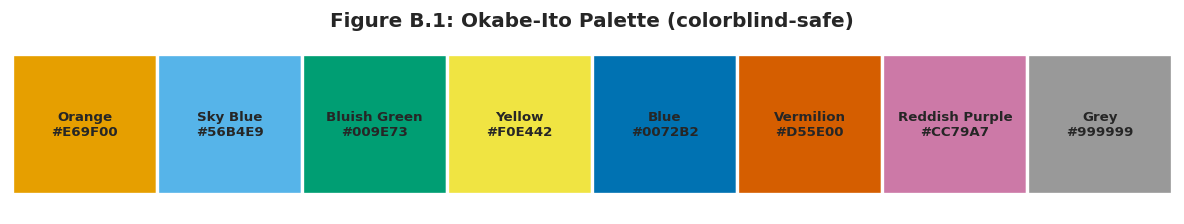

In [57]:
"""
Appendix B: Visual reference for the Okabe-Ito colorblind-safe palette.

All figures in this notebook use the Okabe-Ito palette — an 8-color scheme
designed by Masataka Okabe and Kei Ito to be distinguishable by people with
all forms of color vision deficiency (protanopia, deuteranopia, tritanopia).

Each swatch shows the color name and hex code for reference.
This appendix ensures the palette choice is documented and reproducible.
"""
color_names = [
    "Orange", "Sky Blue", "Bluish Green", "Yellow",
    "Blue", "Vermilion", "Reddish Purple", "Grey",
]

fig, ax = plt.subplots(figsize=(10, 2))
for i, (color, name) in enumerate(zip(OKABE_ITO, color_names)):
    ax.barh(0, 1, left=i, color=color, edgecolor="white", linewidth=2)
    ax.text(i + 0.5, 0, f"{name}\n{color}", ha="center", va="center", fontsize=8,
            fontweight="bold")
ax.set_xlim(0, 8)
ax.set_ylim(-0.5, 0.5)
ax.axis("off")
fig_num = "Figure B.1"
ax.set_title(f"{fig_num}: Okabe-Ito Palette (colorblind-safe)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close(fig)

### Styling Conventions

- **Font:** System default (DejaVu Sans on Linux)
- **Figure DPI:** 120 for display, vector for export
- **Axis styling:** Top and right spines removed via `style_axes()`, 
  consistent figure numbering via `FigureCounter`
- **Color assignments:**
  - Orange (index 0): Primary category, default bars
  - Sky Blue (index 1): Secondary/unfirewalled results
  - Bluish Green (index 2): Positive/high-trust/firewalled results
  - Yellow (index 3): Warning/medium trust
  - Blue (index 4): Tertiary
  - Vermilion (index 5): Negative/low trust/failures
  - Reddish Purple (index 6): Accents
  - Grey (index 7): N/A, baselines, reference lines
- **Plotly figures:** Include PNG fallback via `plotly_with_fallback()` for static rendering

### Palette Reference

Okabe, M. and Ito, K. (2008). *Color Universal Design (CUD) — How to make figures and 
presentations that are friendly to Colorblind people.* University of Tokyo.

The Okabe-Ito palette is designed to be distinguishable by people with all common forms 
of color vision deficiency (protanopia, deuteranopia, tritanopia). It is recommended by 
Nature, Science, and most accessibility guidelines for scientific visualization.